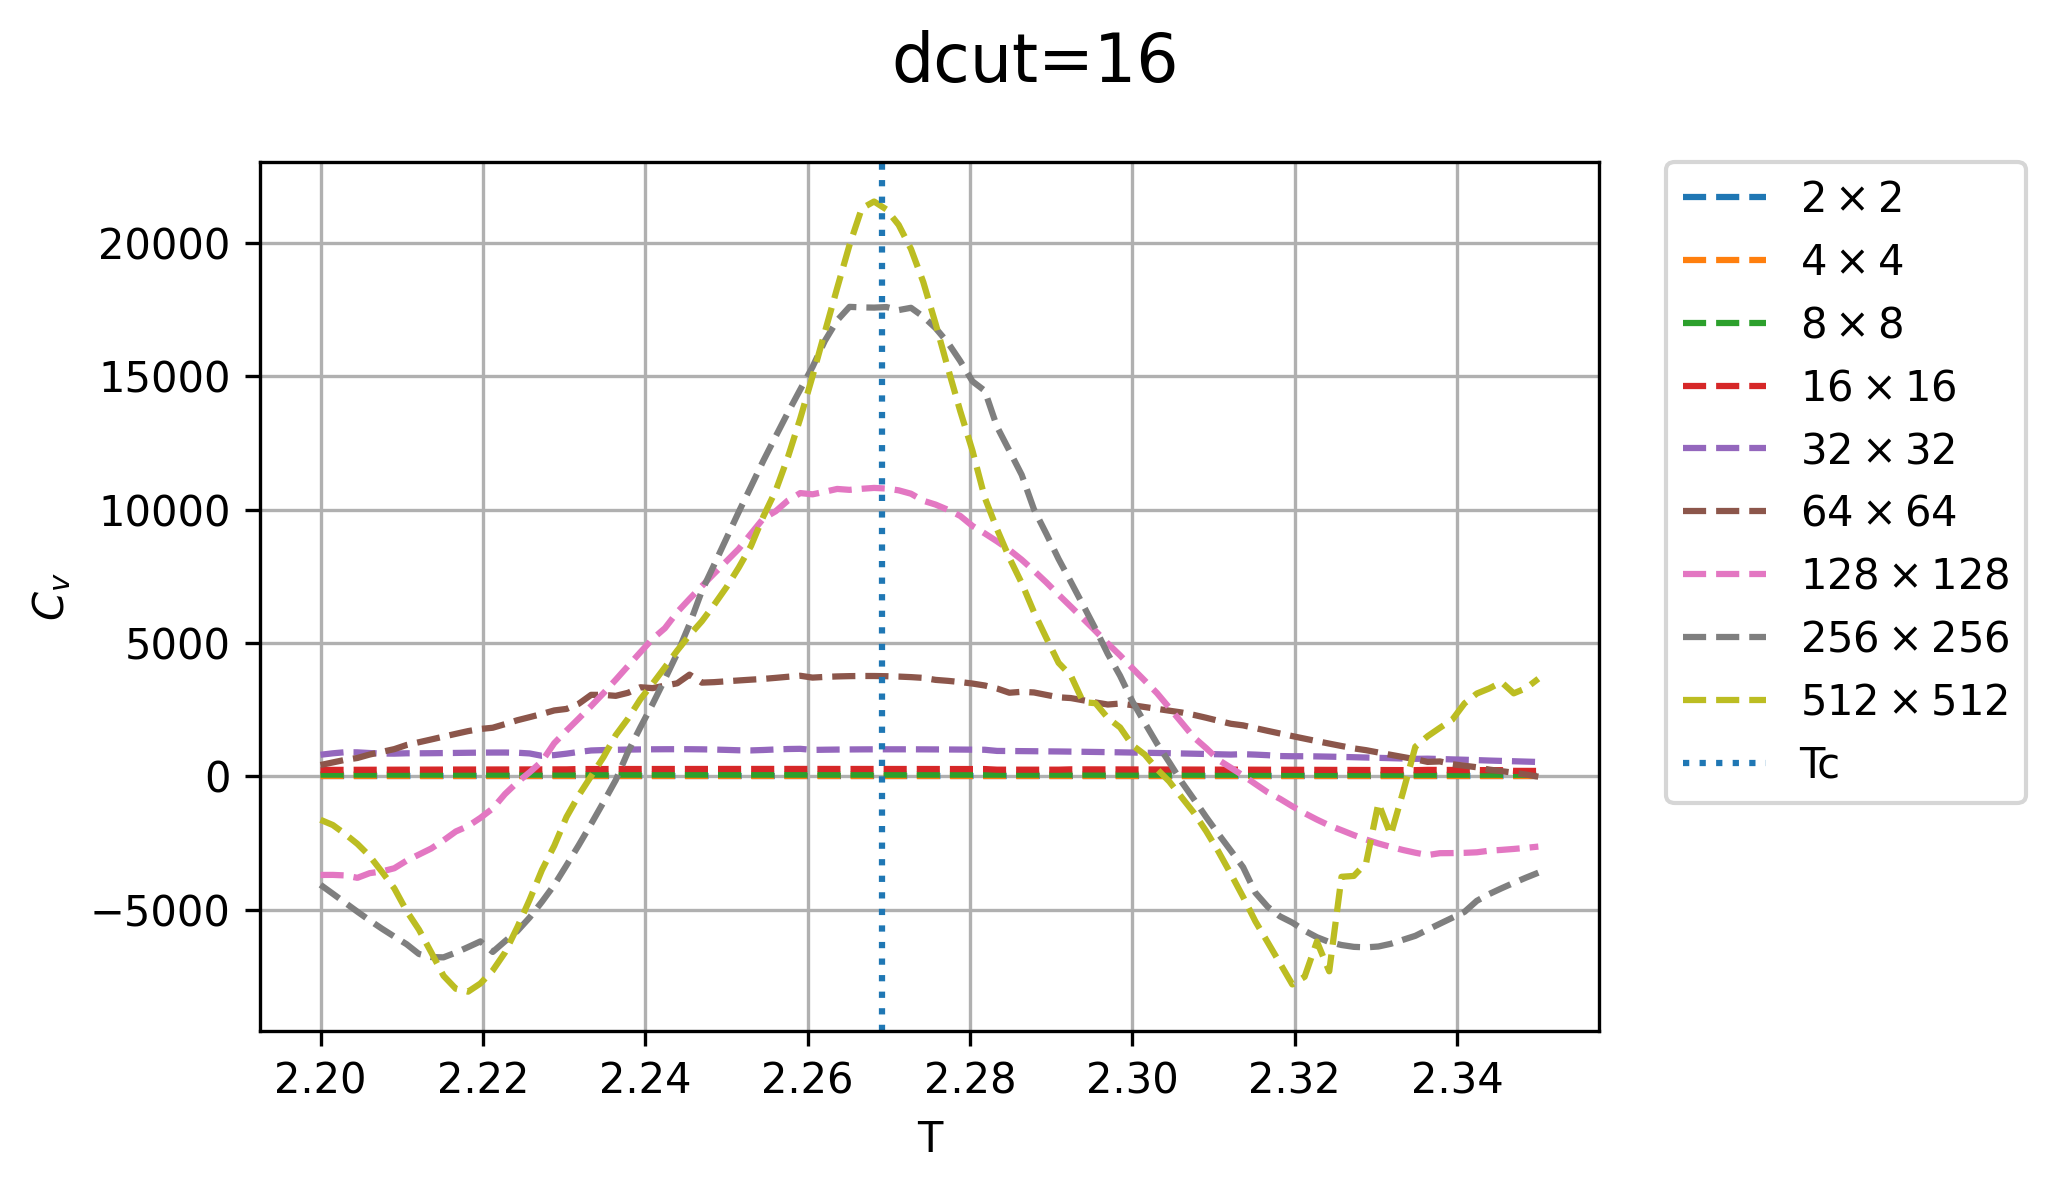

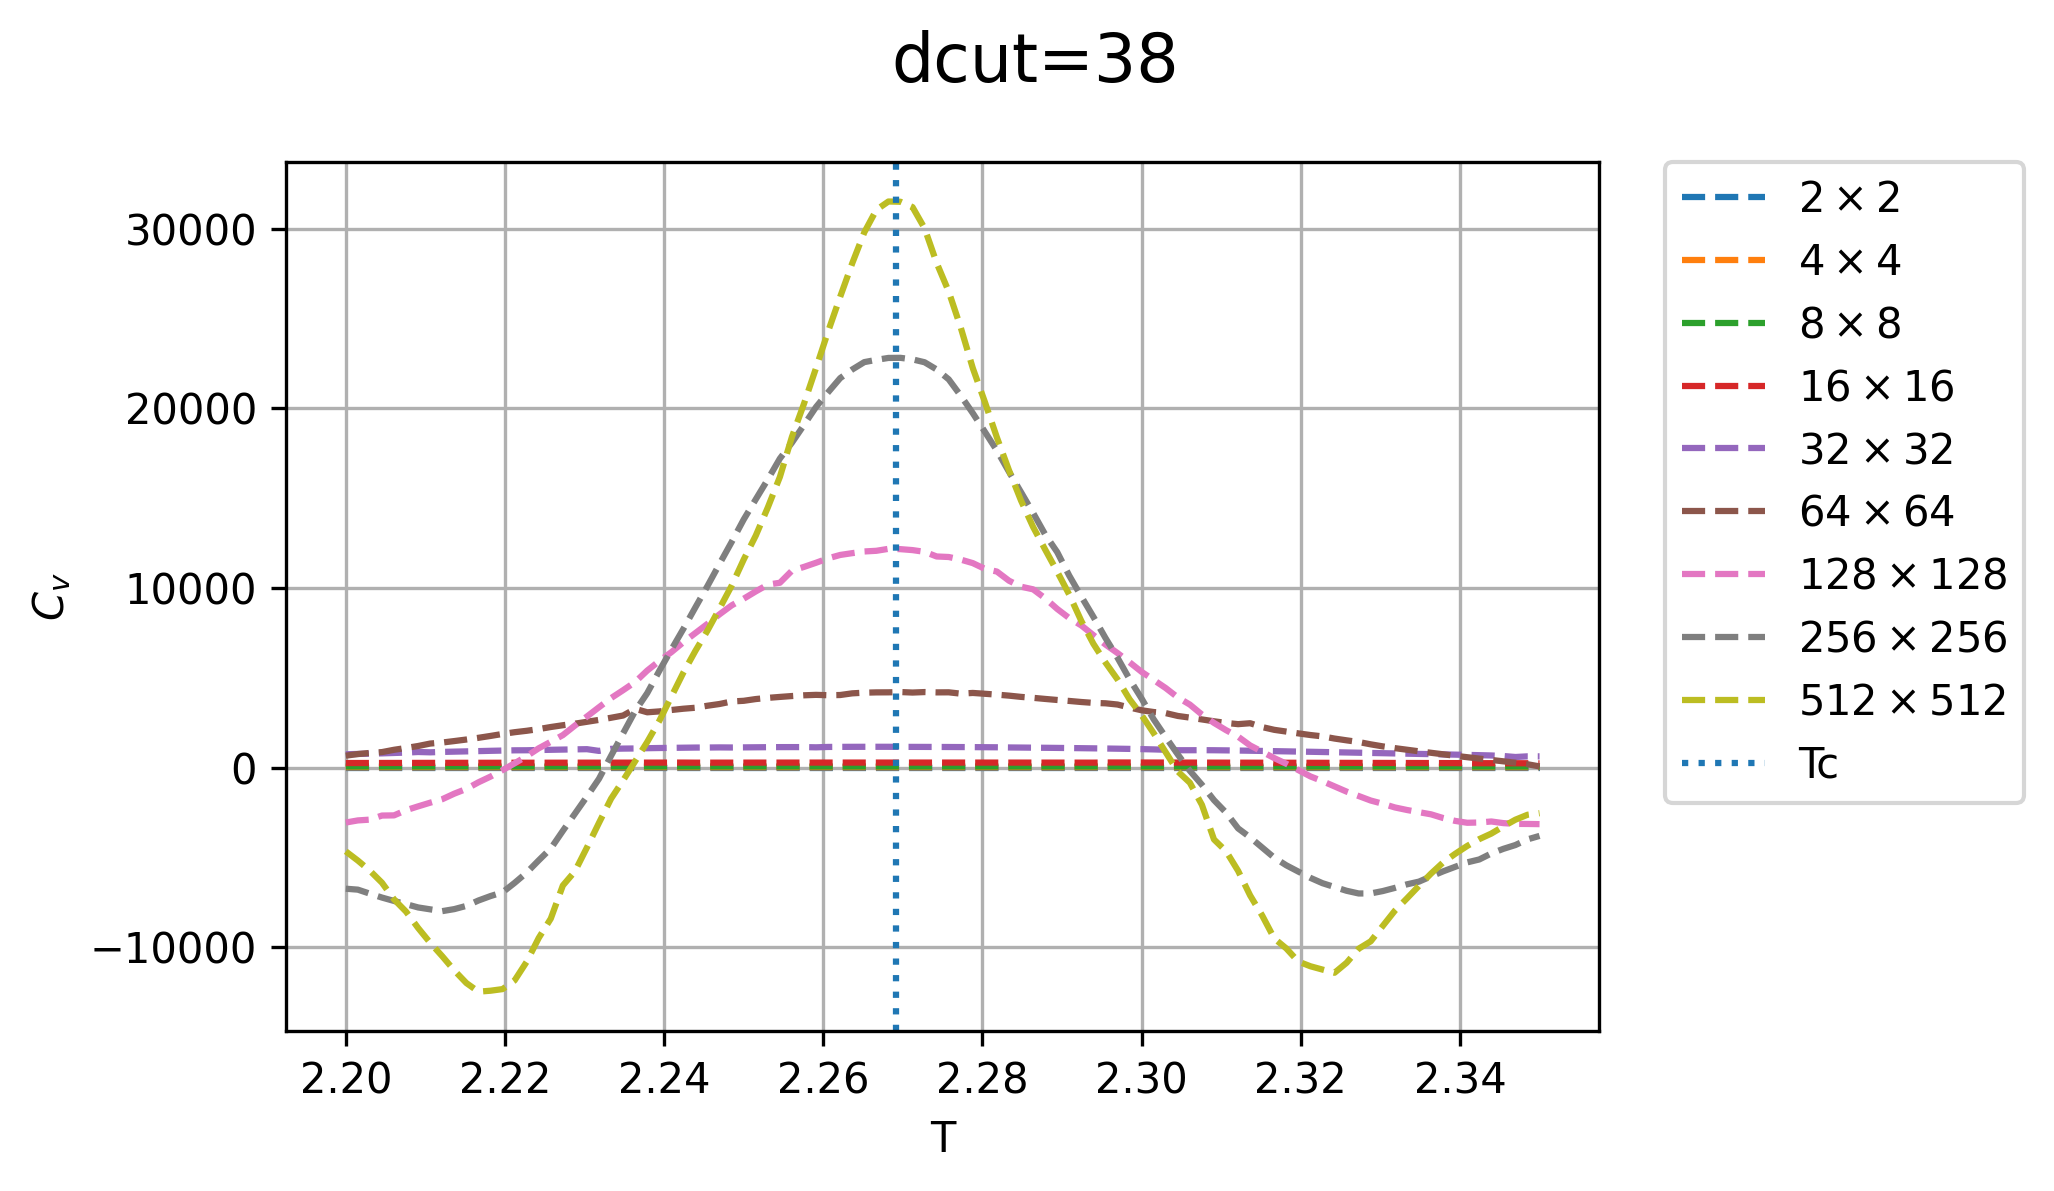

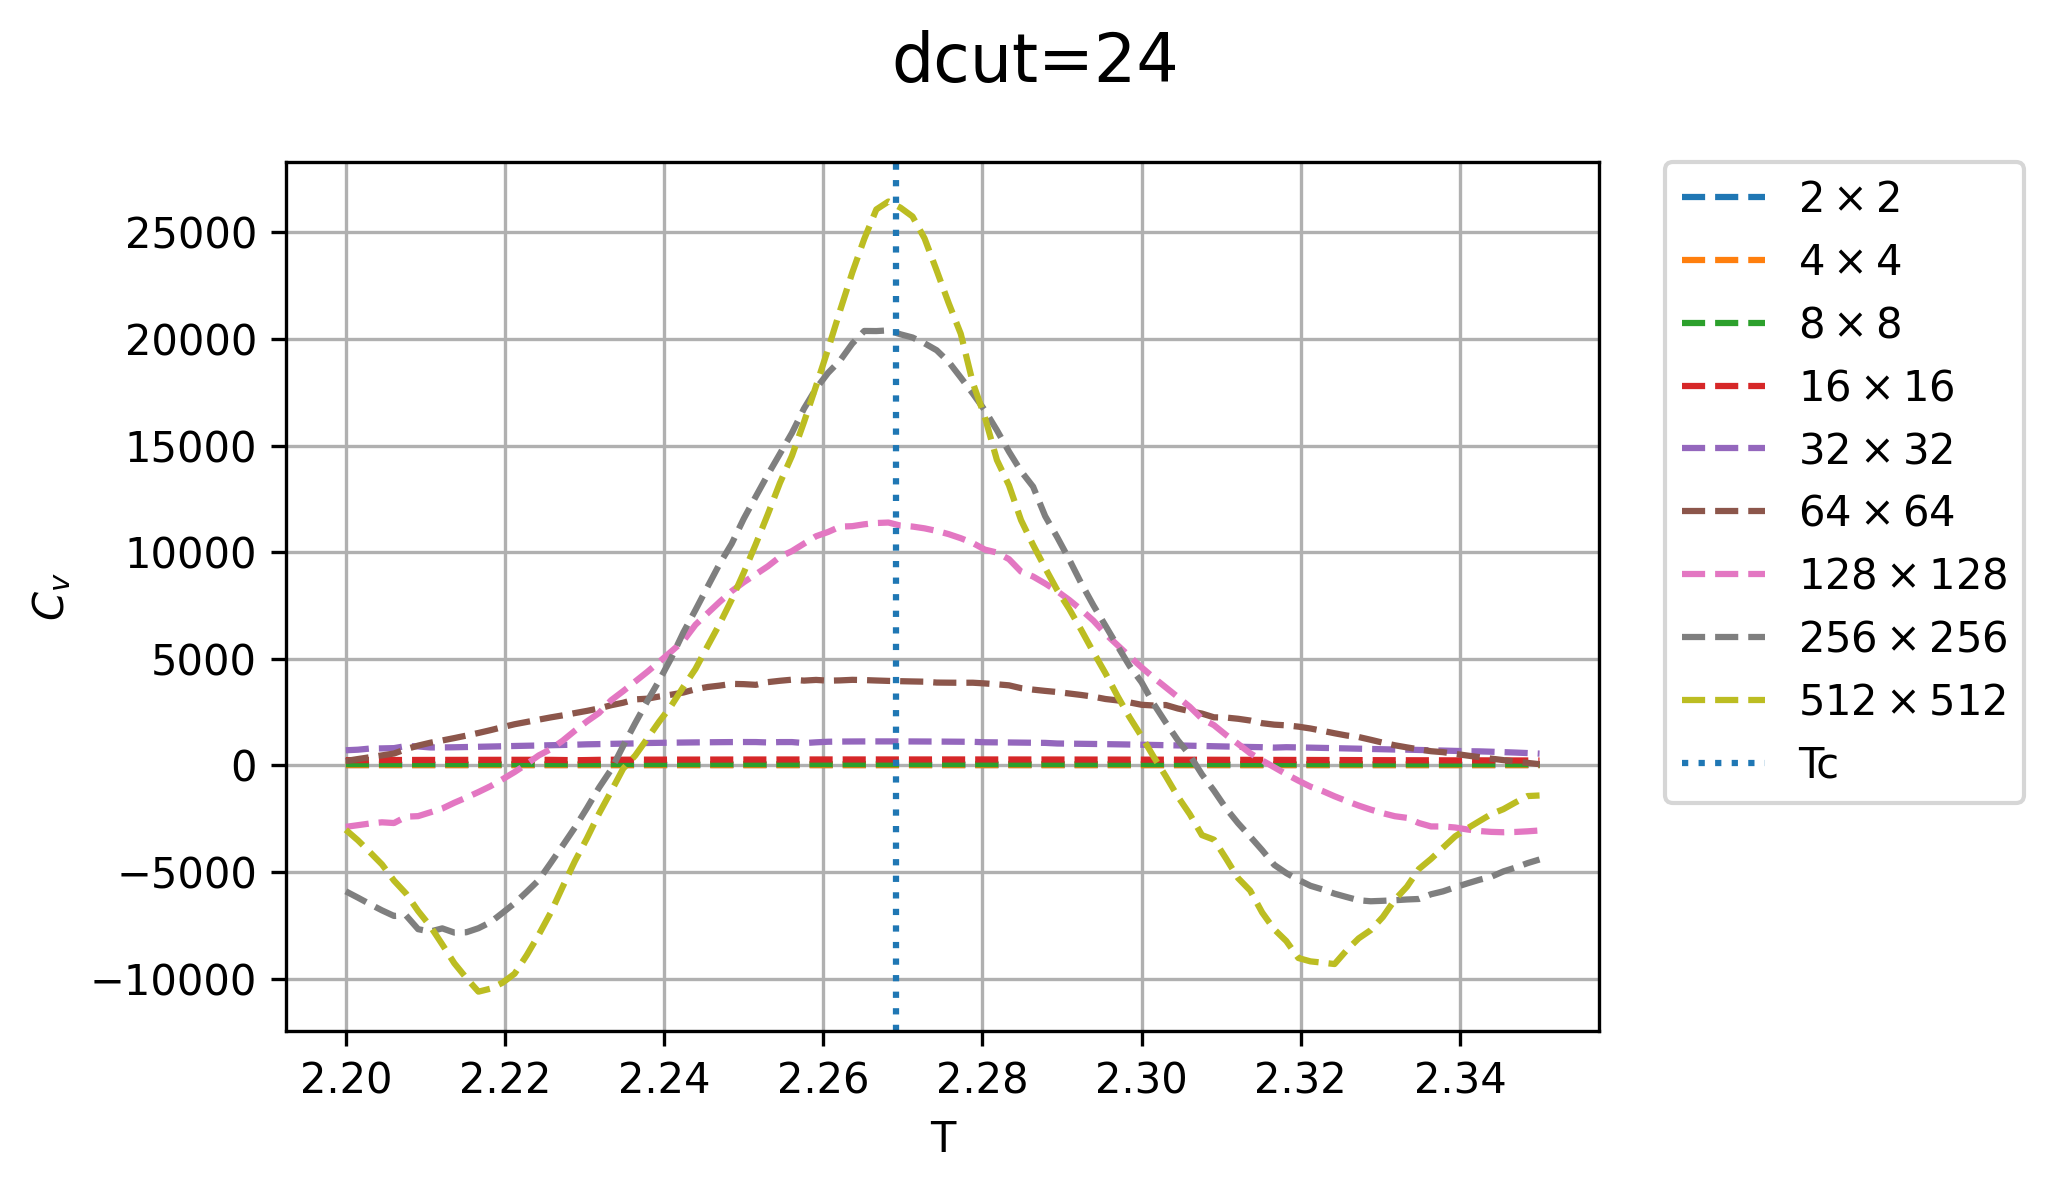

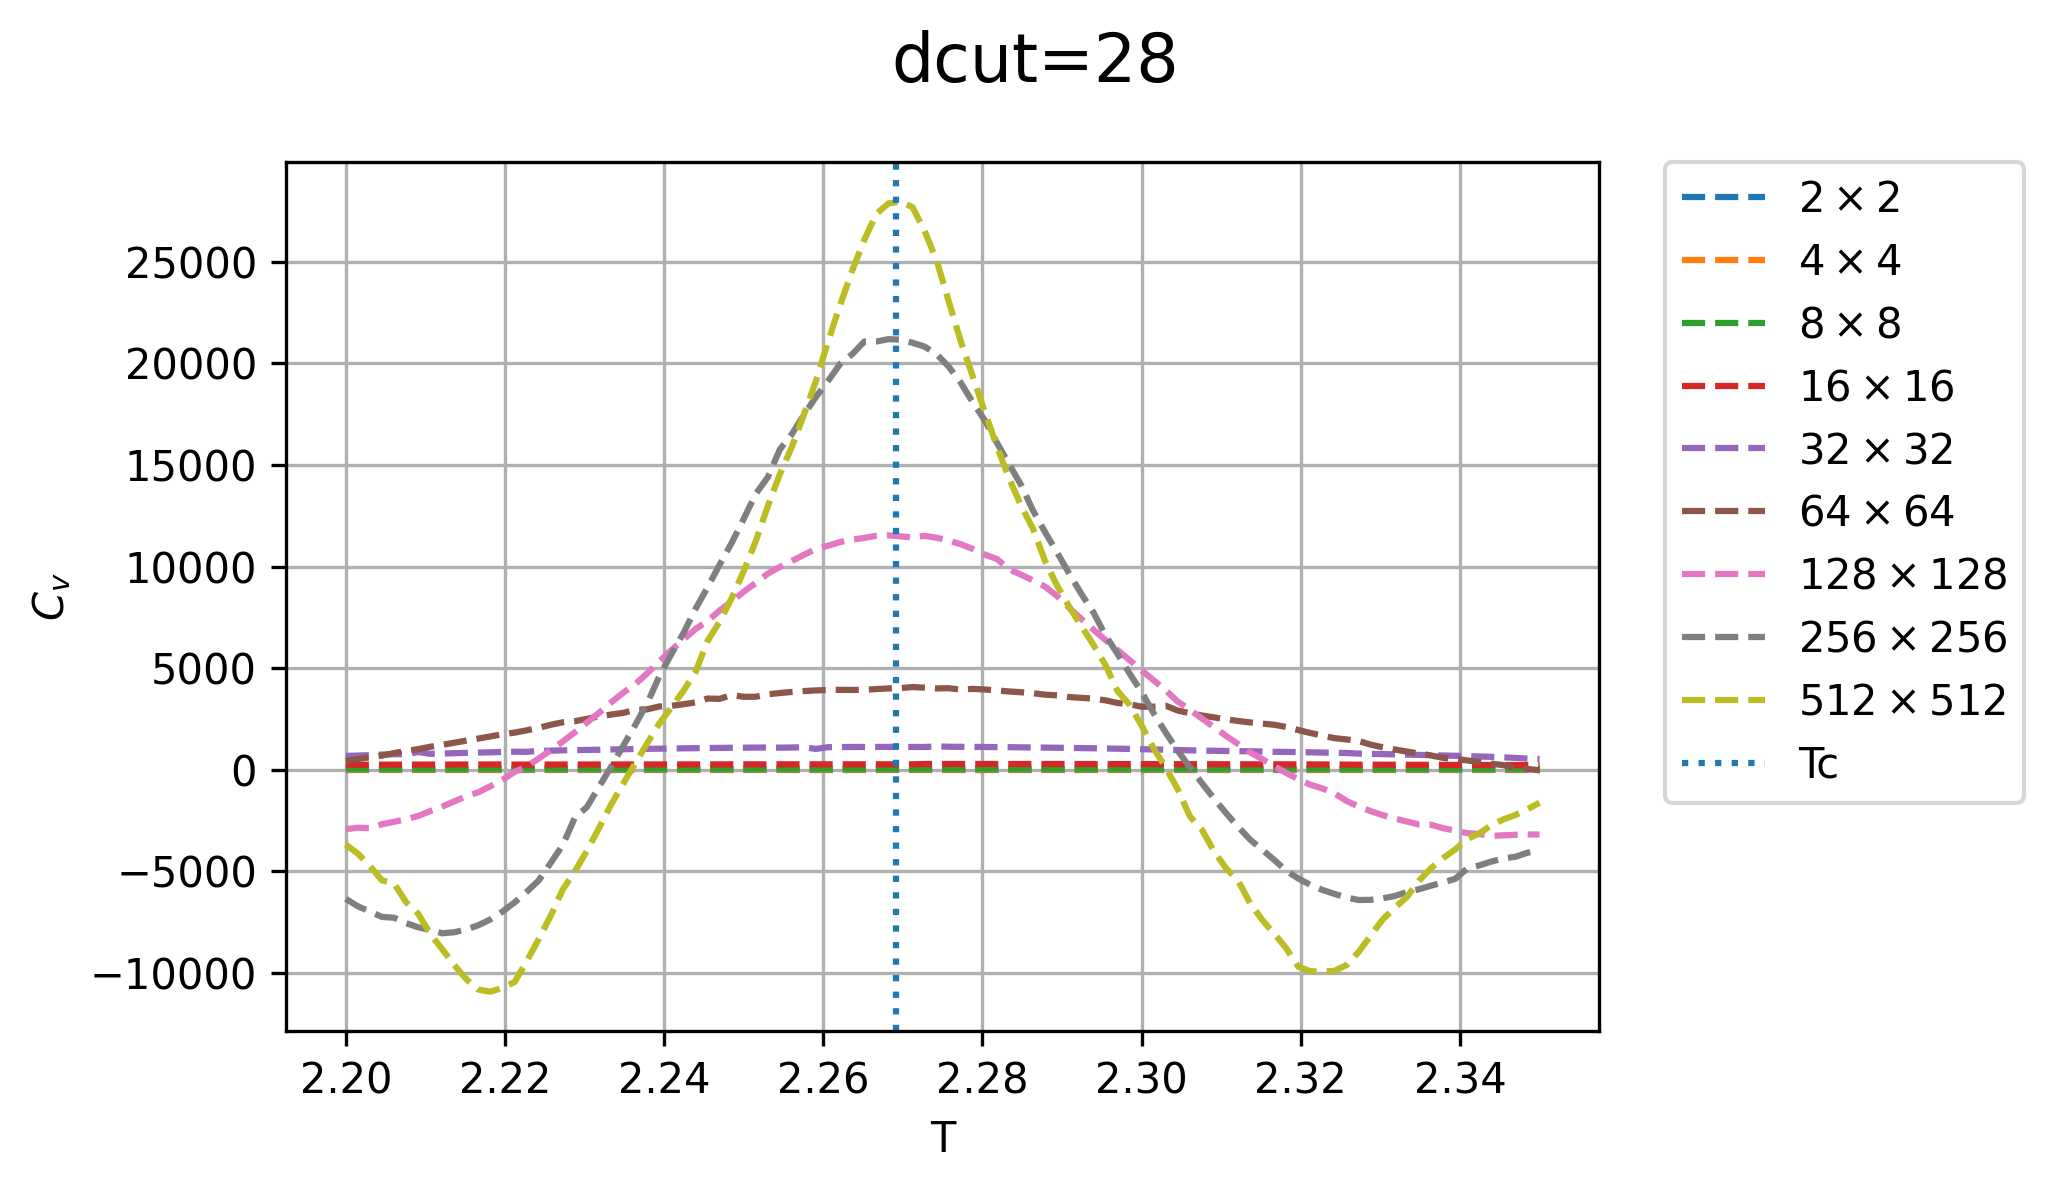

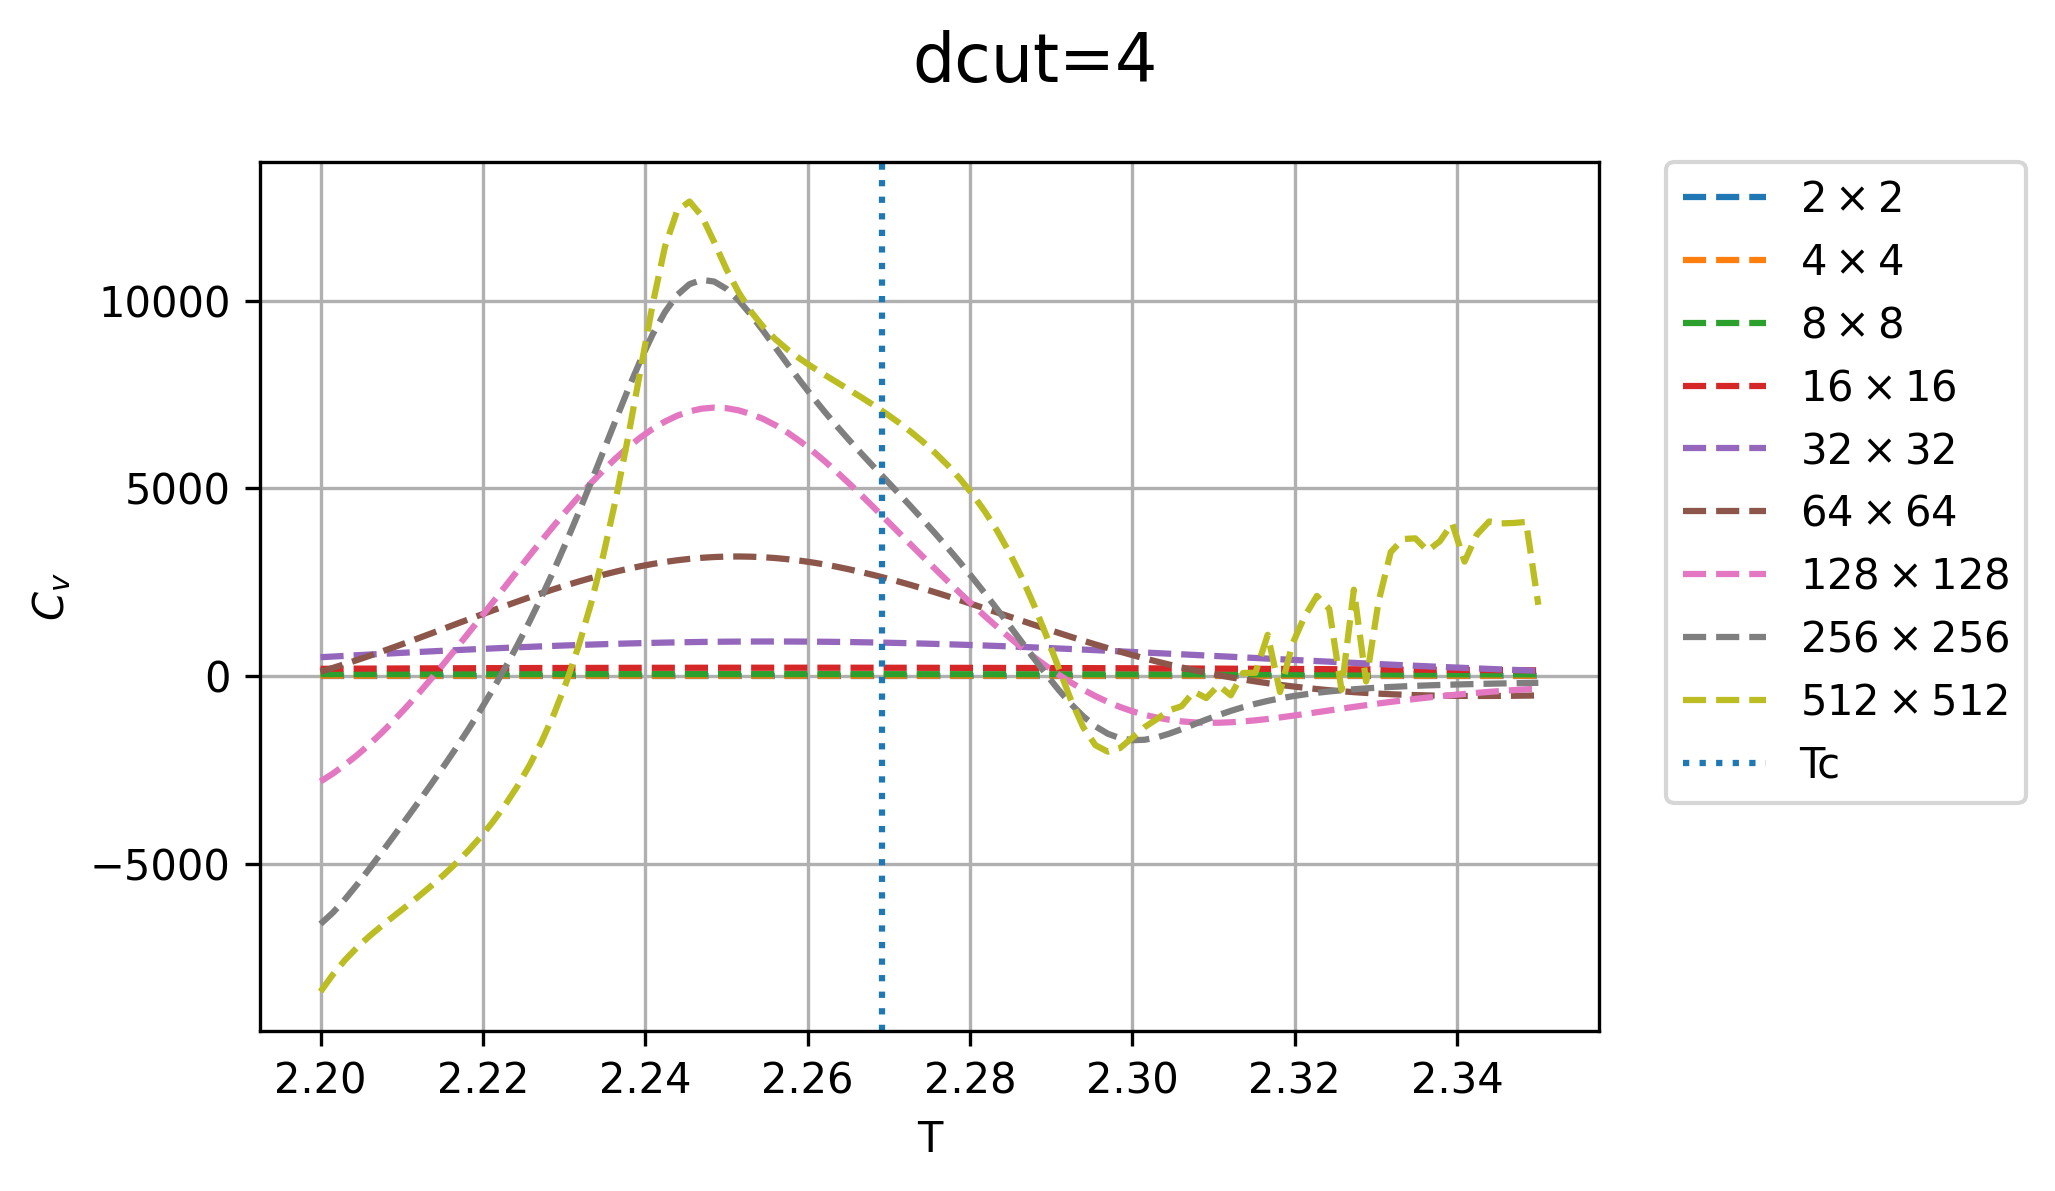

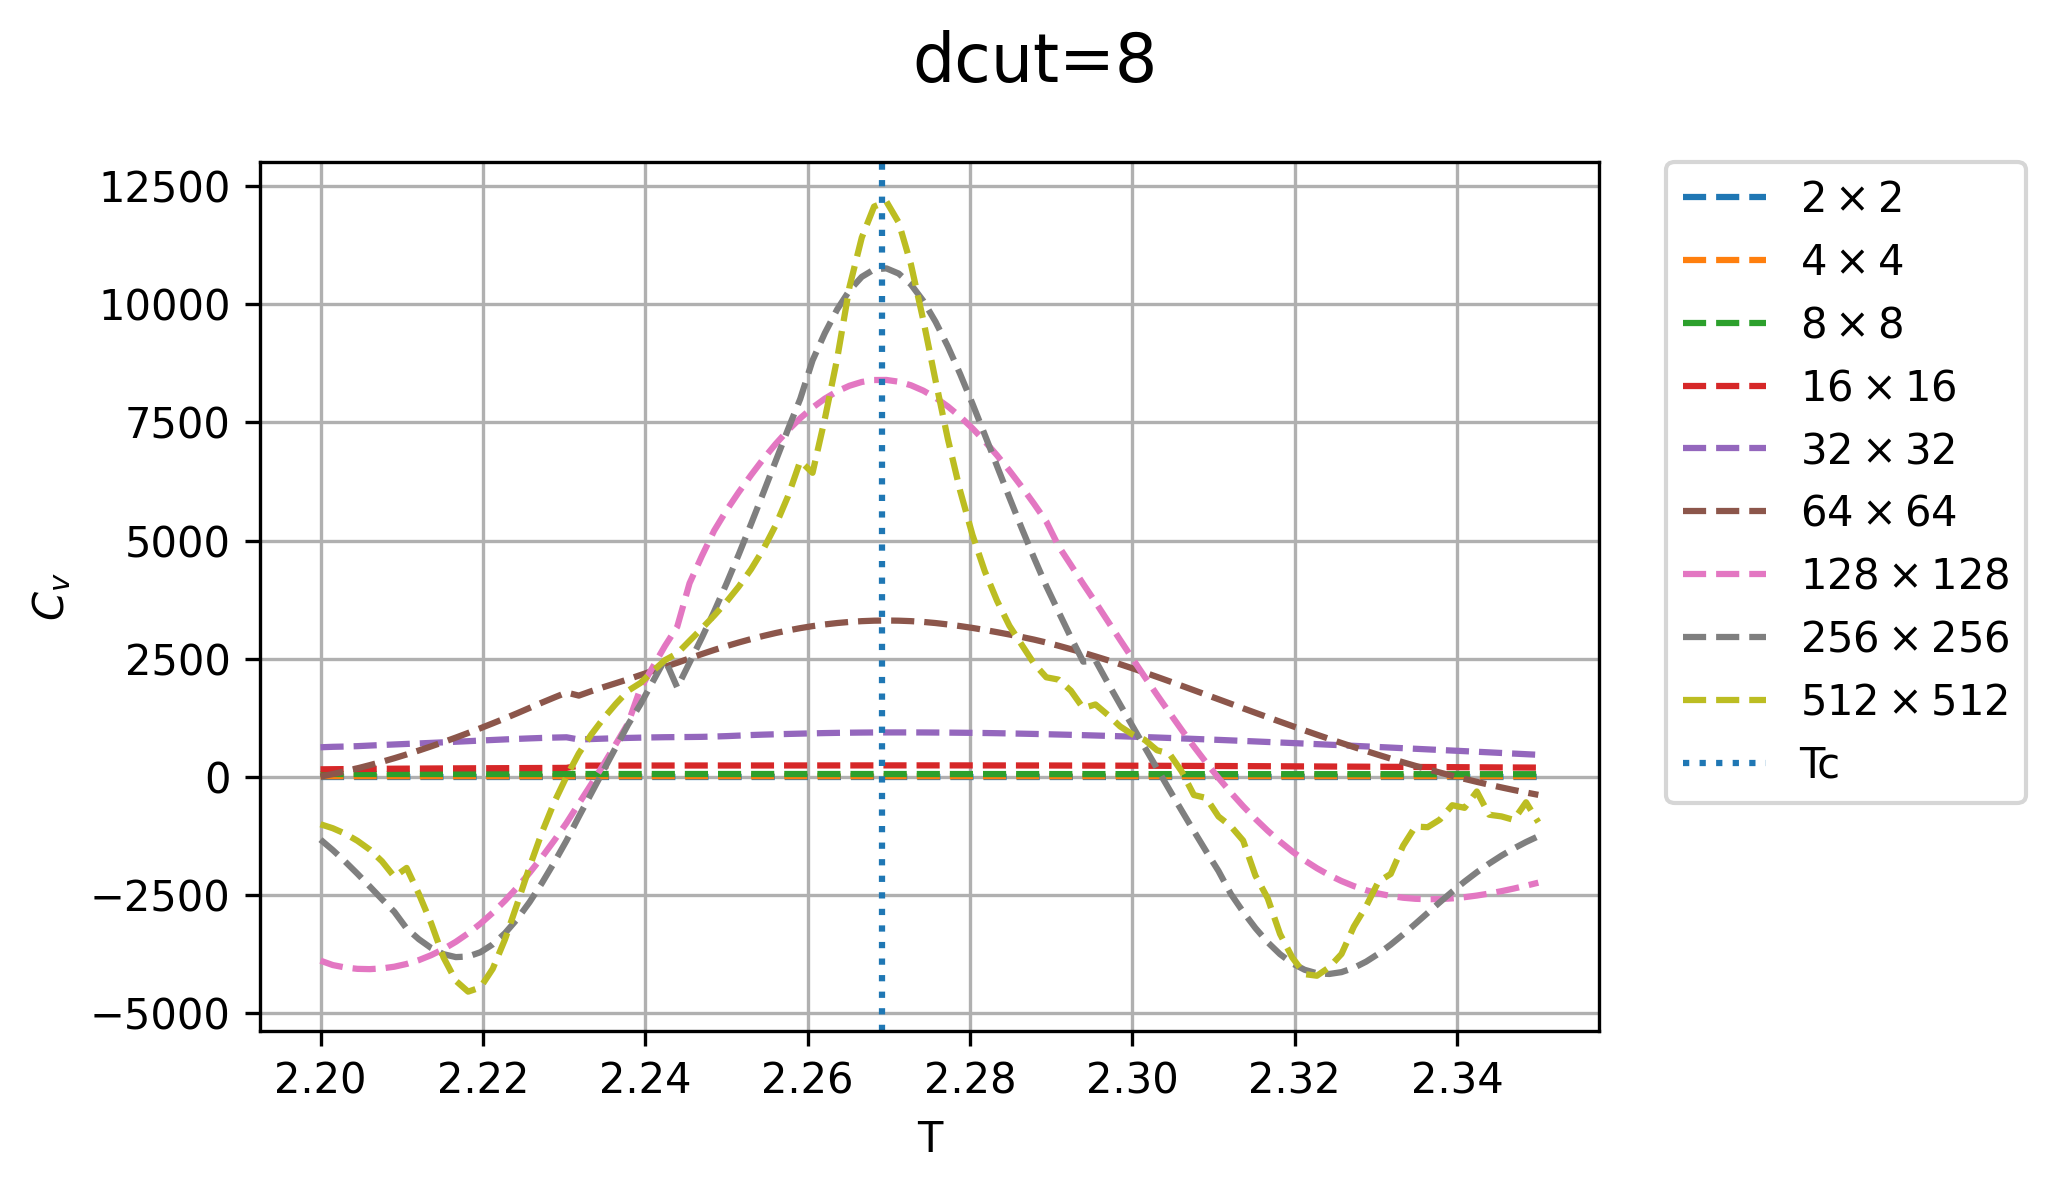

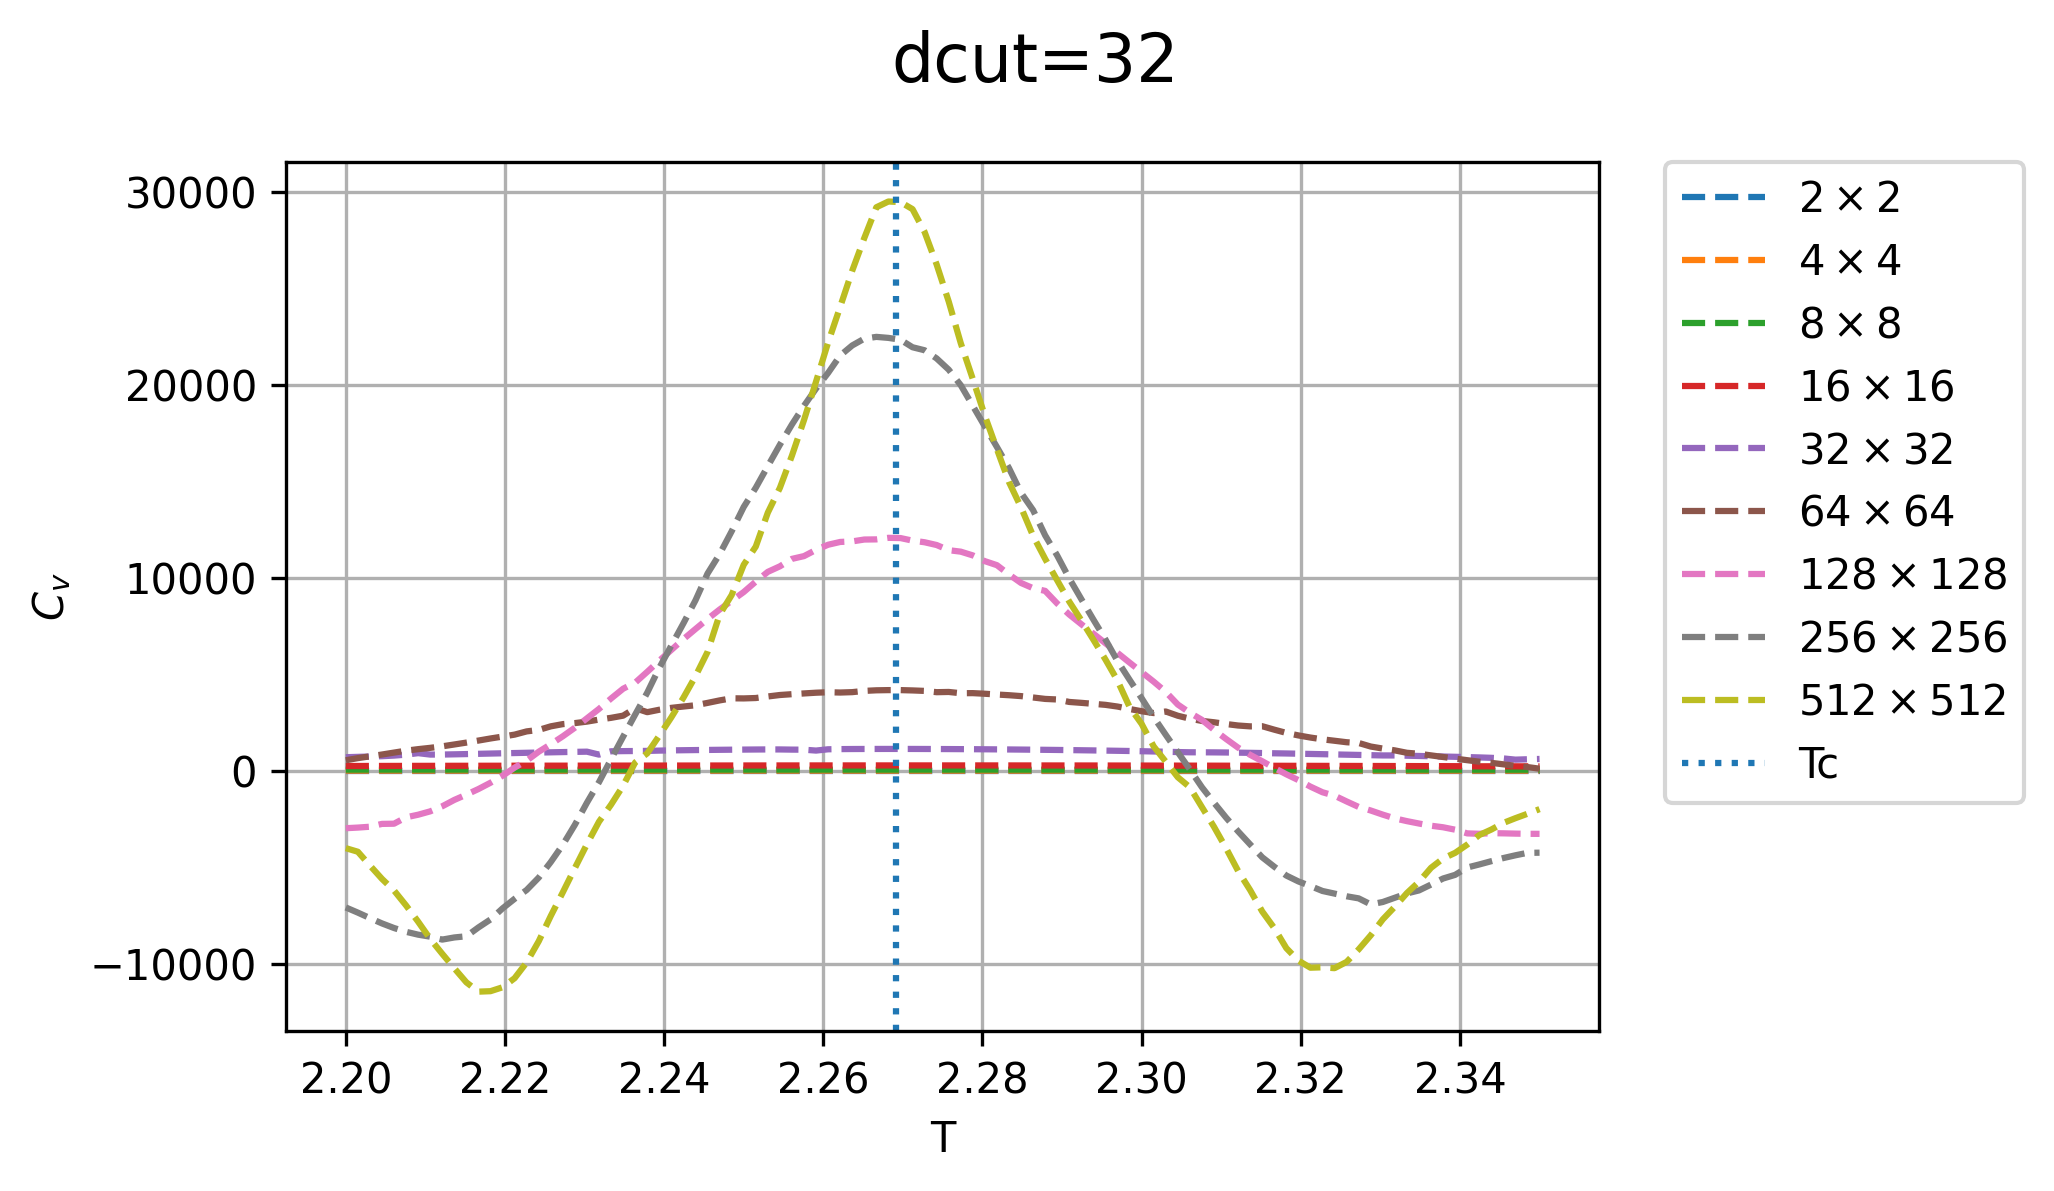

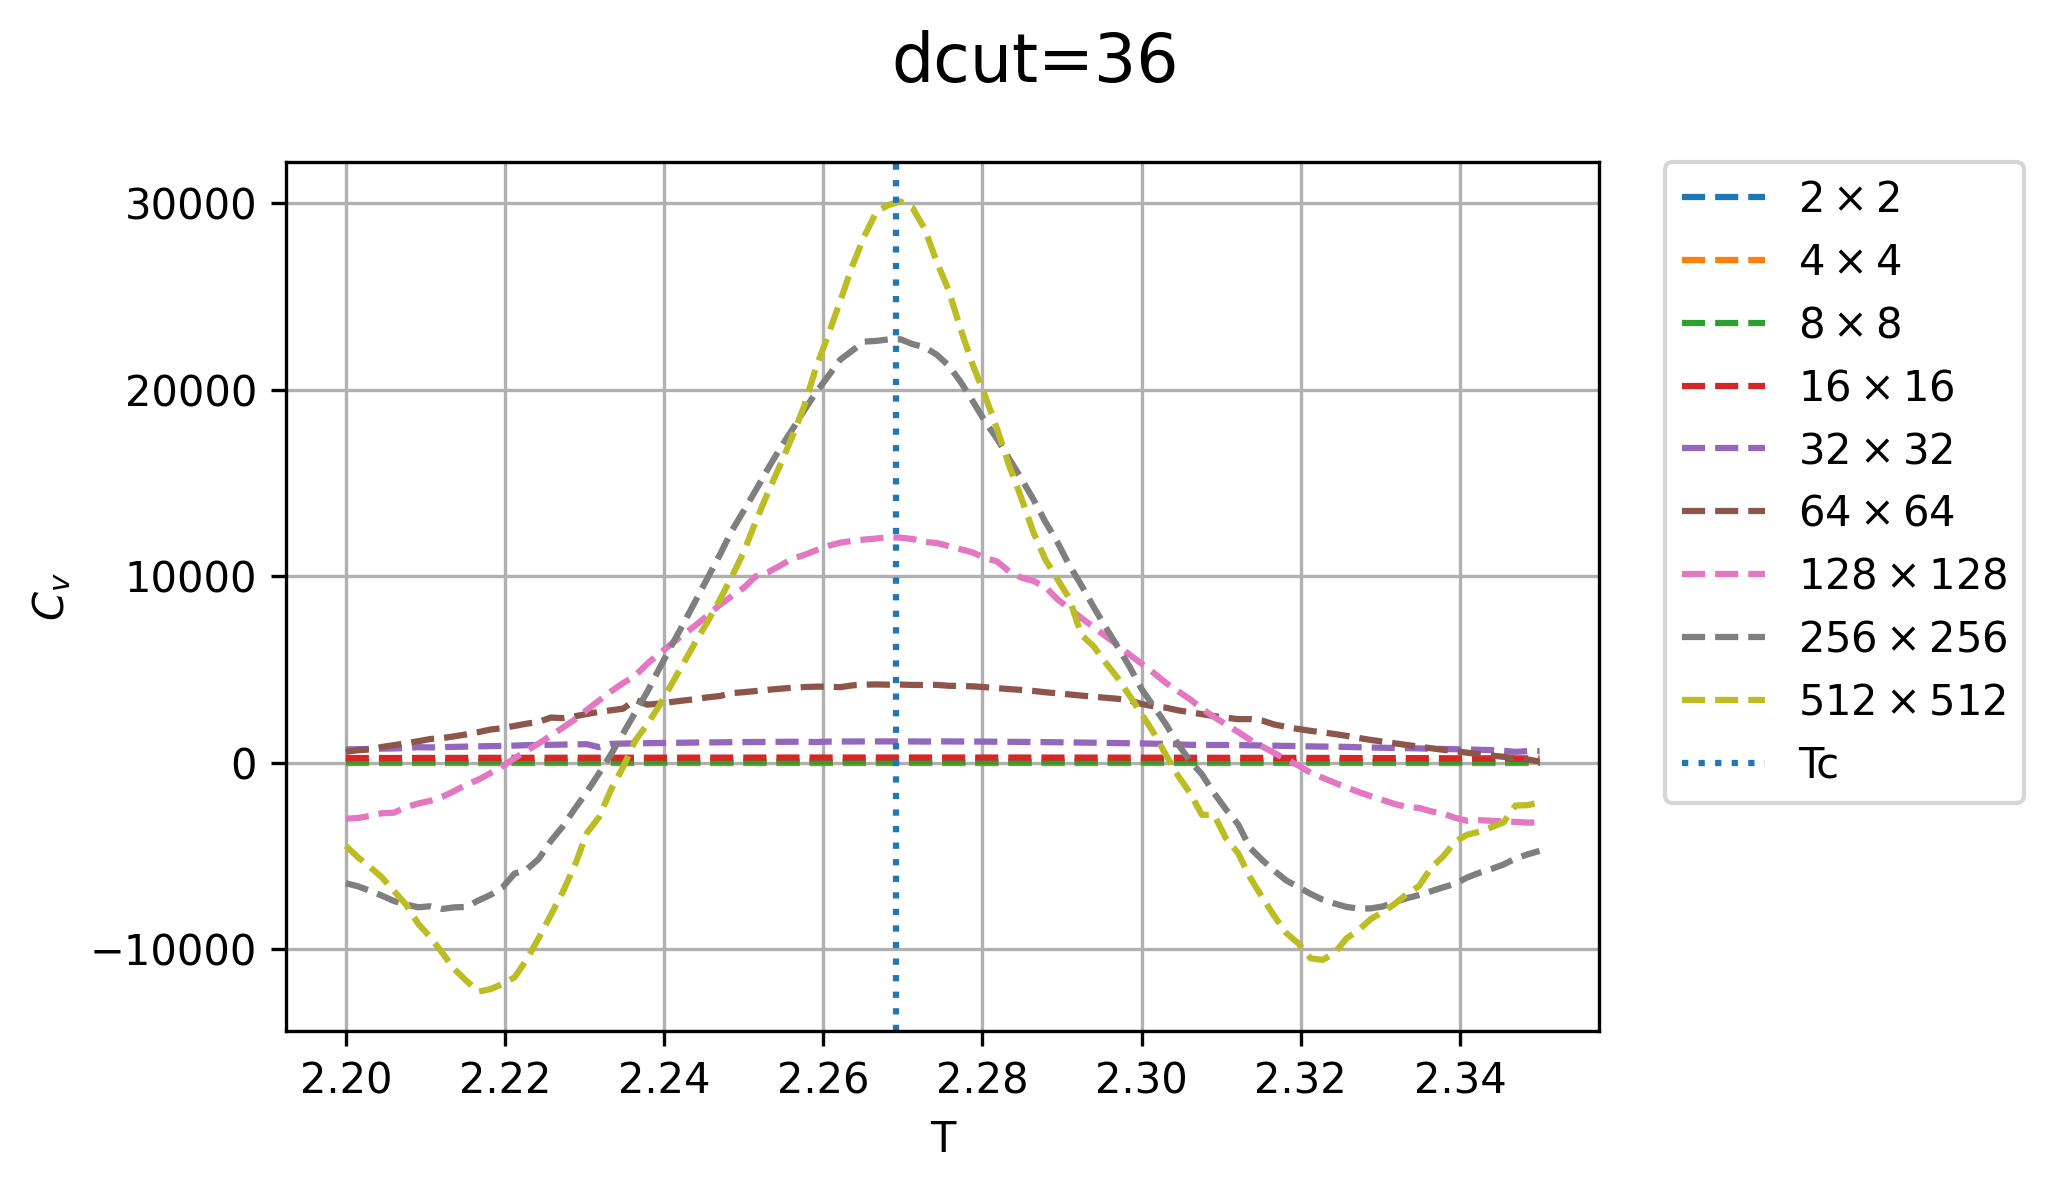

In [8]:
import os
import pickle
import glob
import matplotlib.pyplot as plt

# Pattern to find all relevant files
file_pattern = "Cv_results_*.pkl"

# Load all files
files = glob.glob(file_pattern)

# Iterate through files and plot data
for file in files:
    with open(file, "rb") as f:
        data = pickle.load(f)
    
    MaxL = 10
    Temp = data["Temp"]
    Cv = data["Cv"]
    Tc = data["Tc"]
    dcut = data["dcut"]
    
    # Plotting
    plt.figure(figsize=(7, 4), dpi=300)
    plt.suptitle(f'dcut={dcut}', fontsize=16)
    
    for i in range(2, MaxL + 1):
        plt.plot(Temp, Cv[i], '--', label=f'${2**(i-1)}\\times{2**(i-1)}$')
    
    plt.axvline(x=Tc, ls=':', label='Tc')
    plt.xlabel('T')
    plt.ylabel(r'$C_v$')
    plt.grid()
    plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
    plt.tight_layout()
    plt.show()


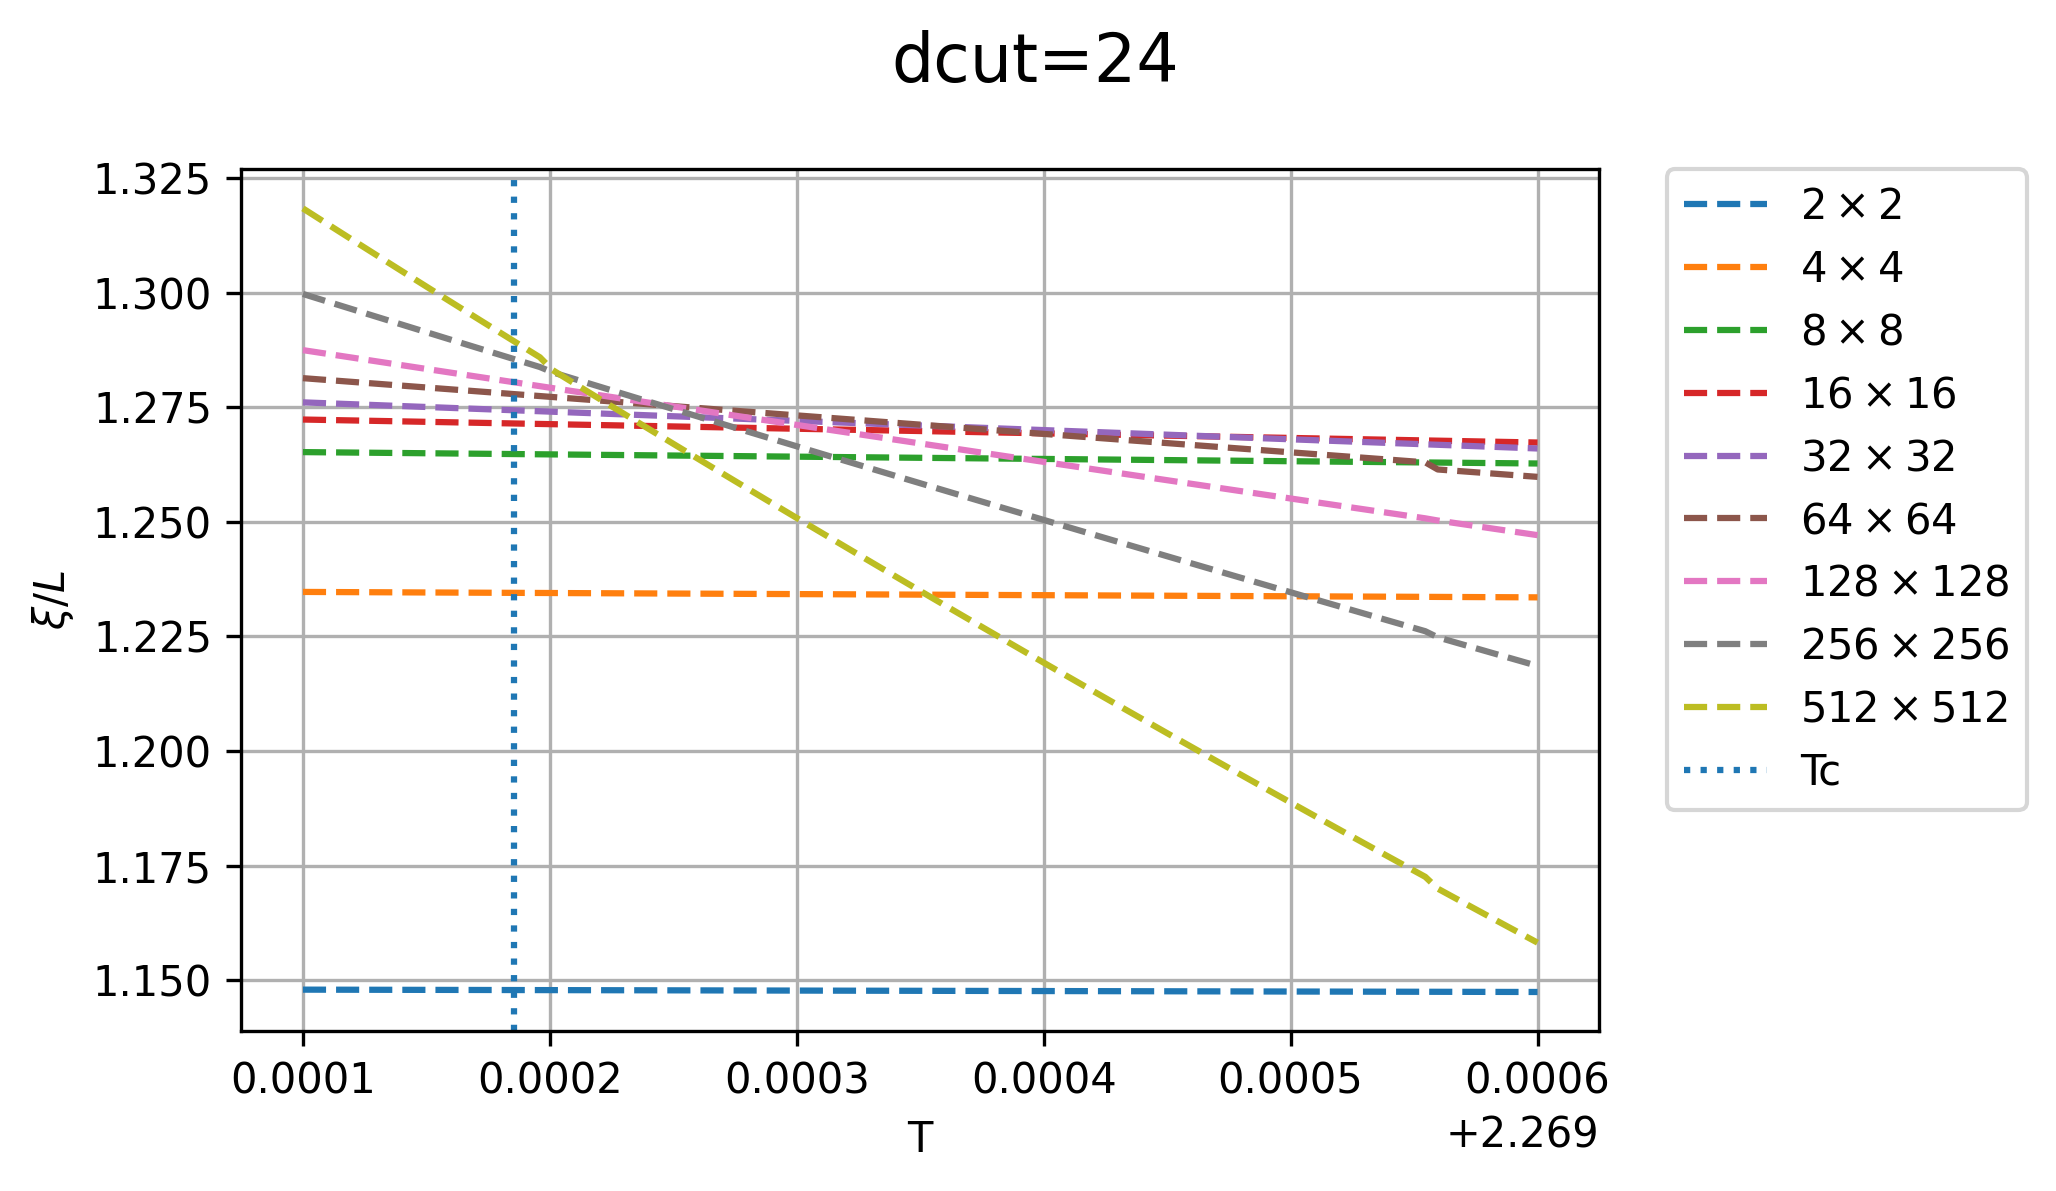

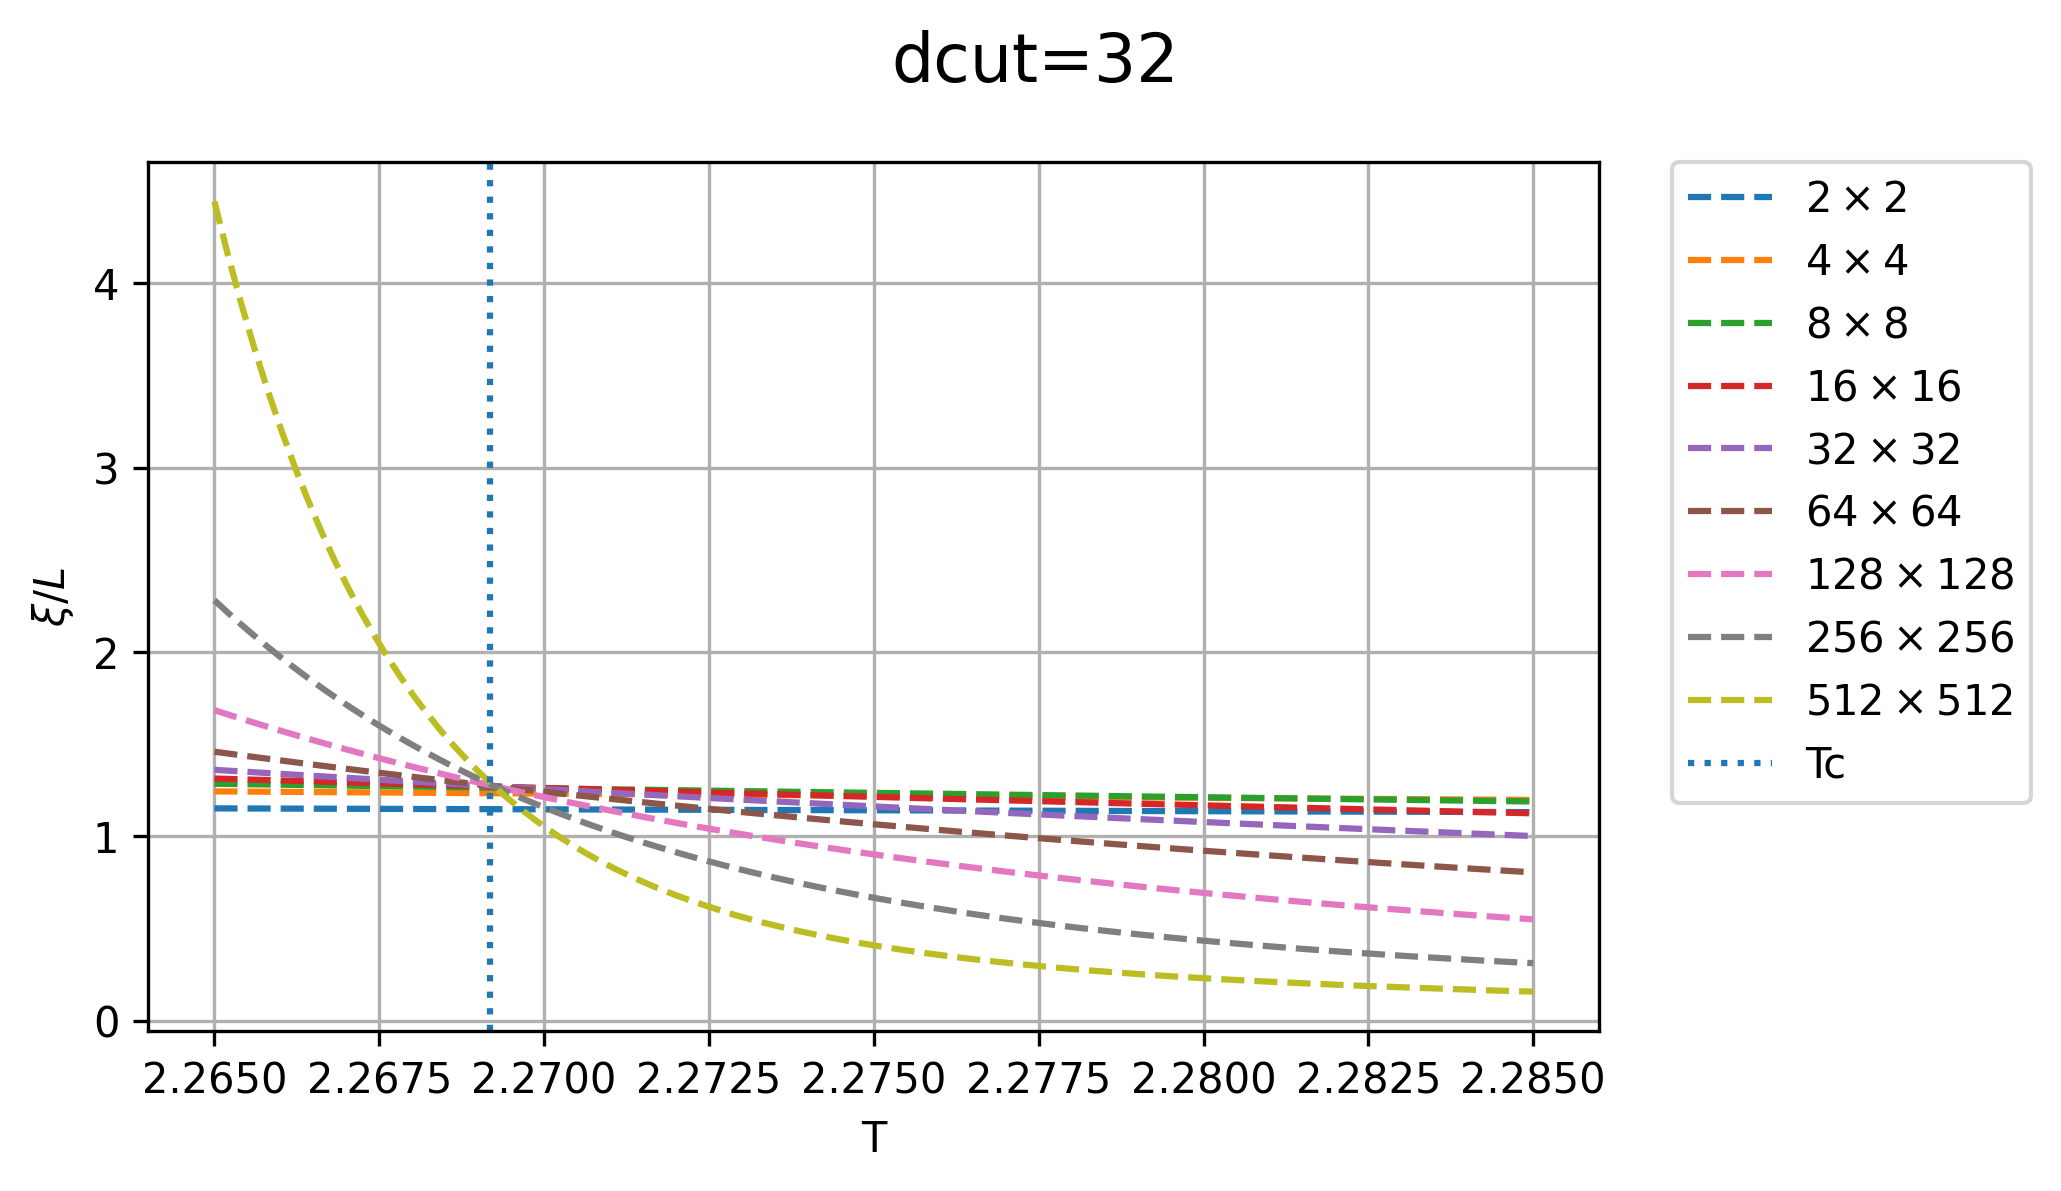

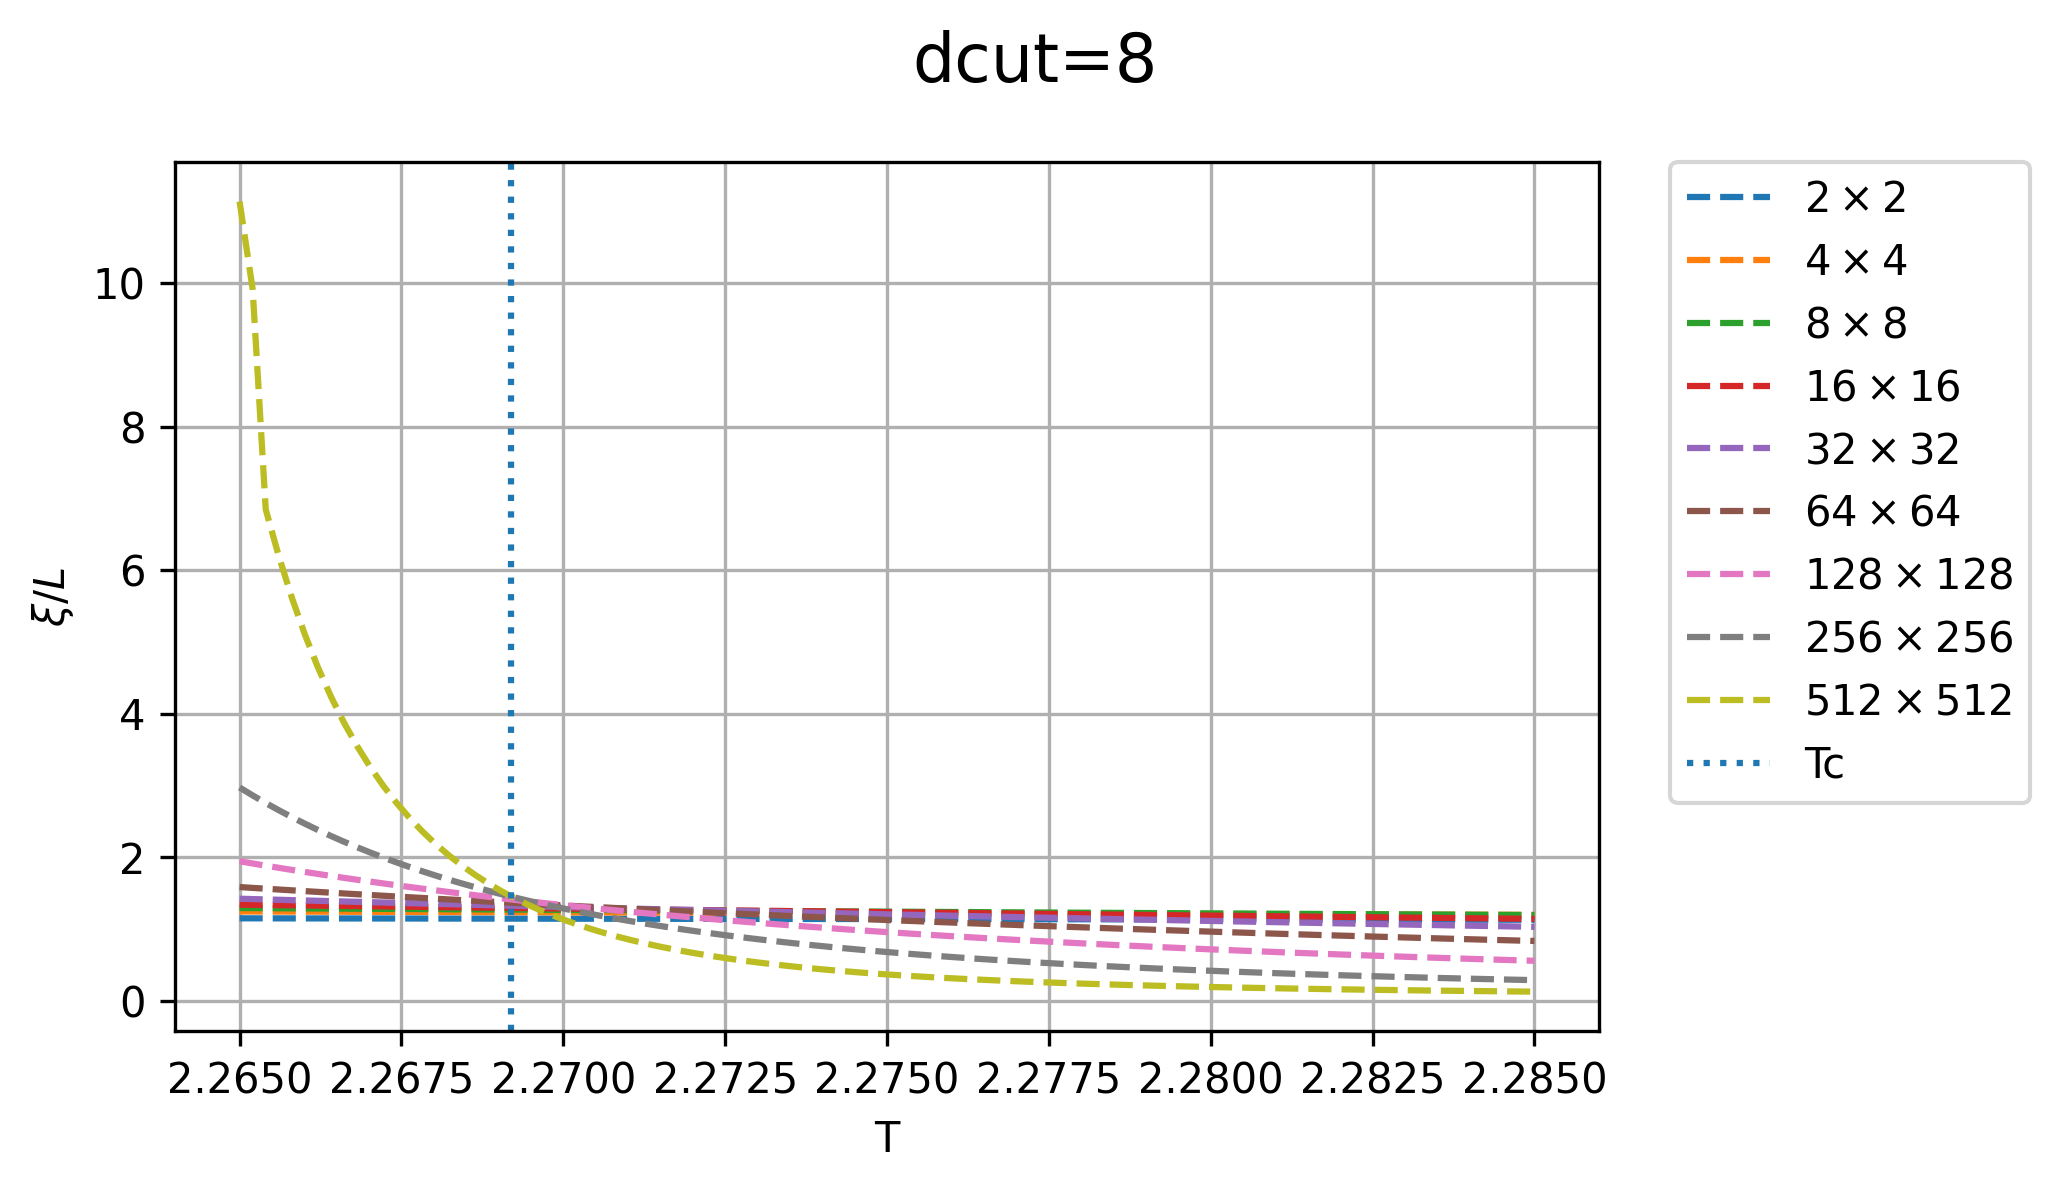

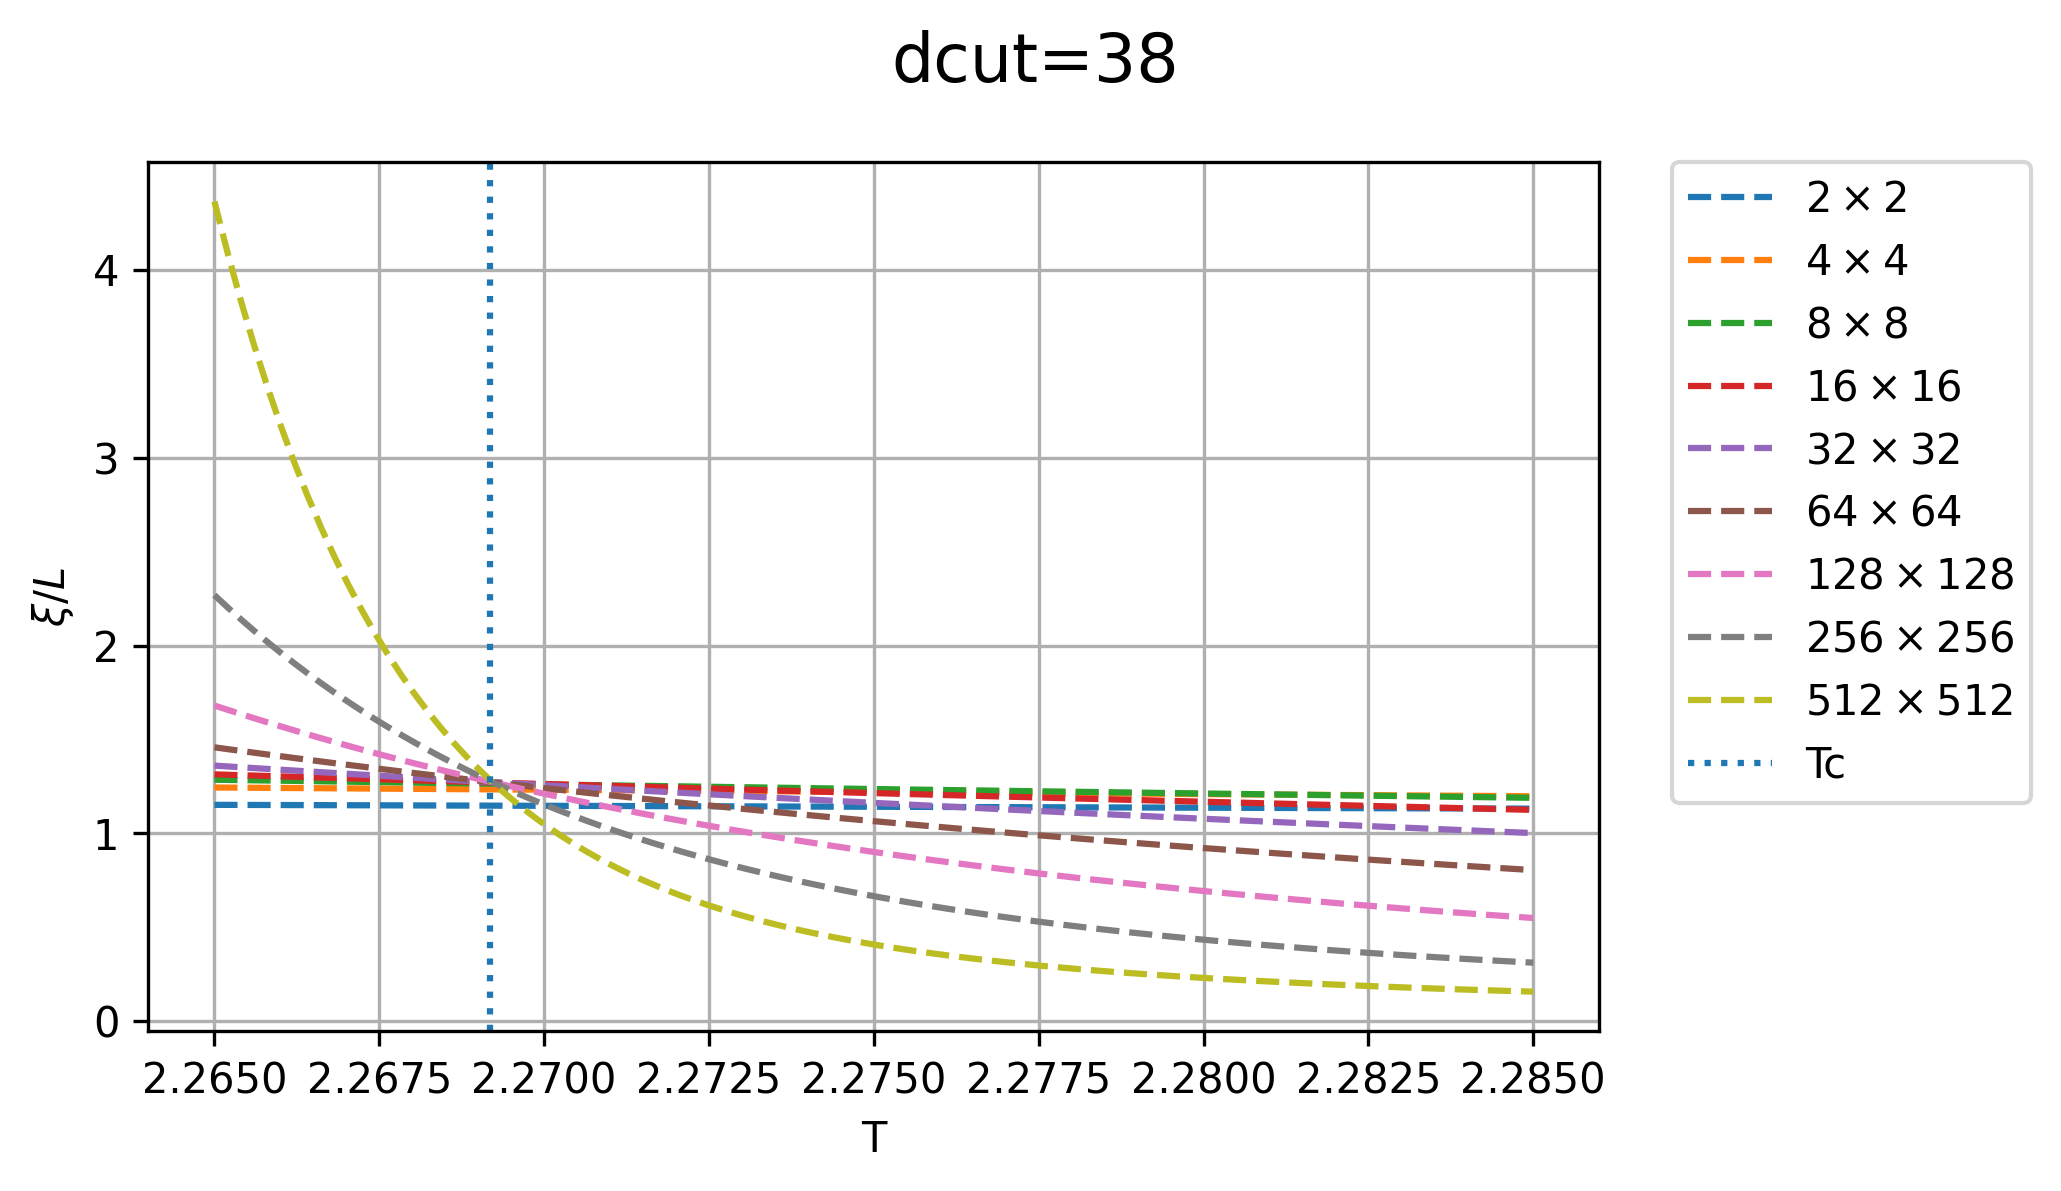

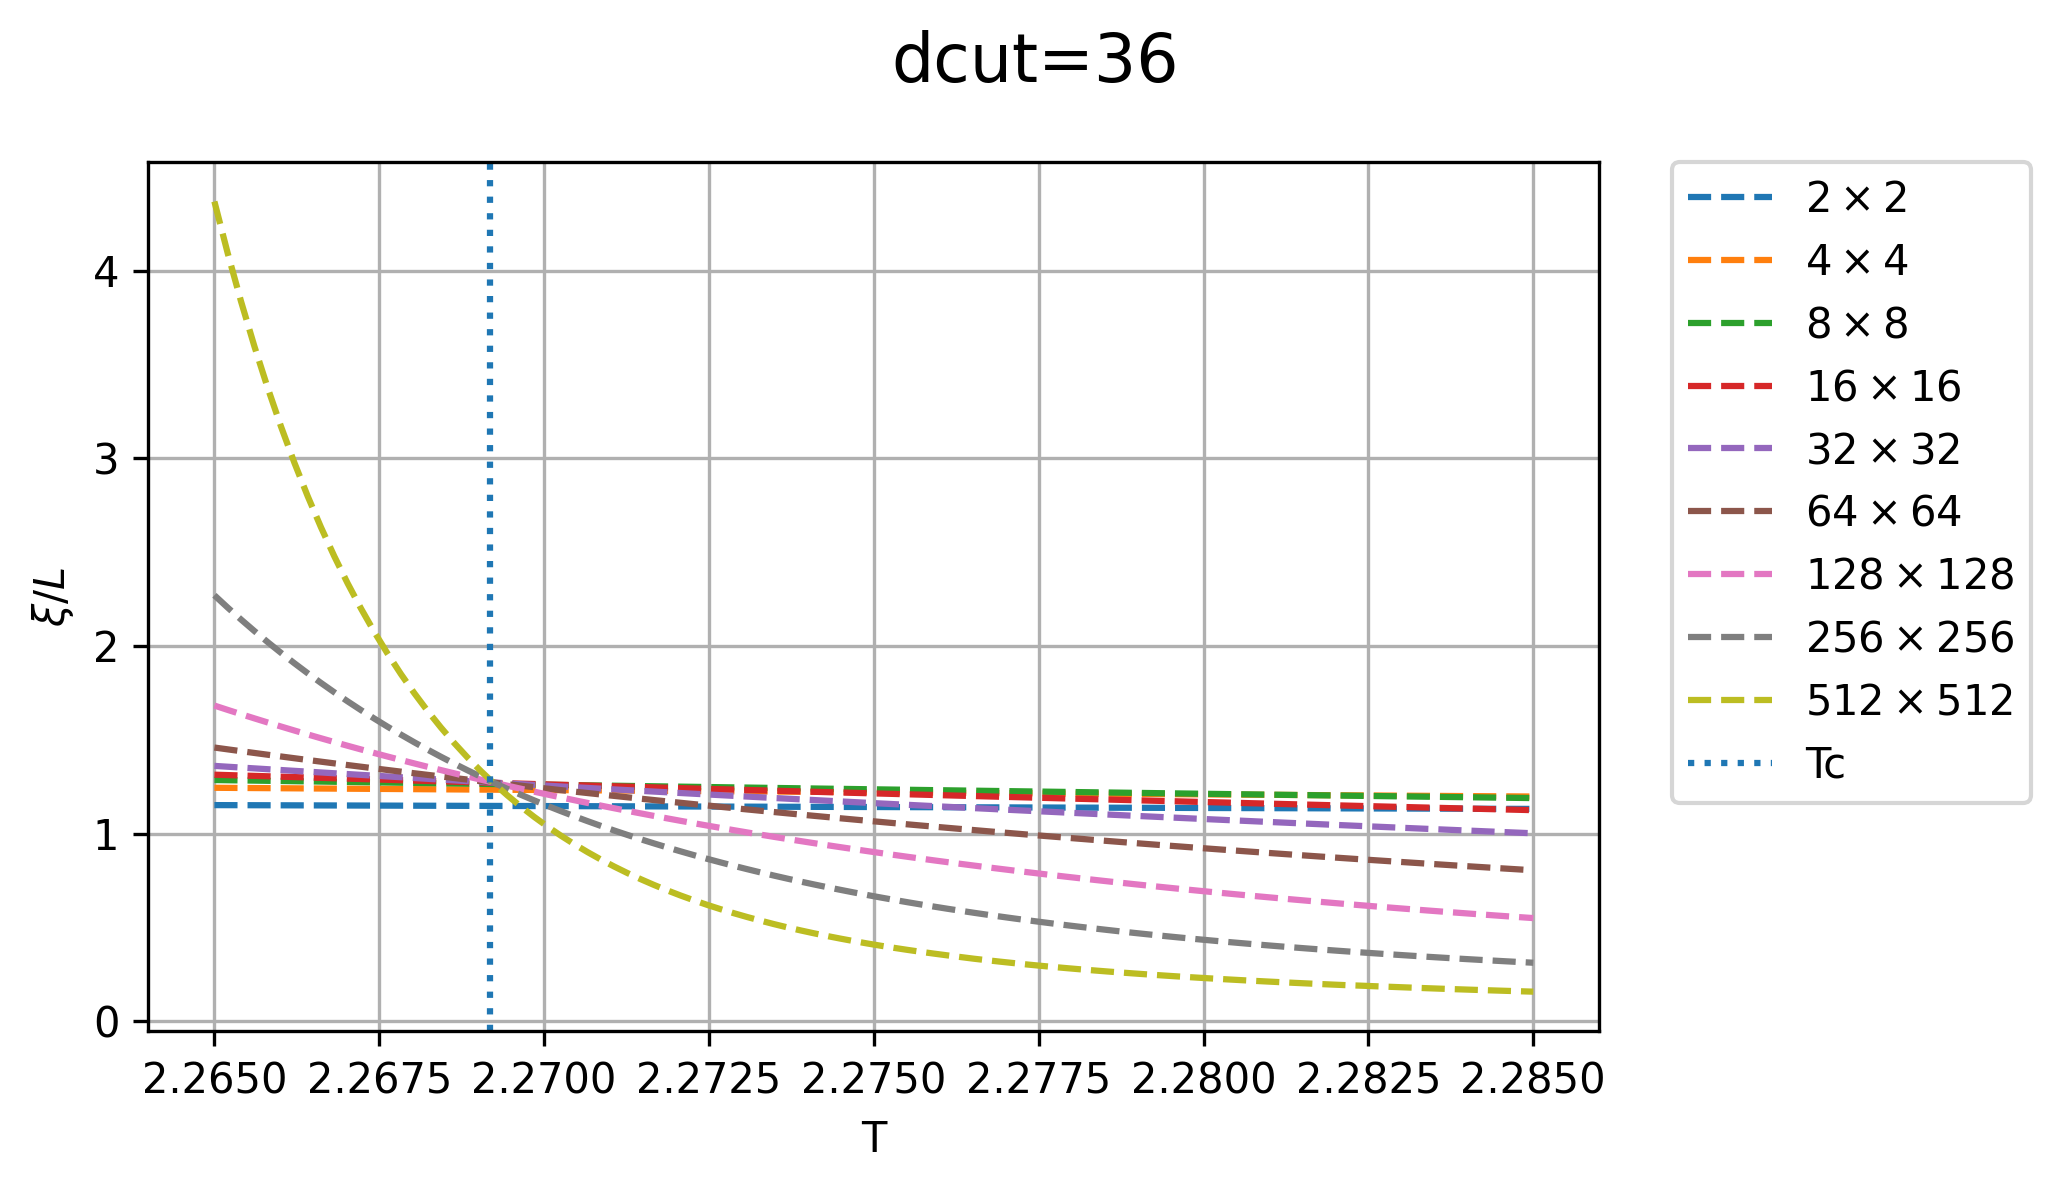

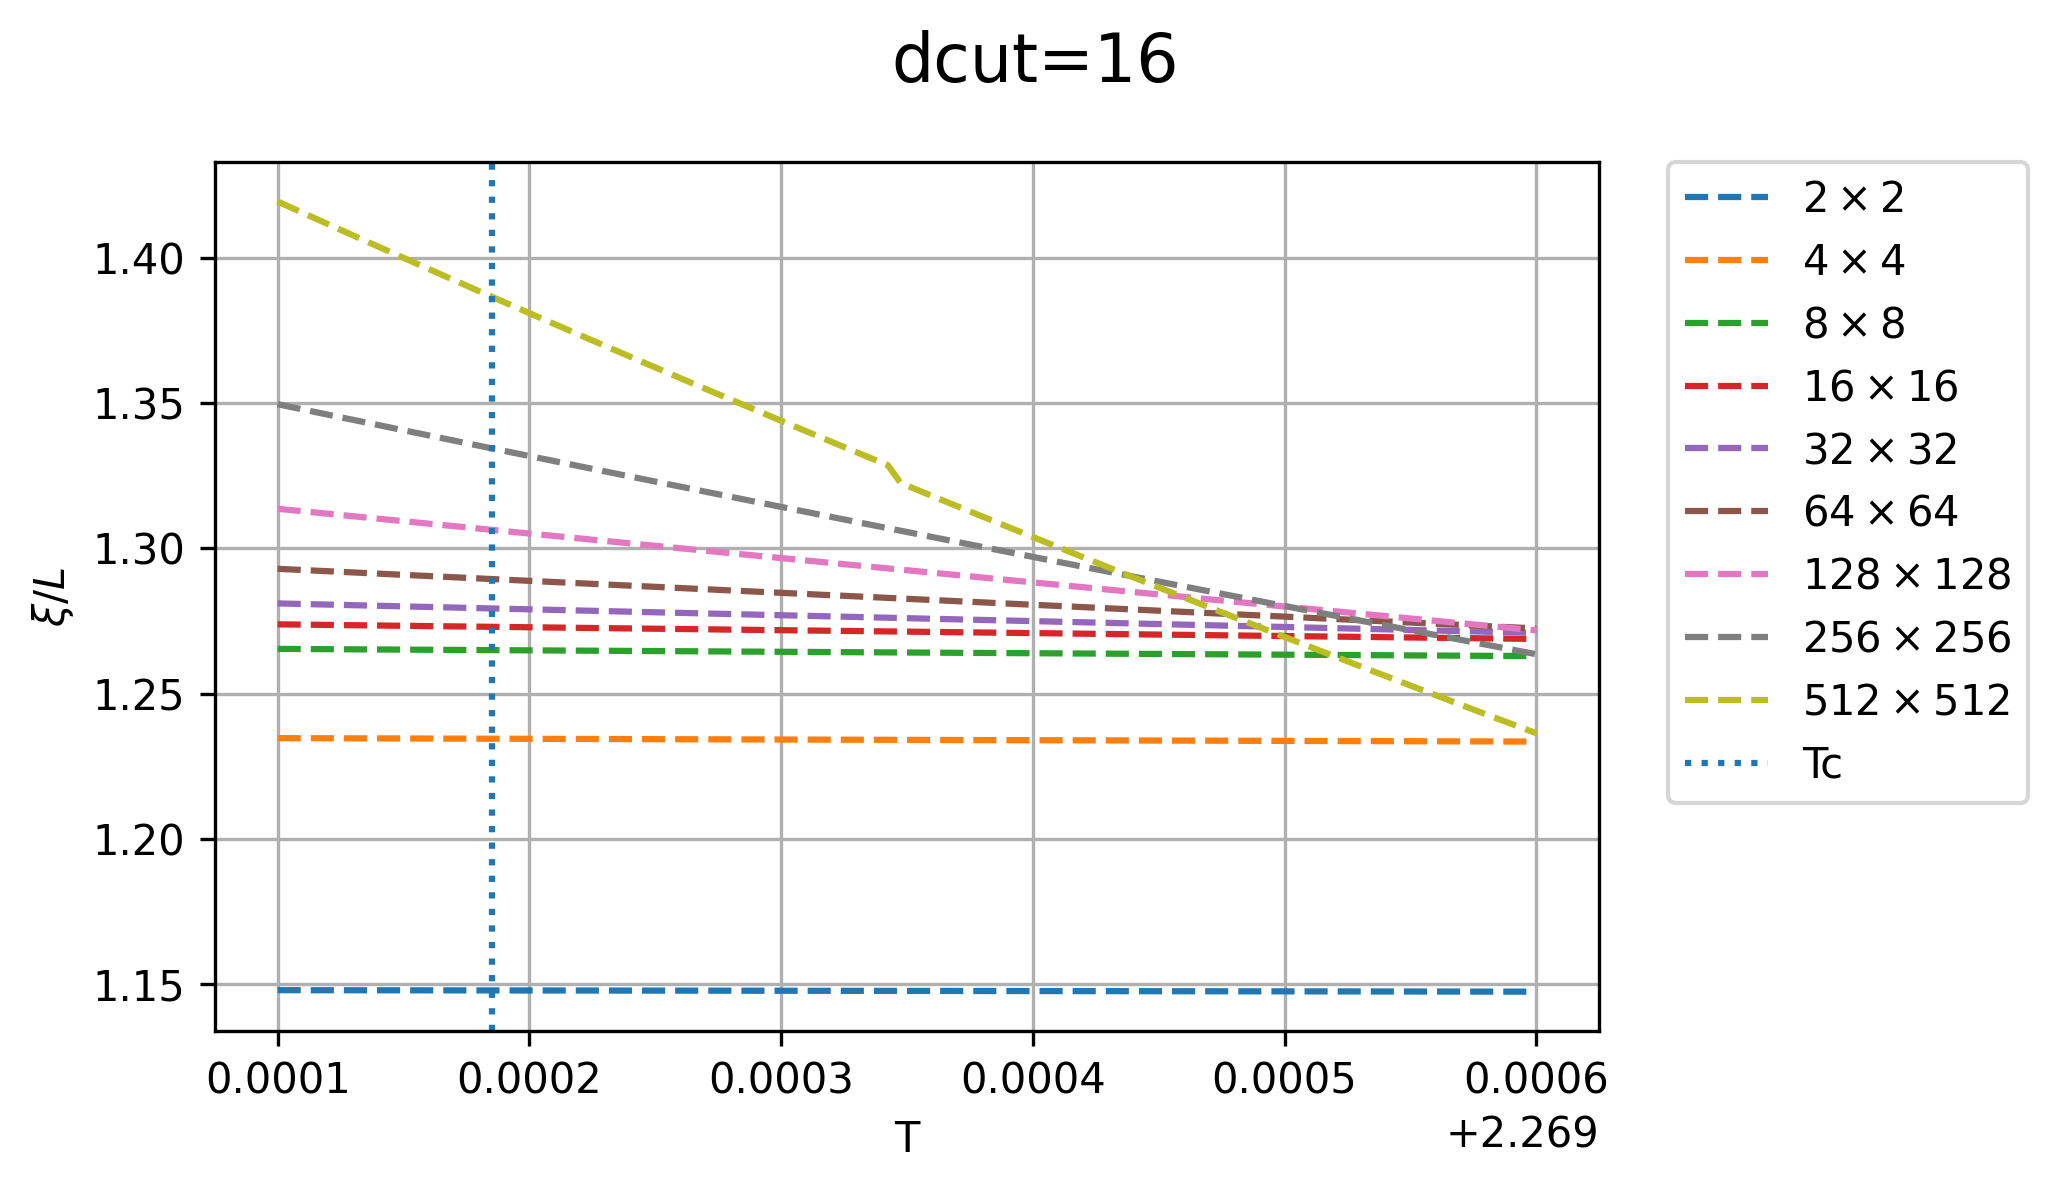

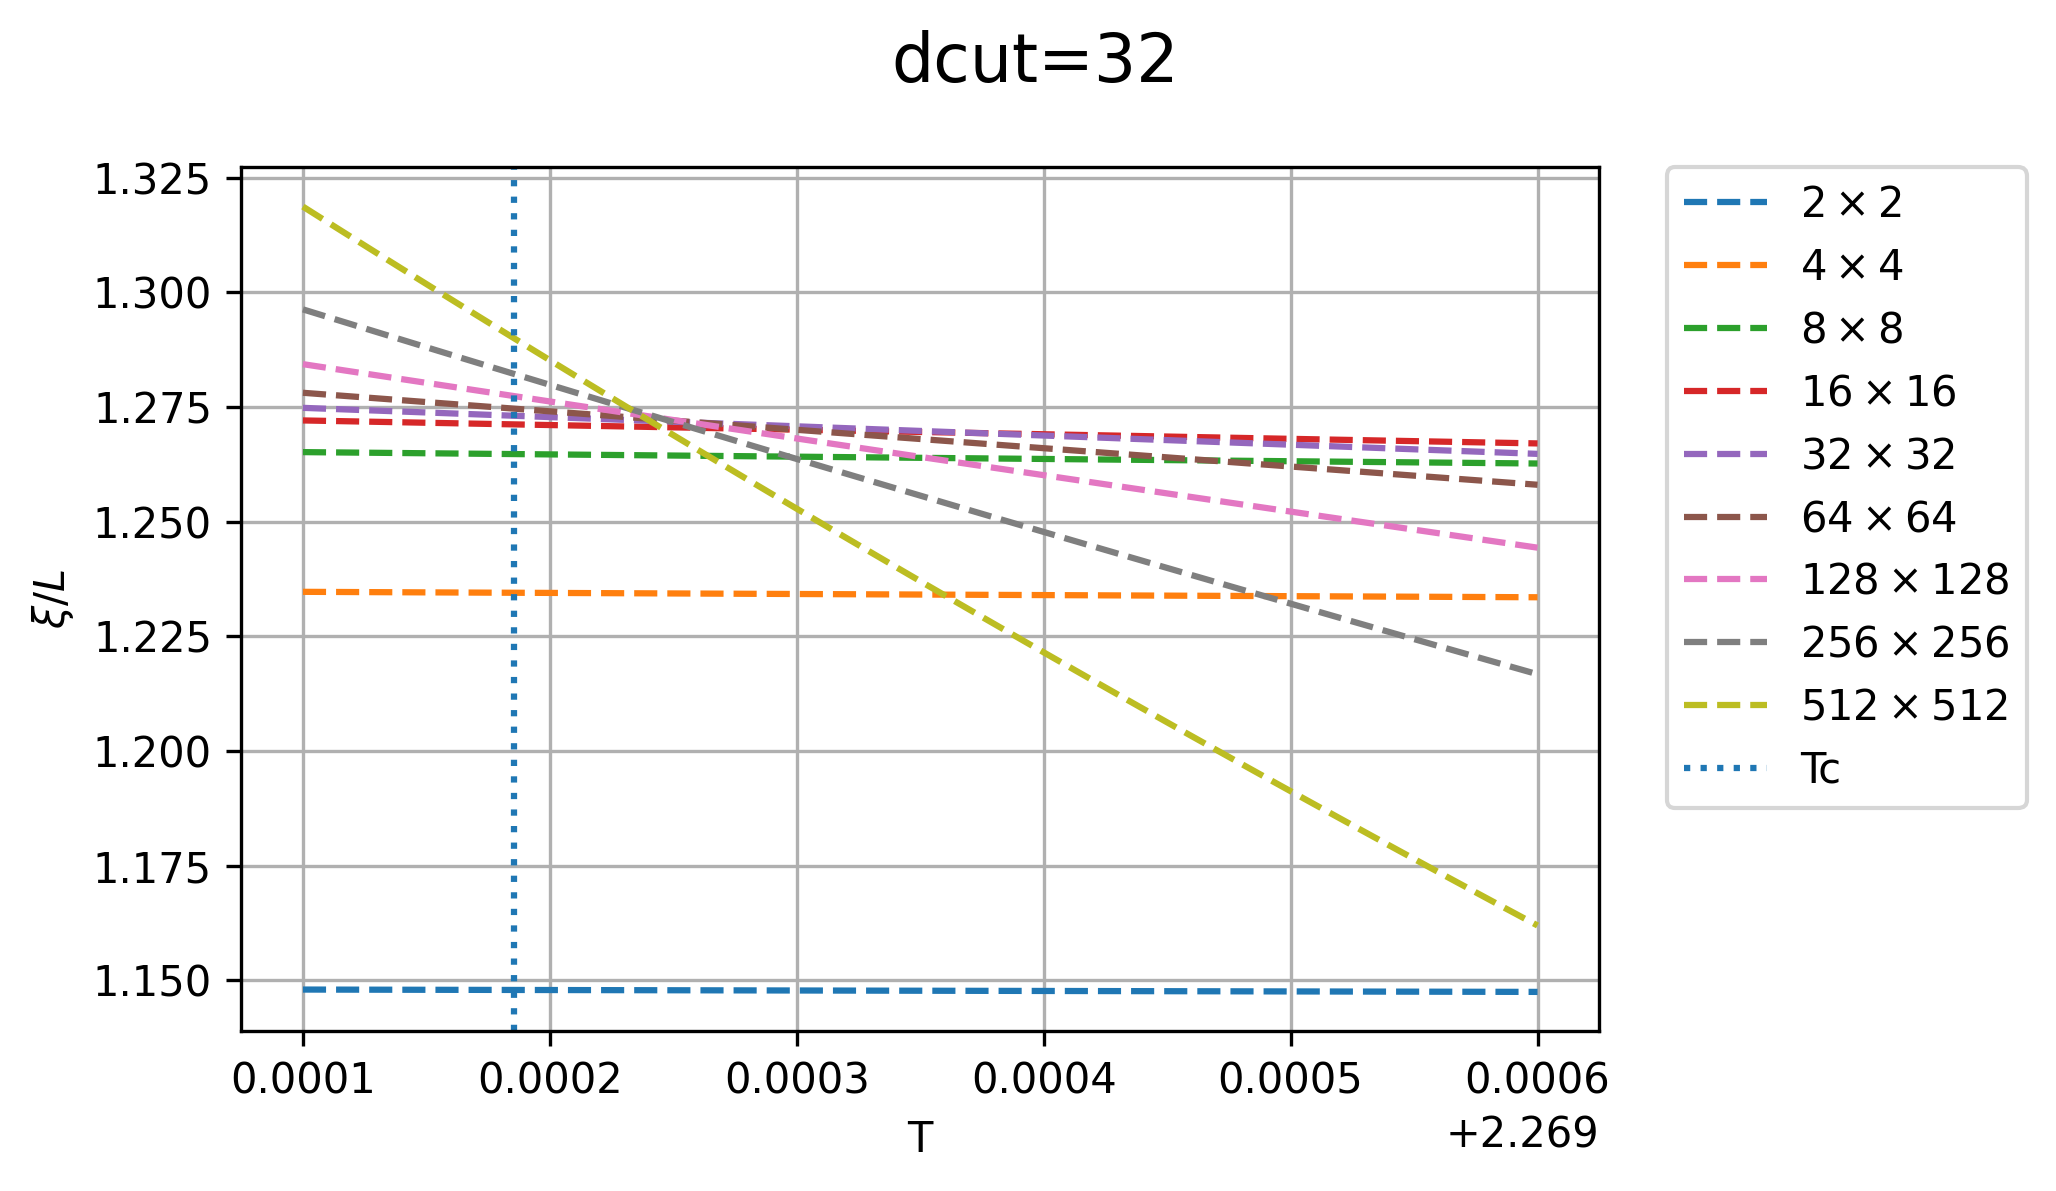

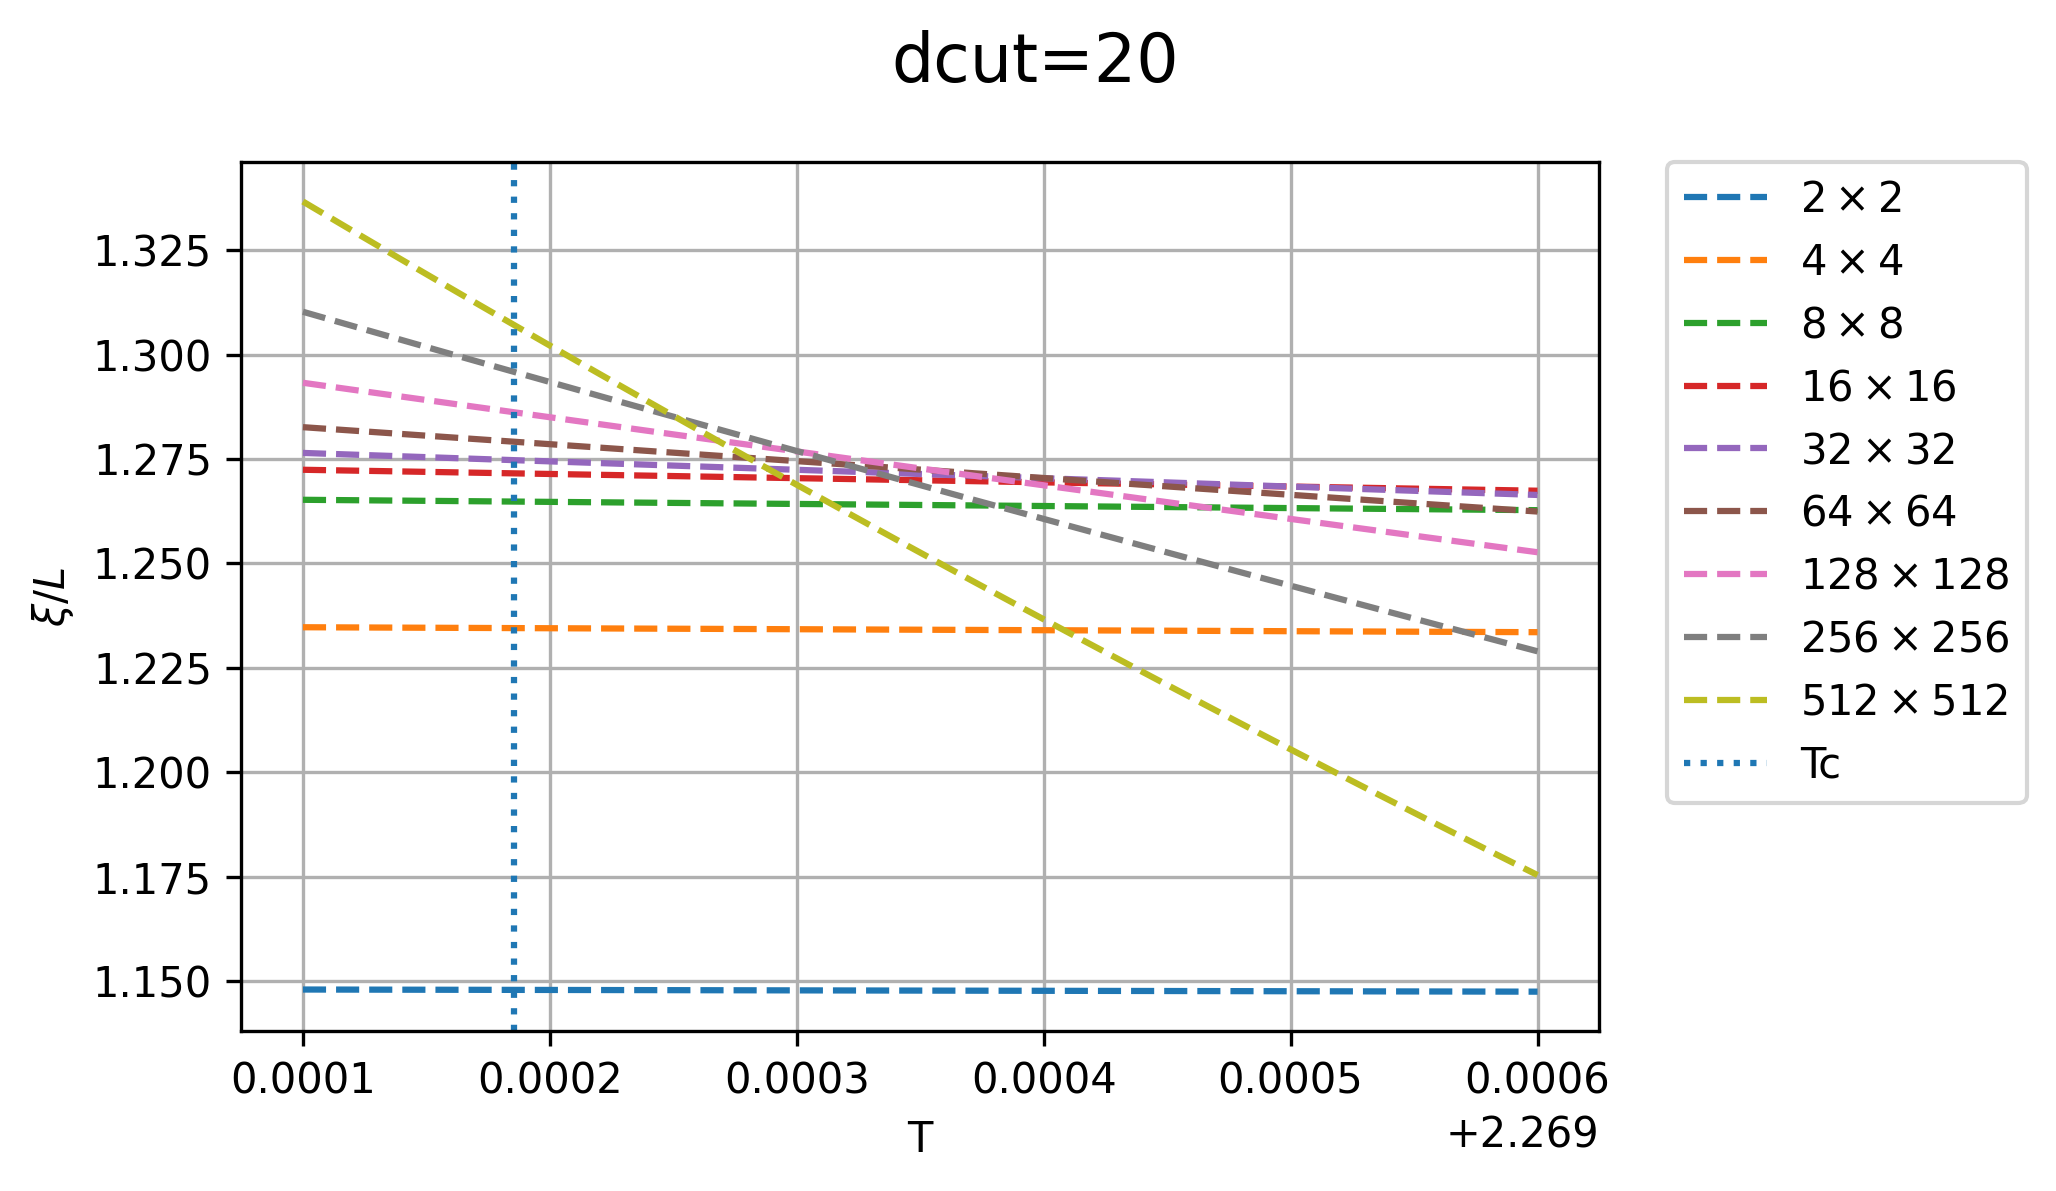

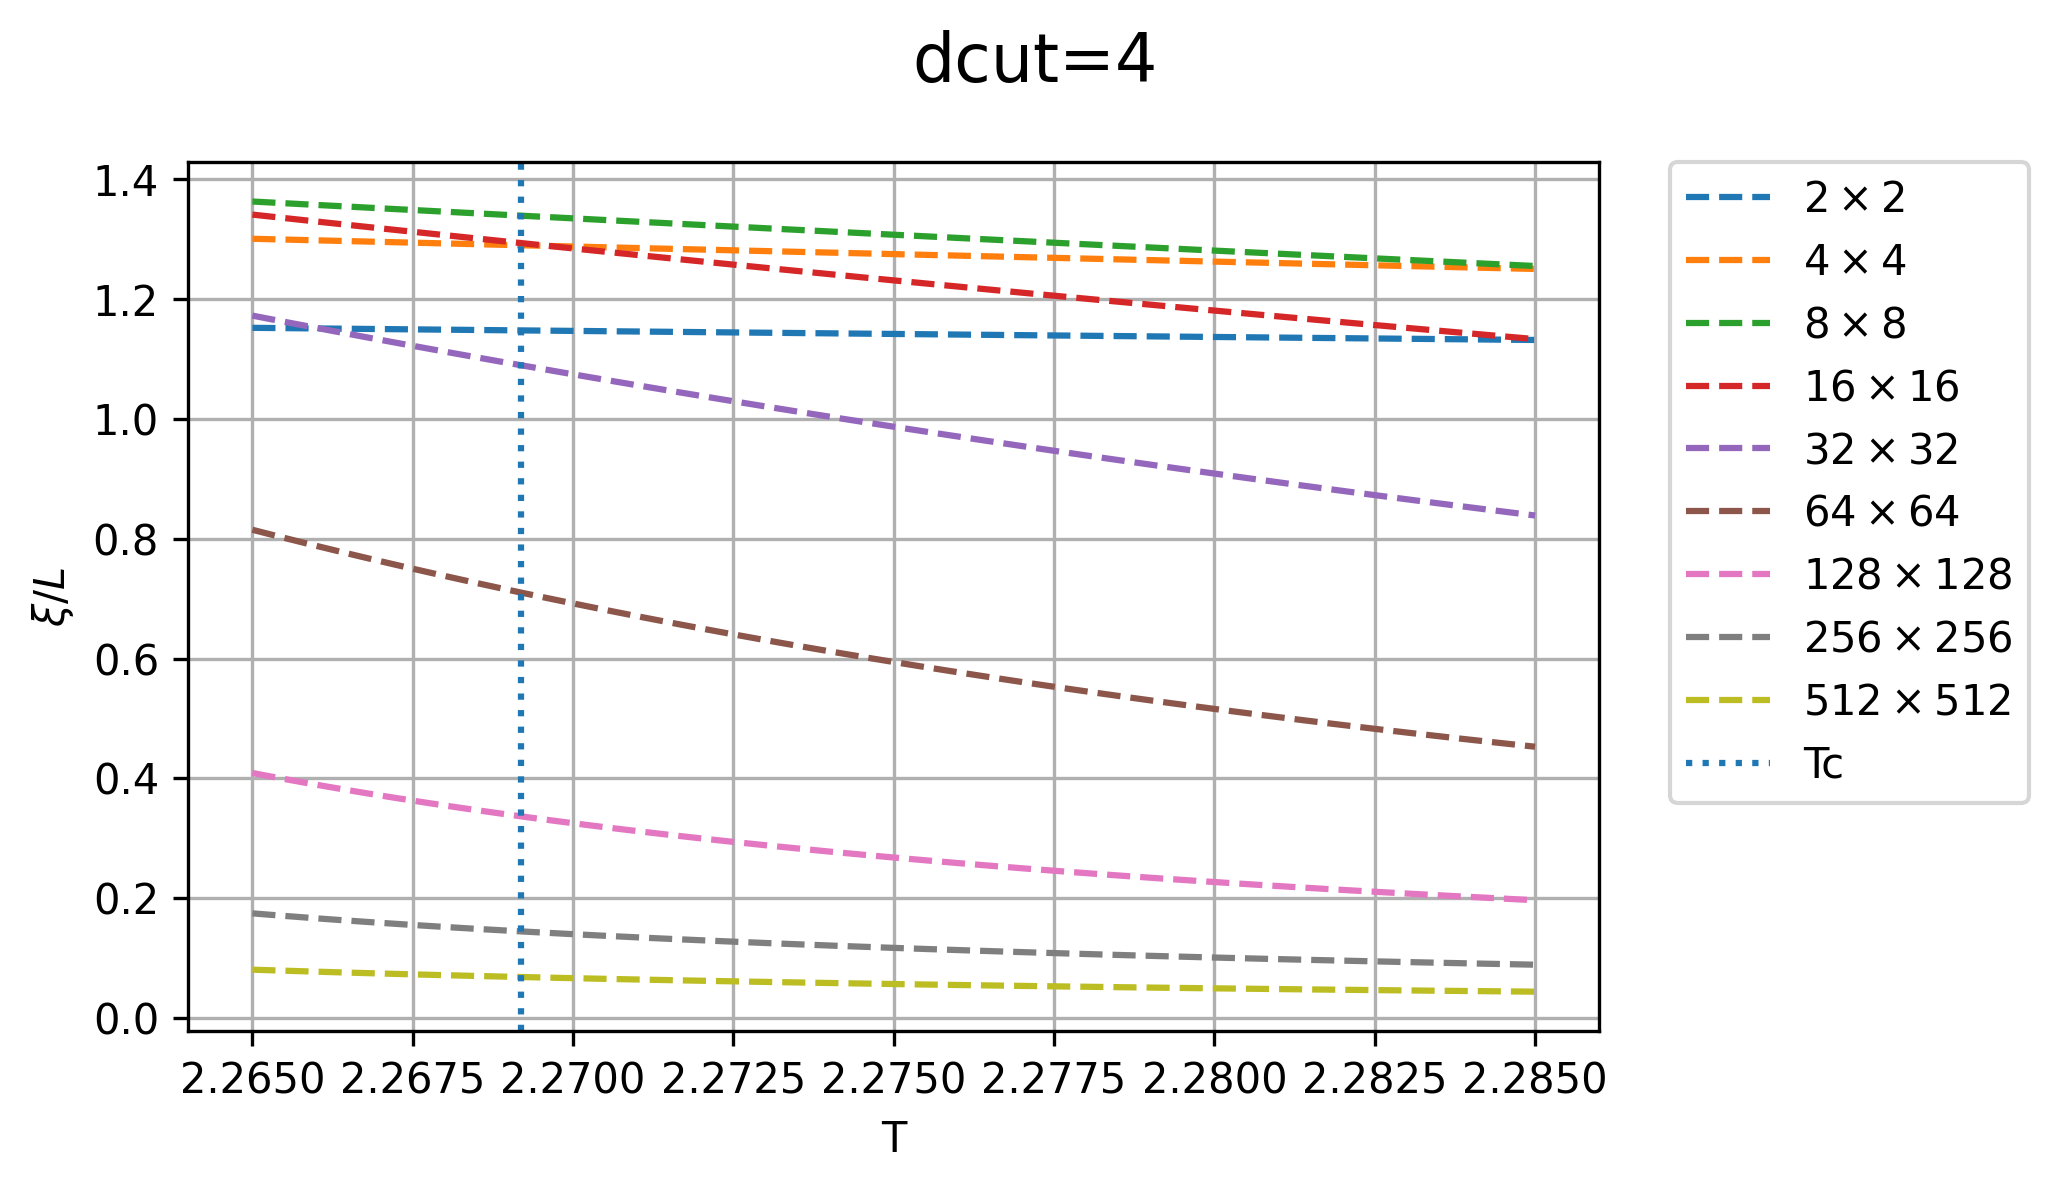

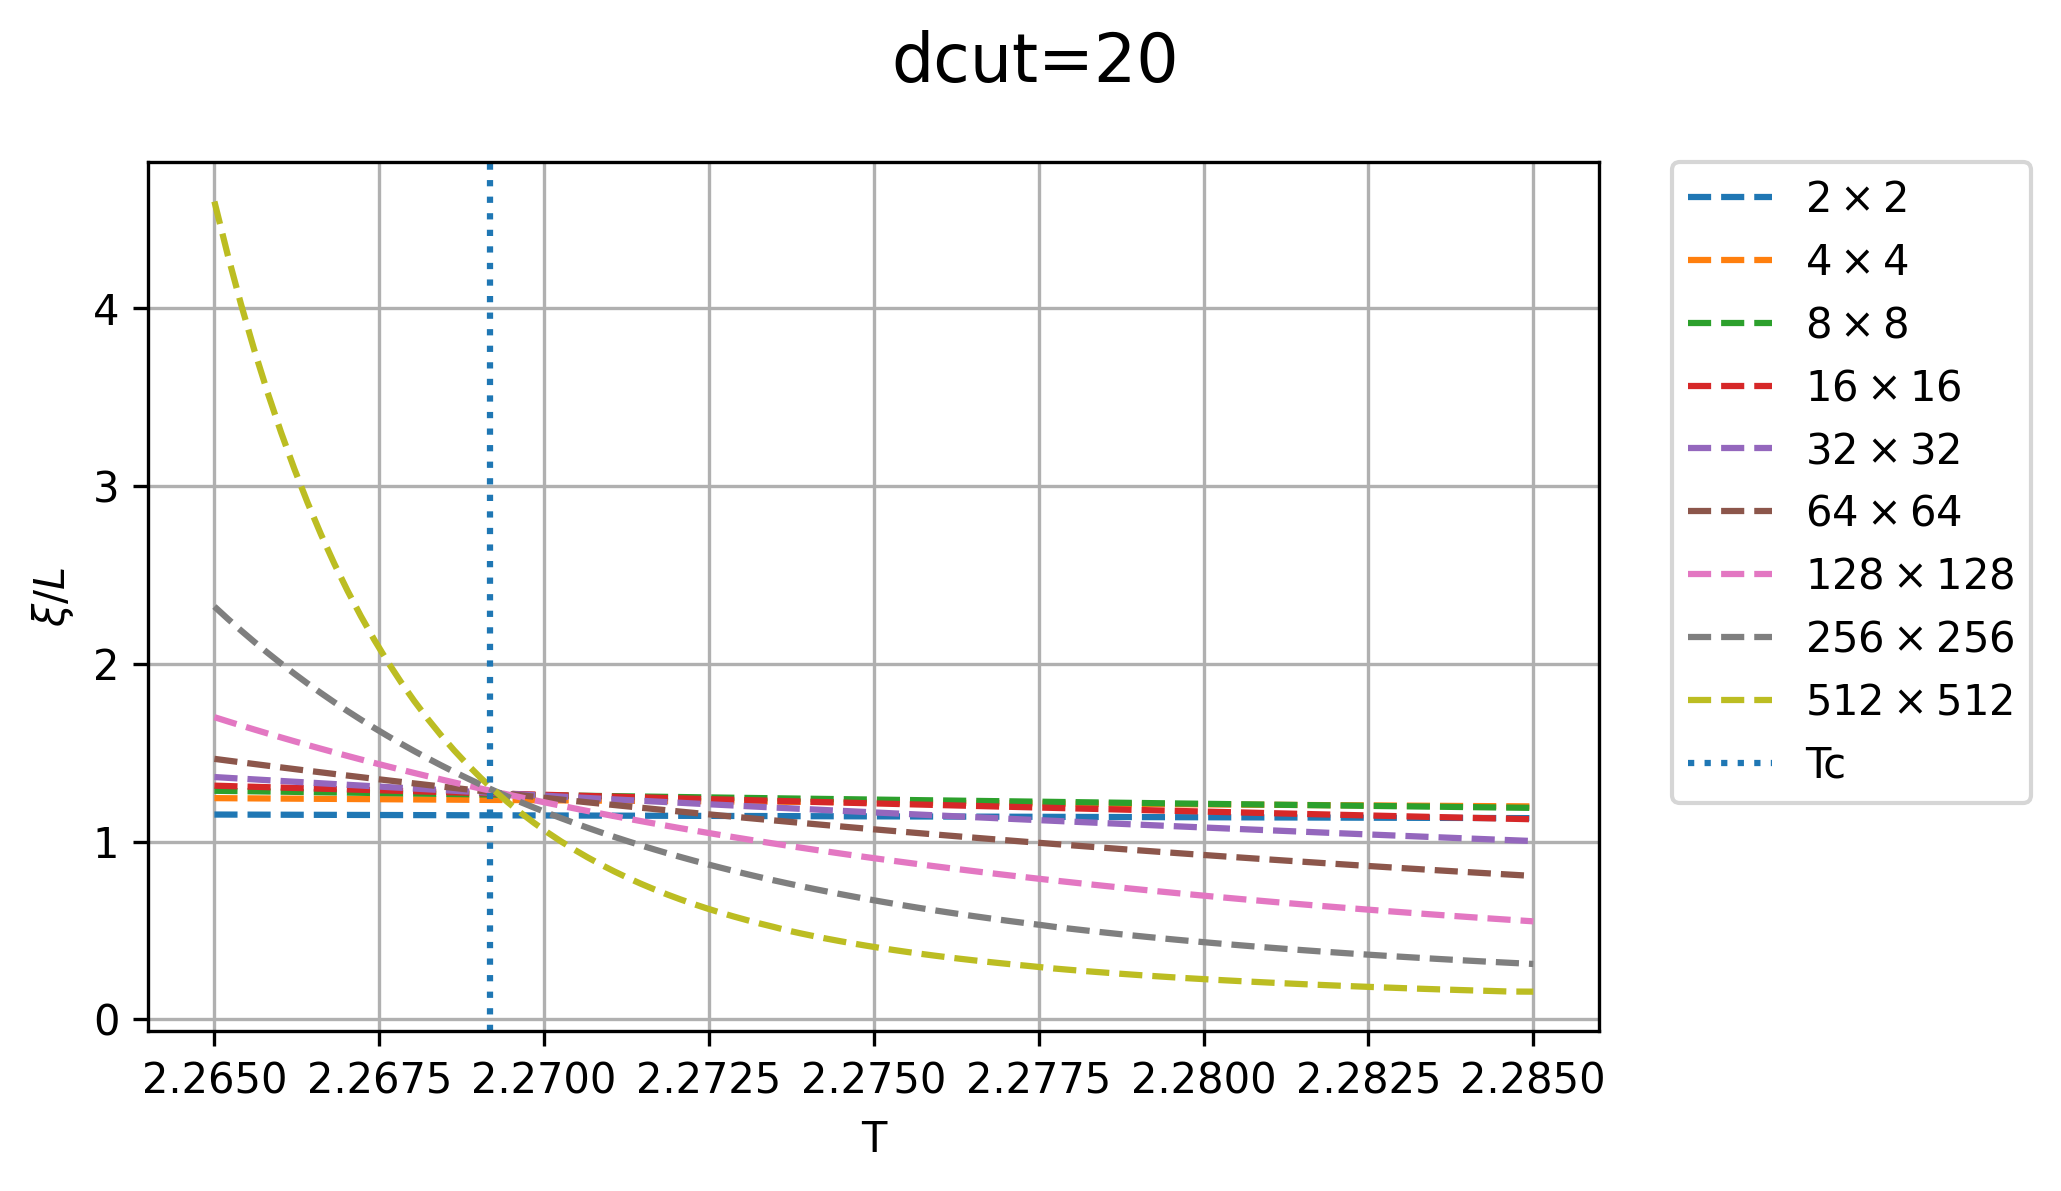

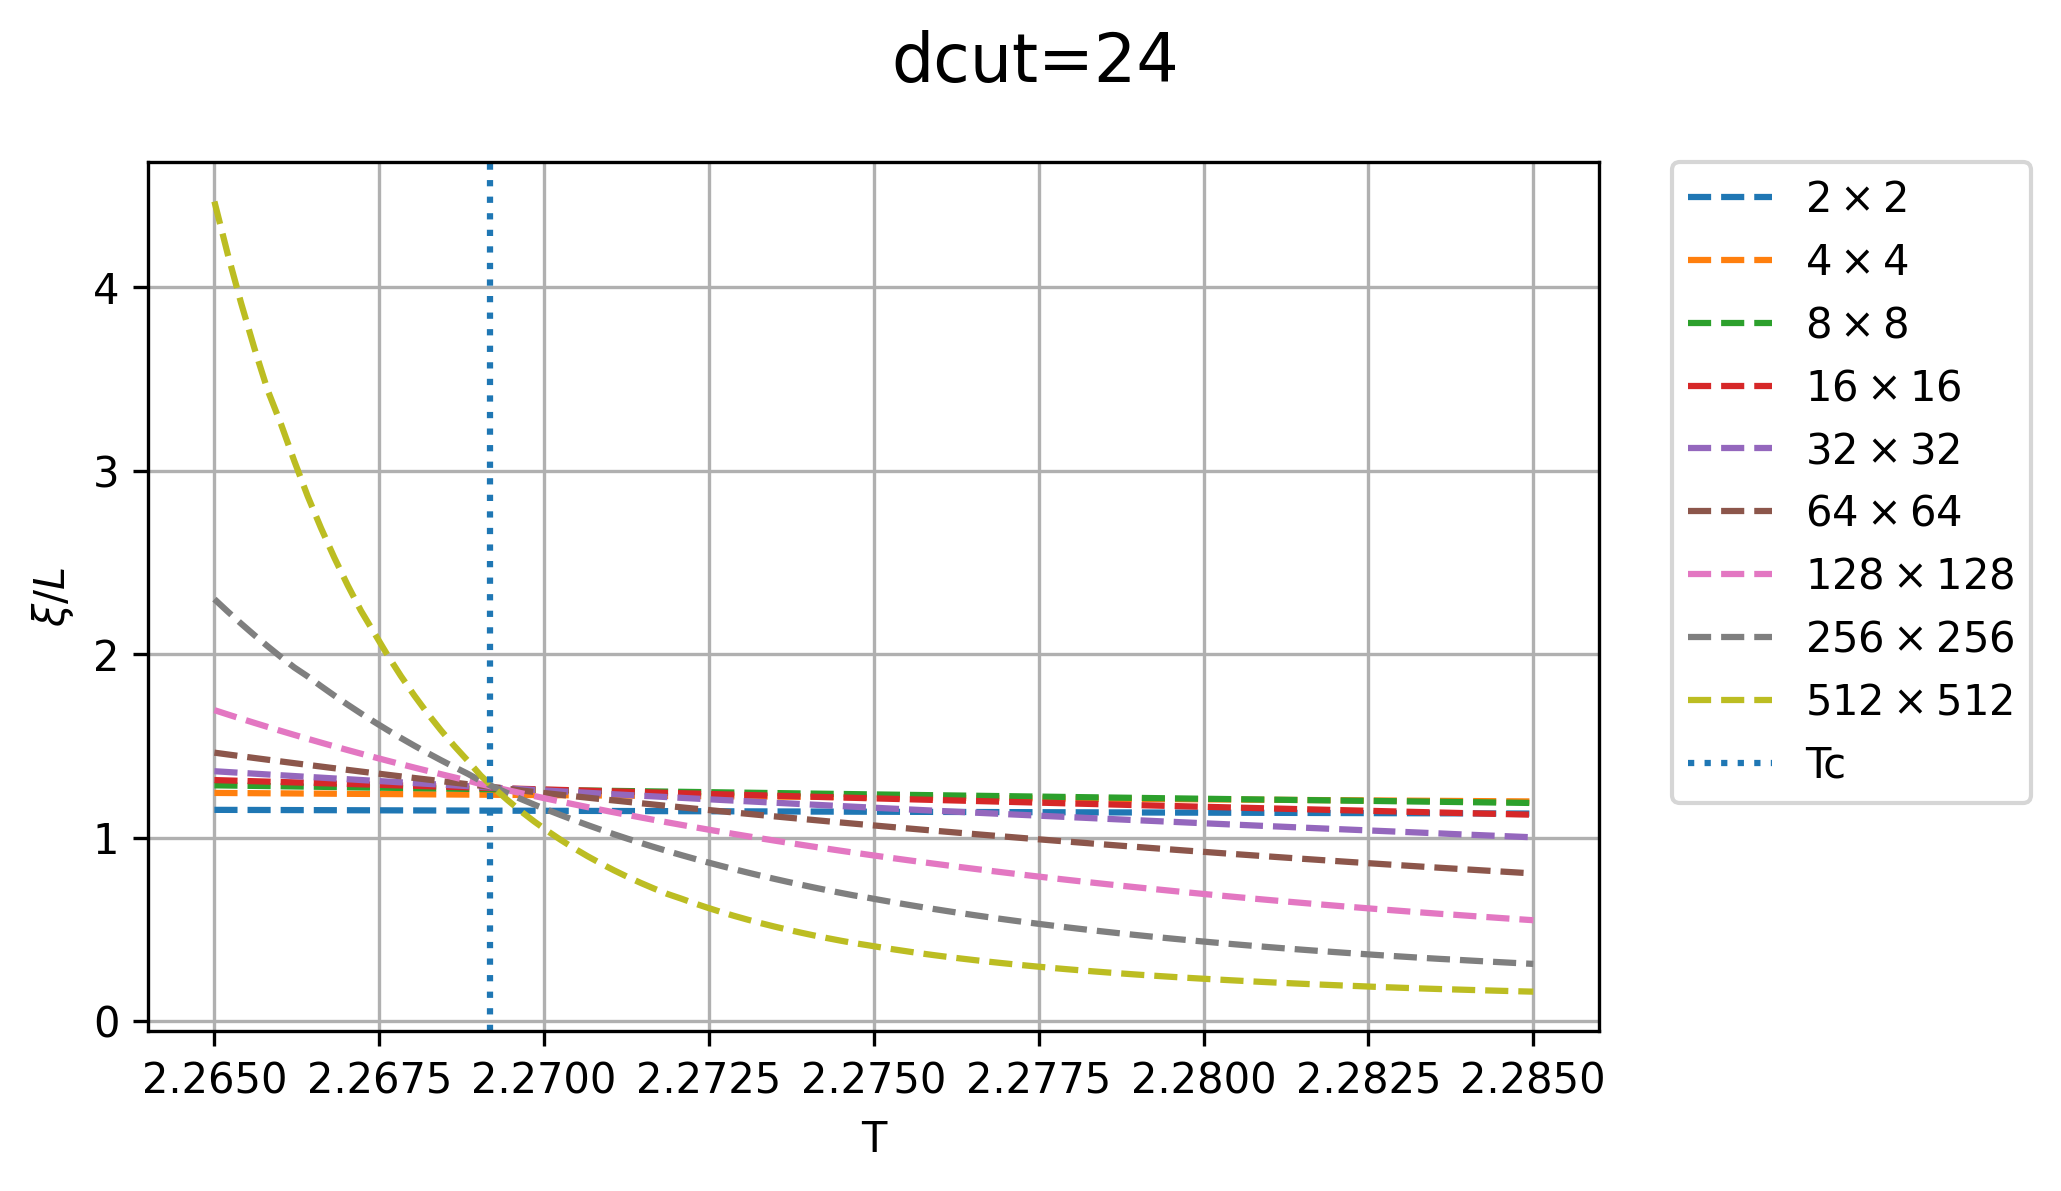

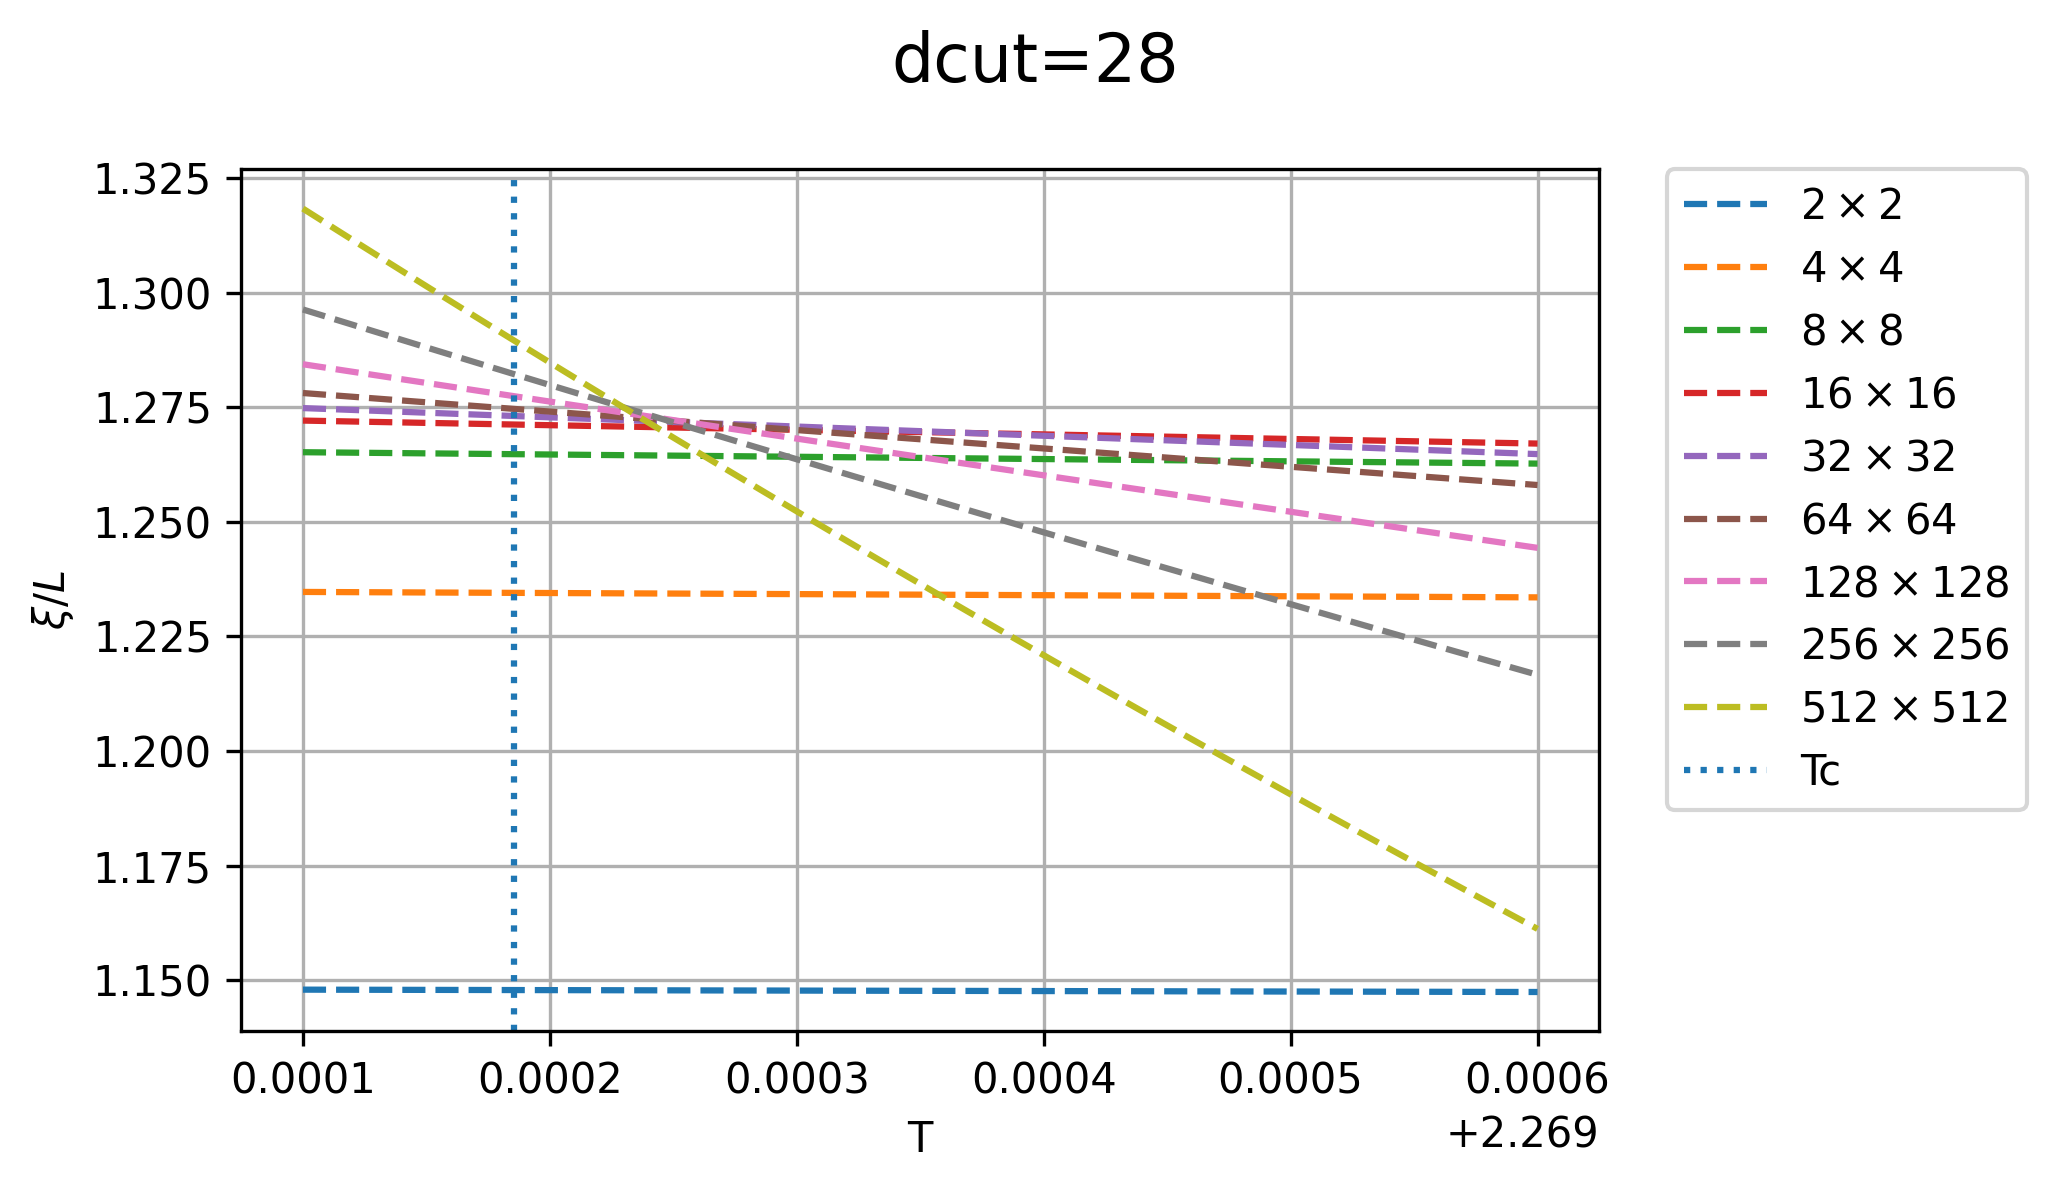

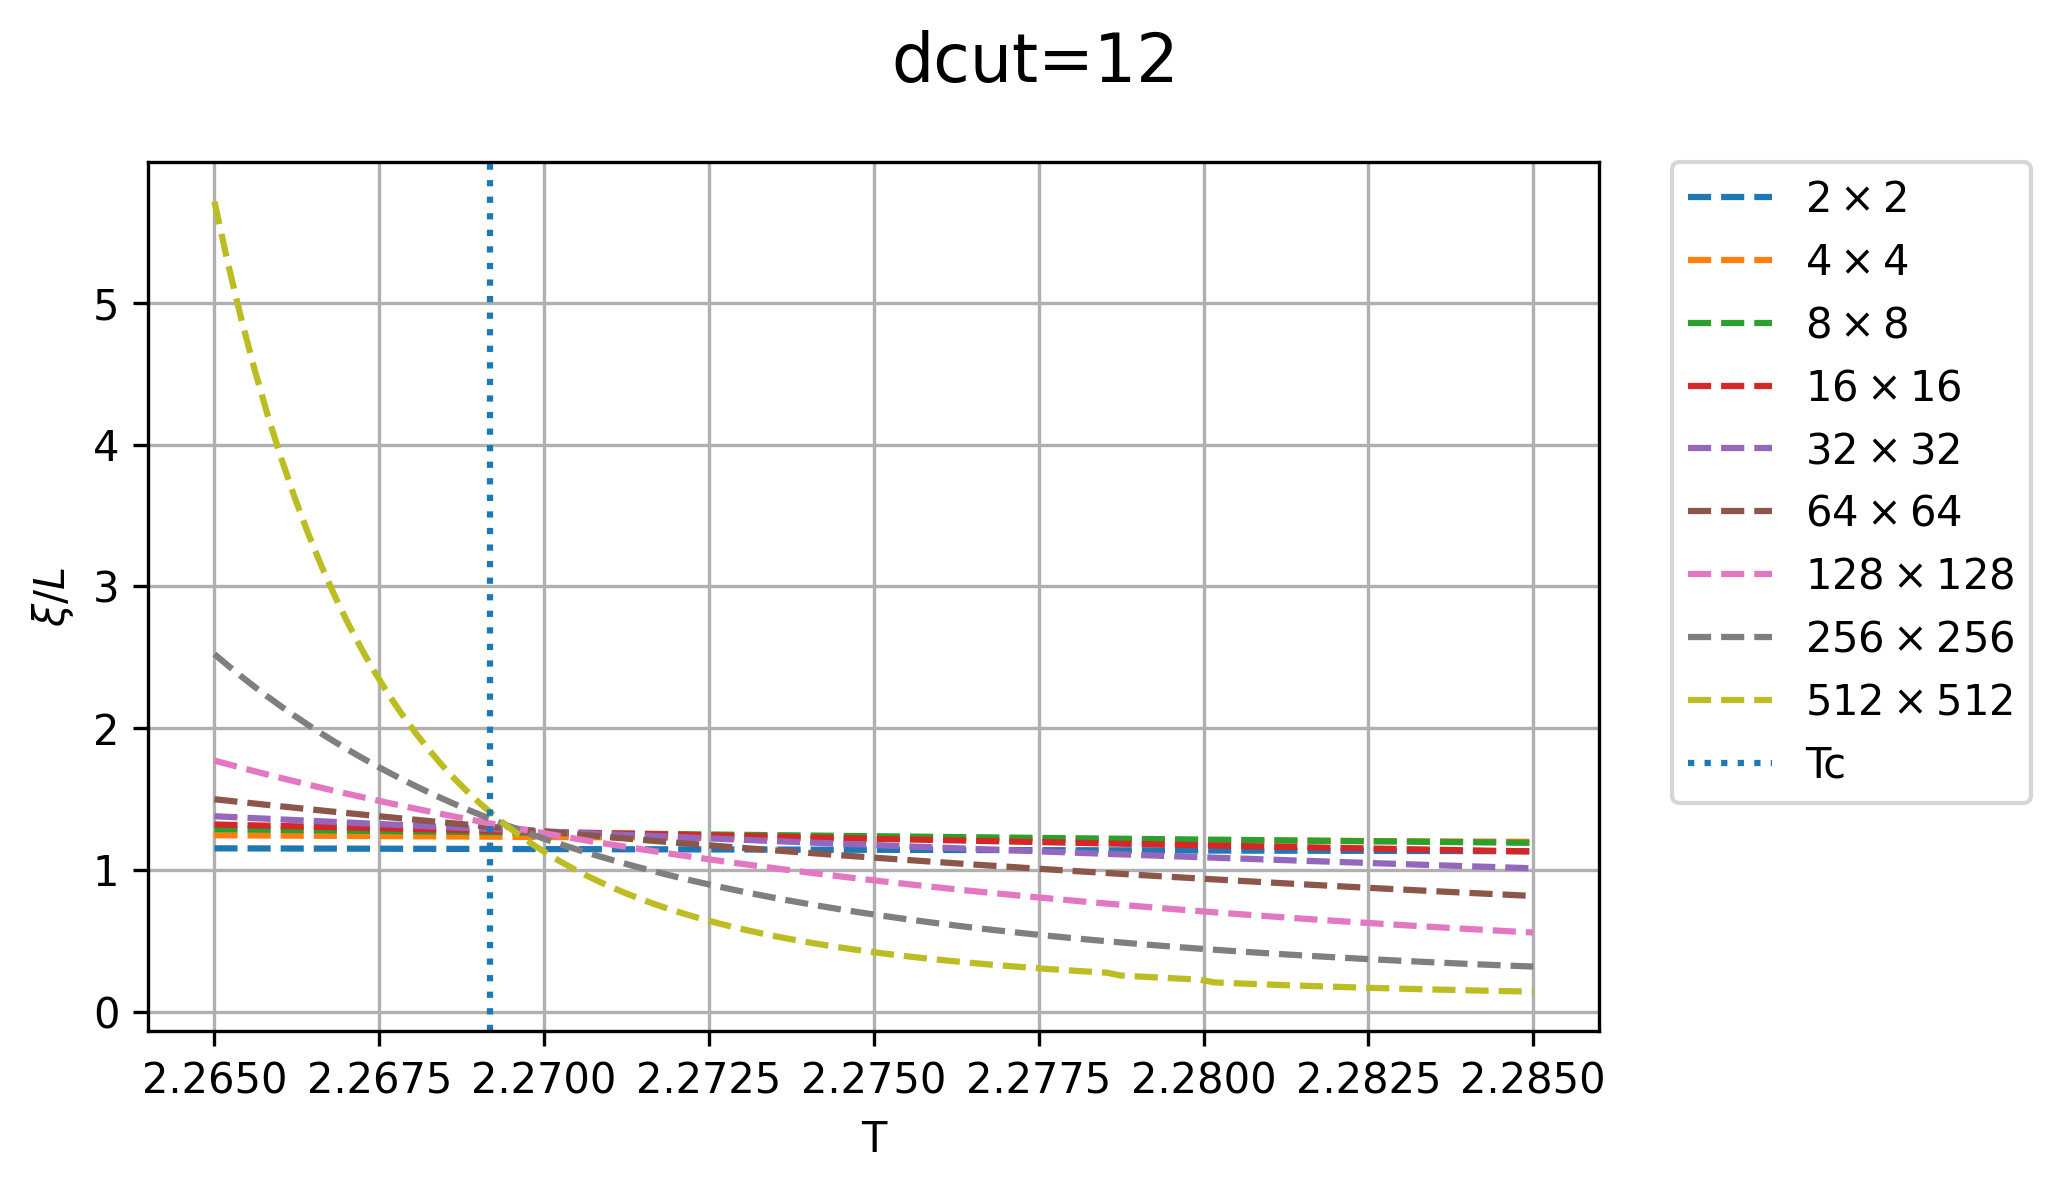

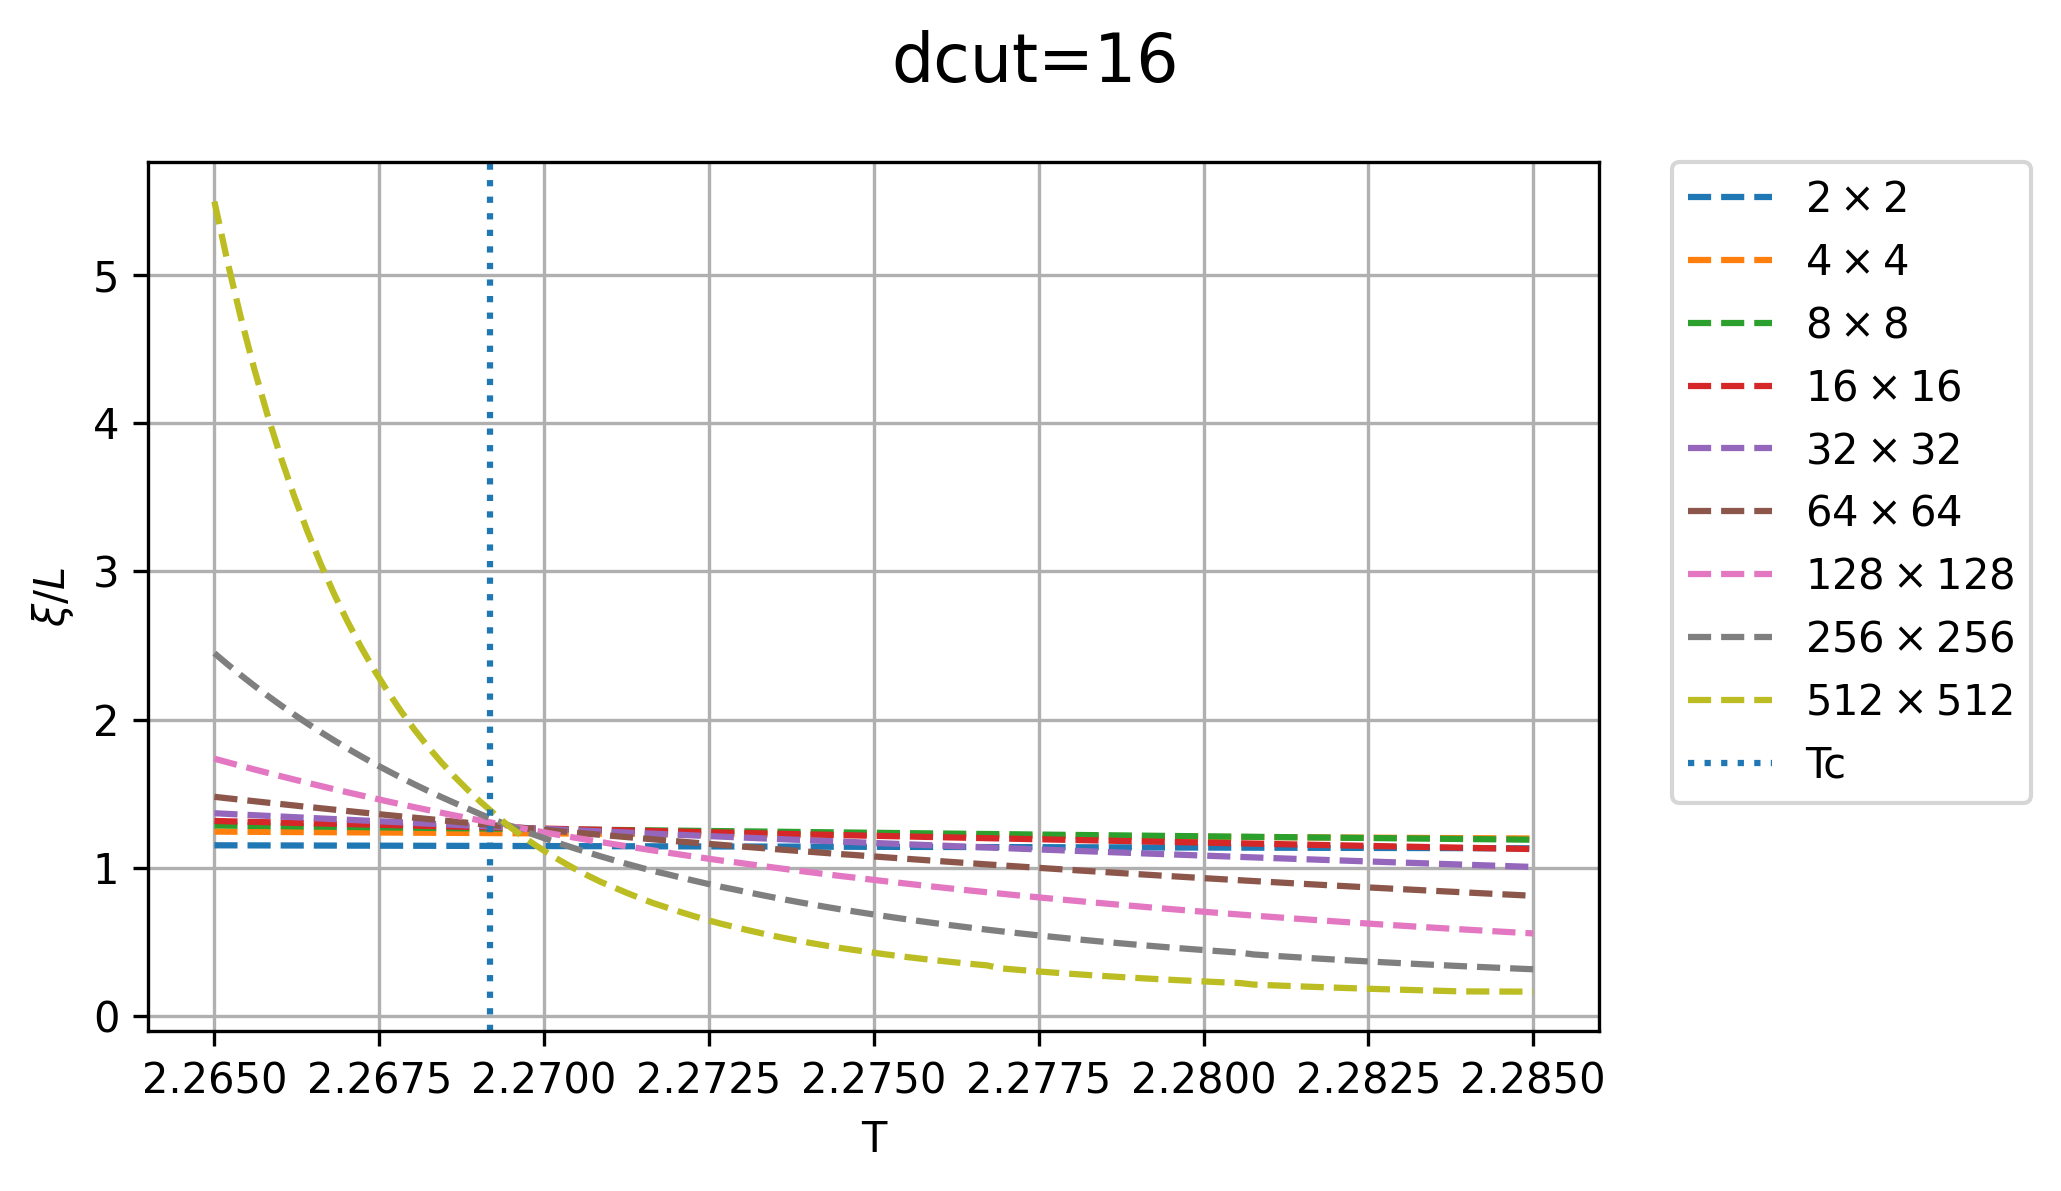

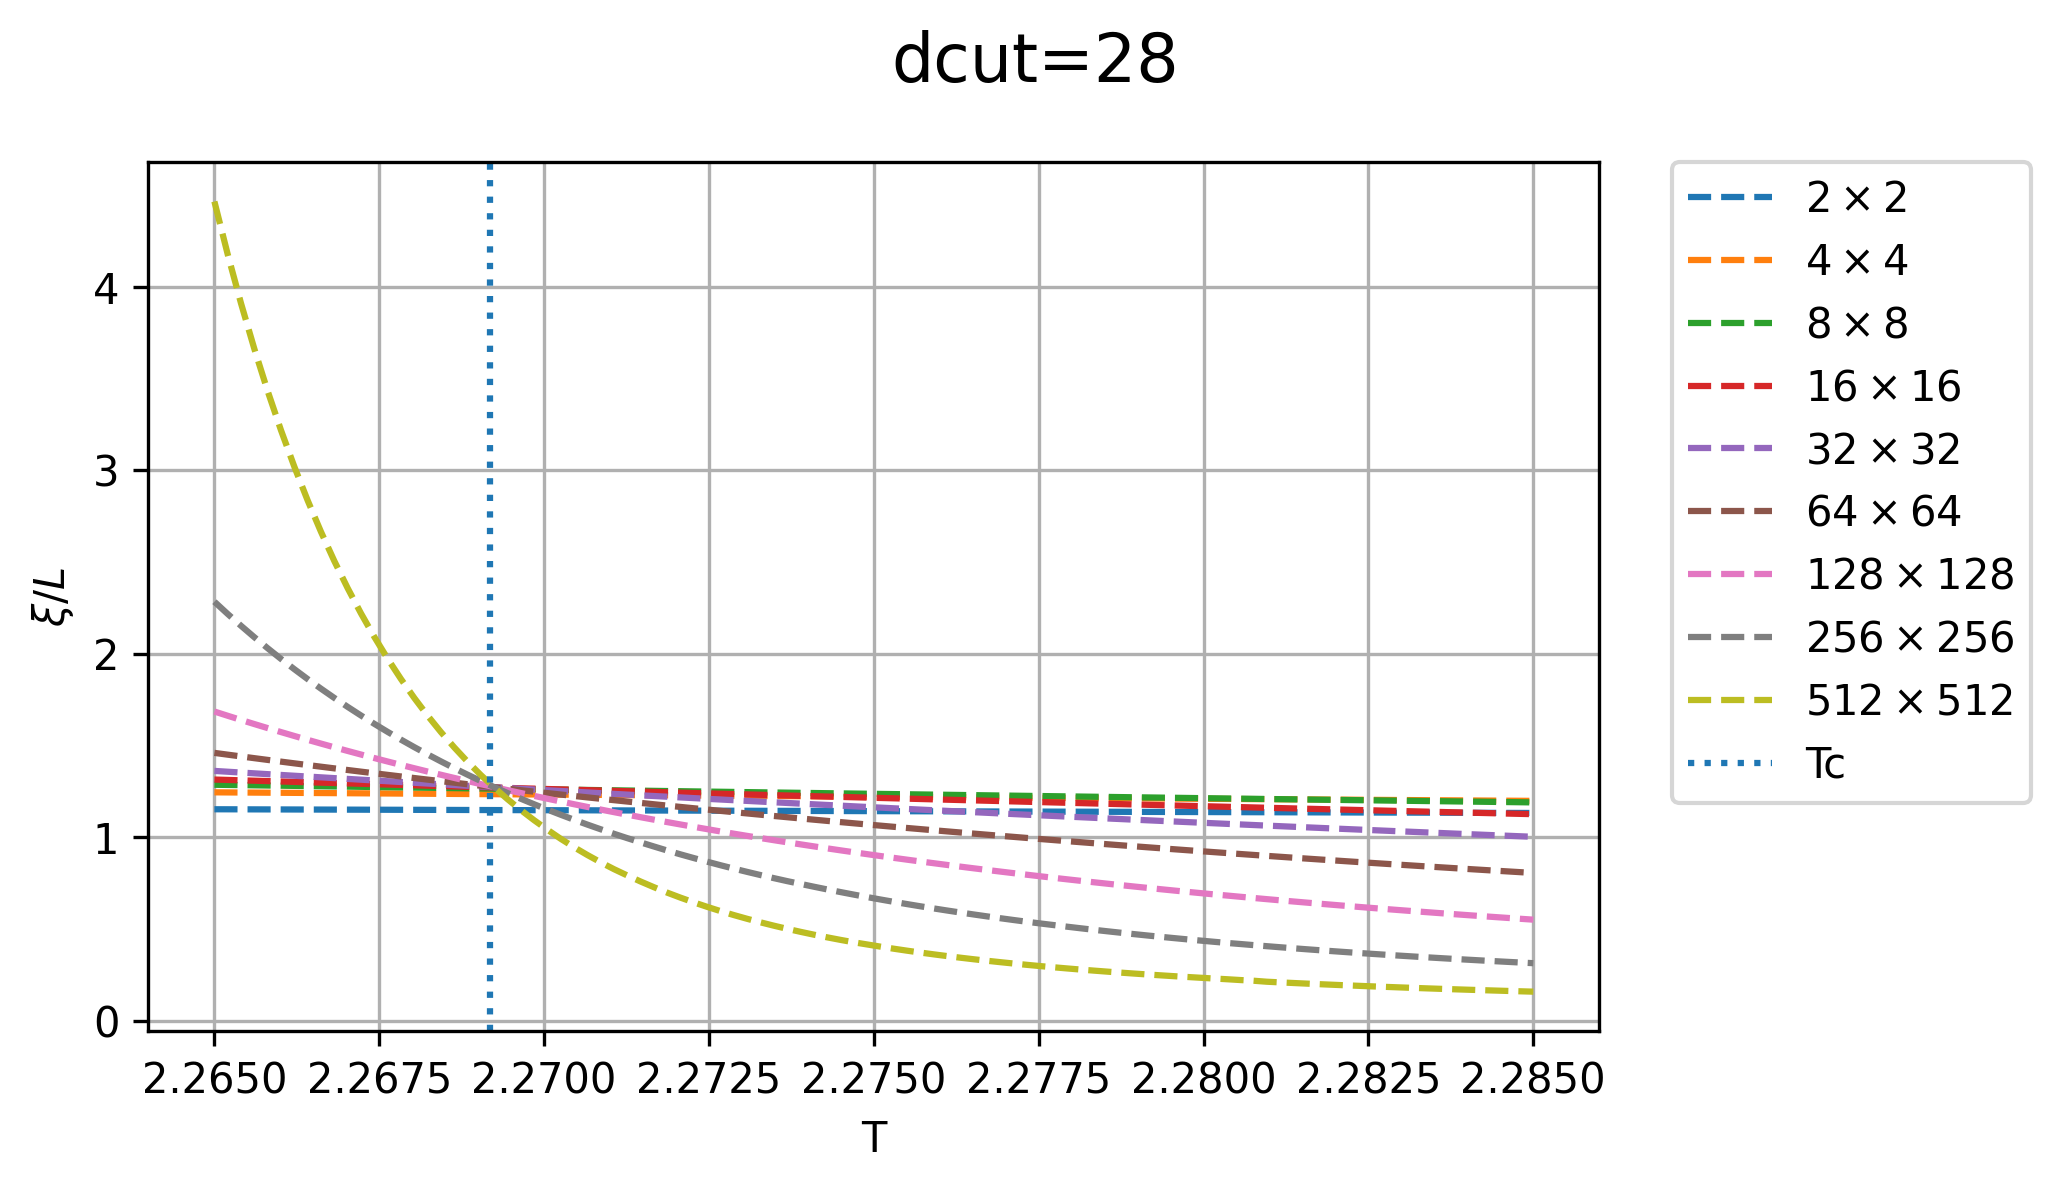

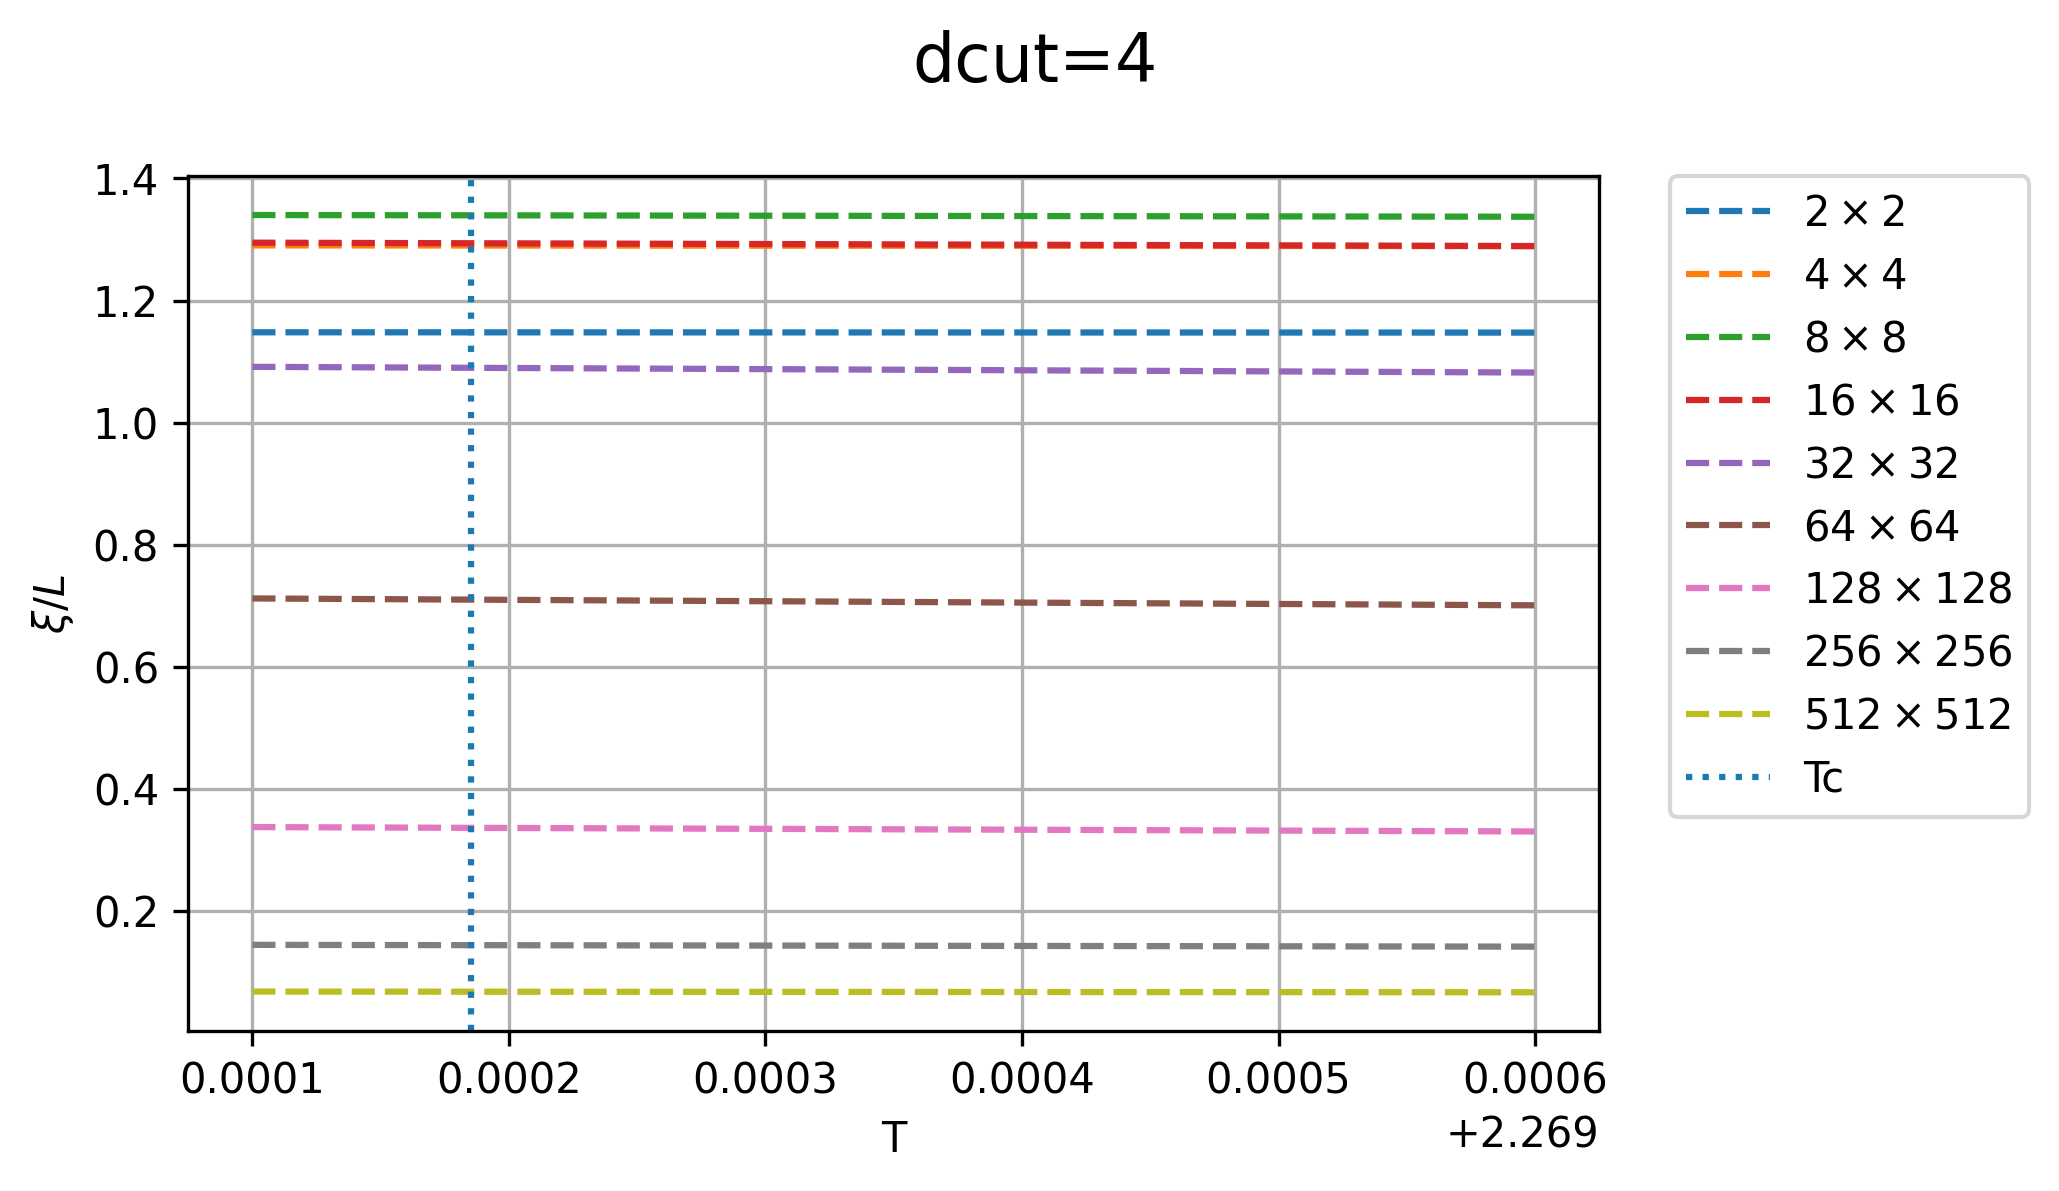

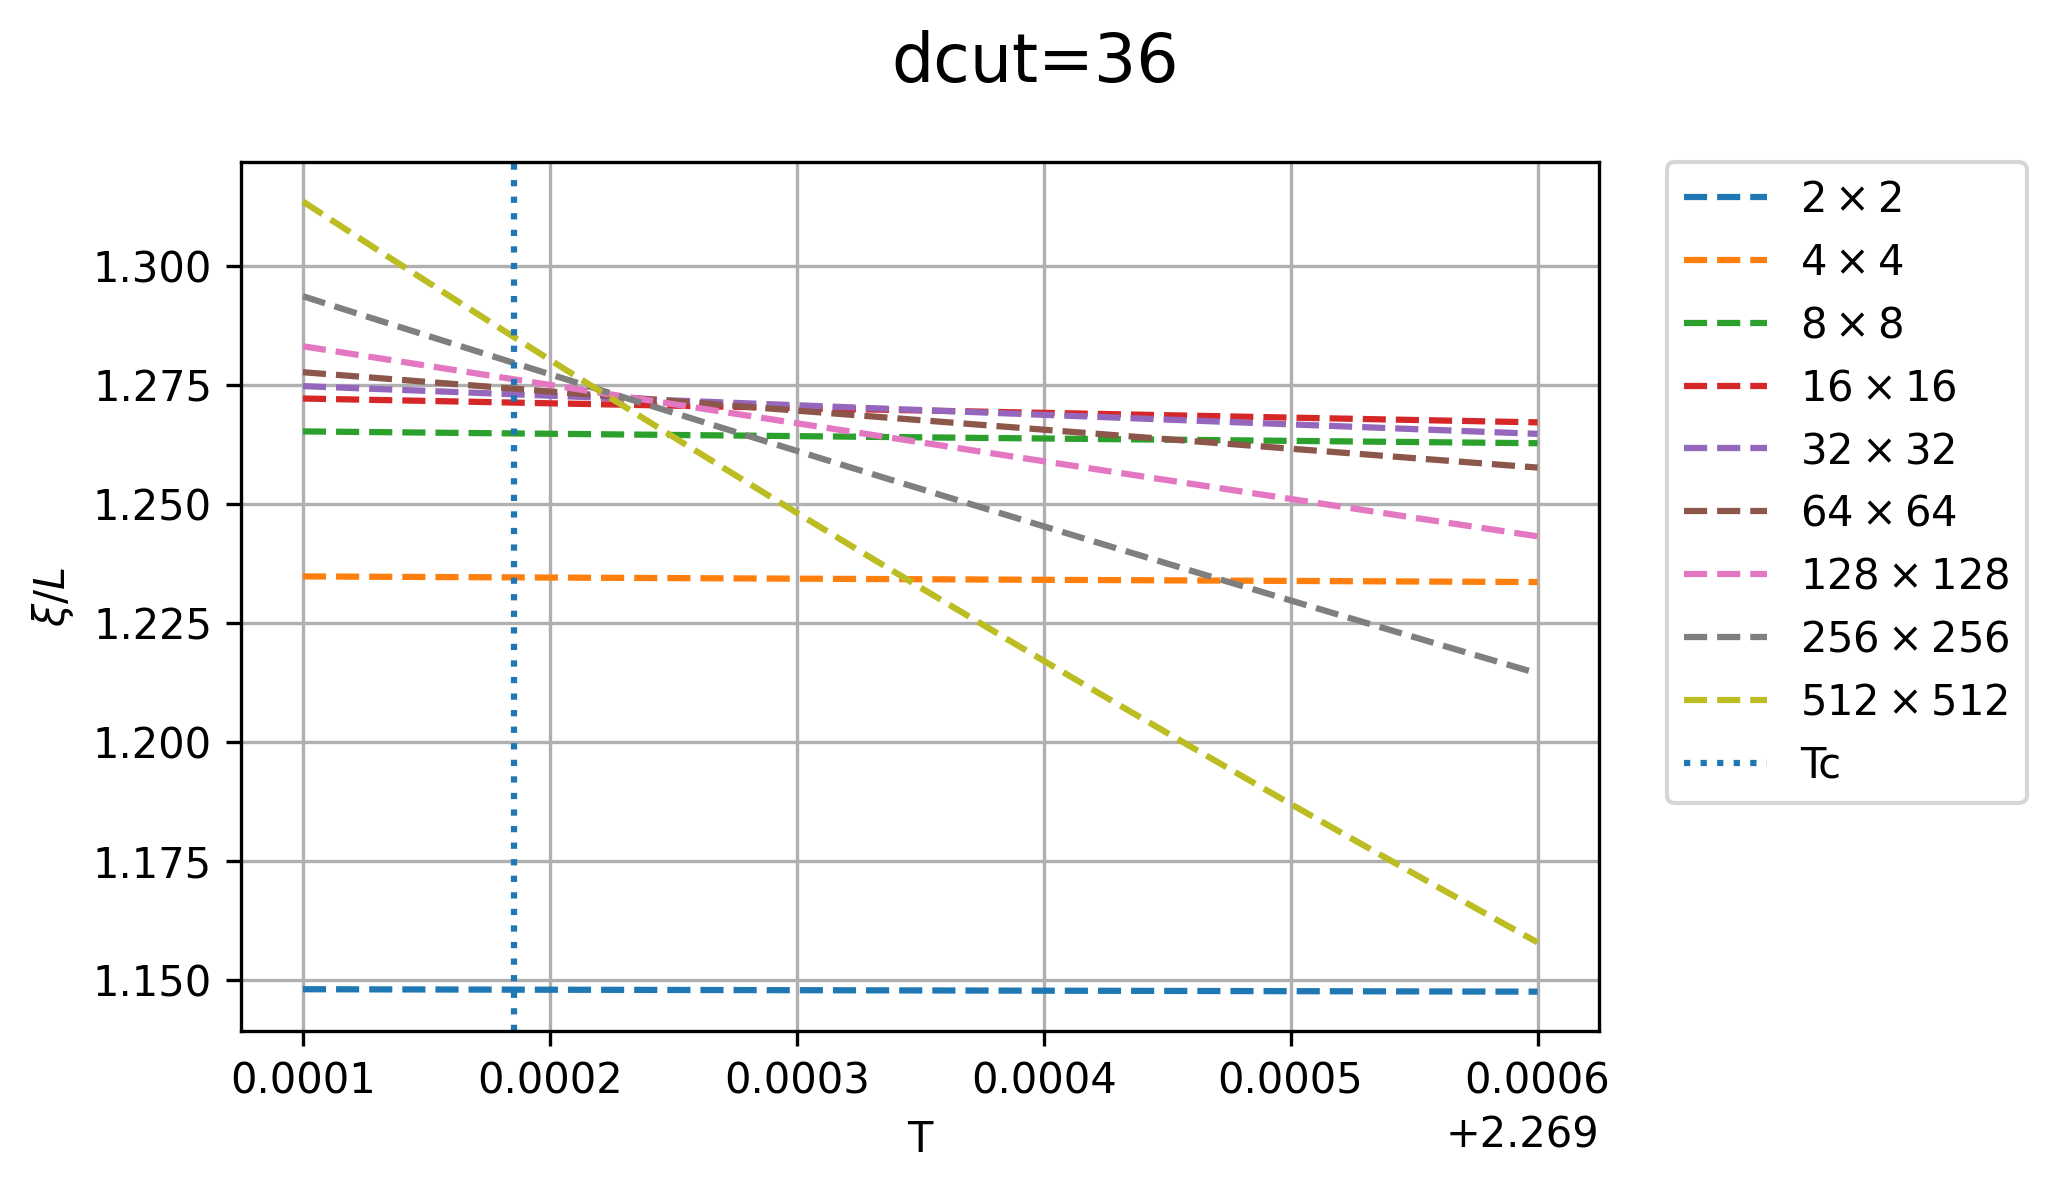

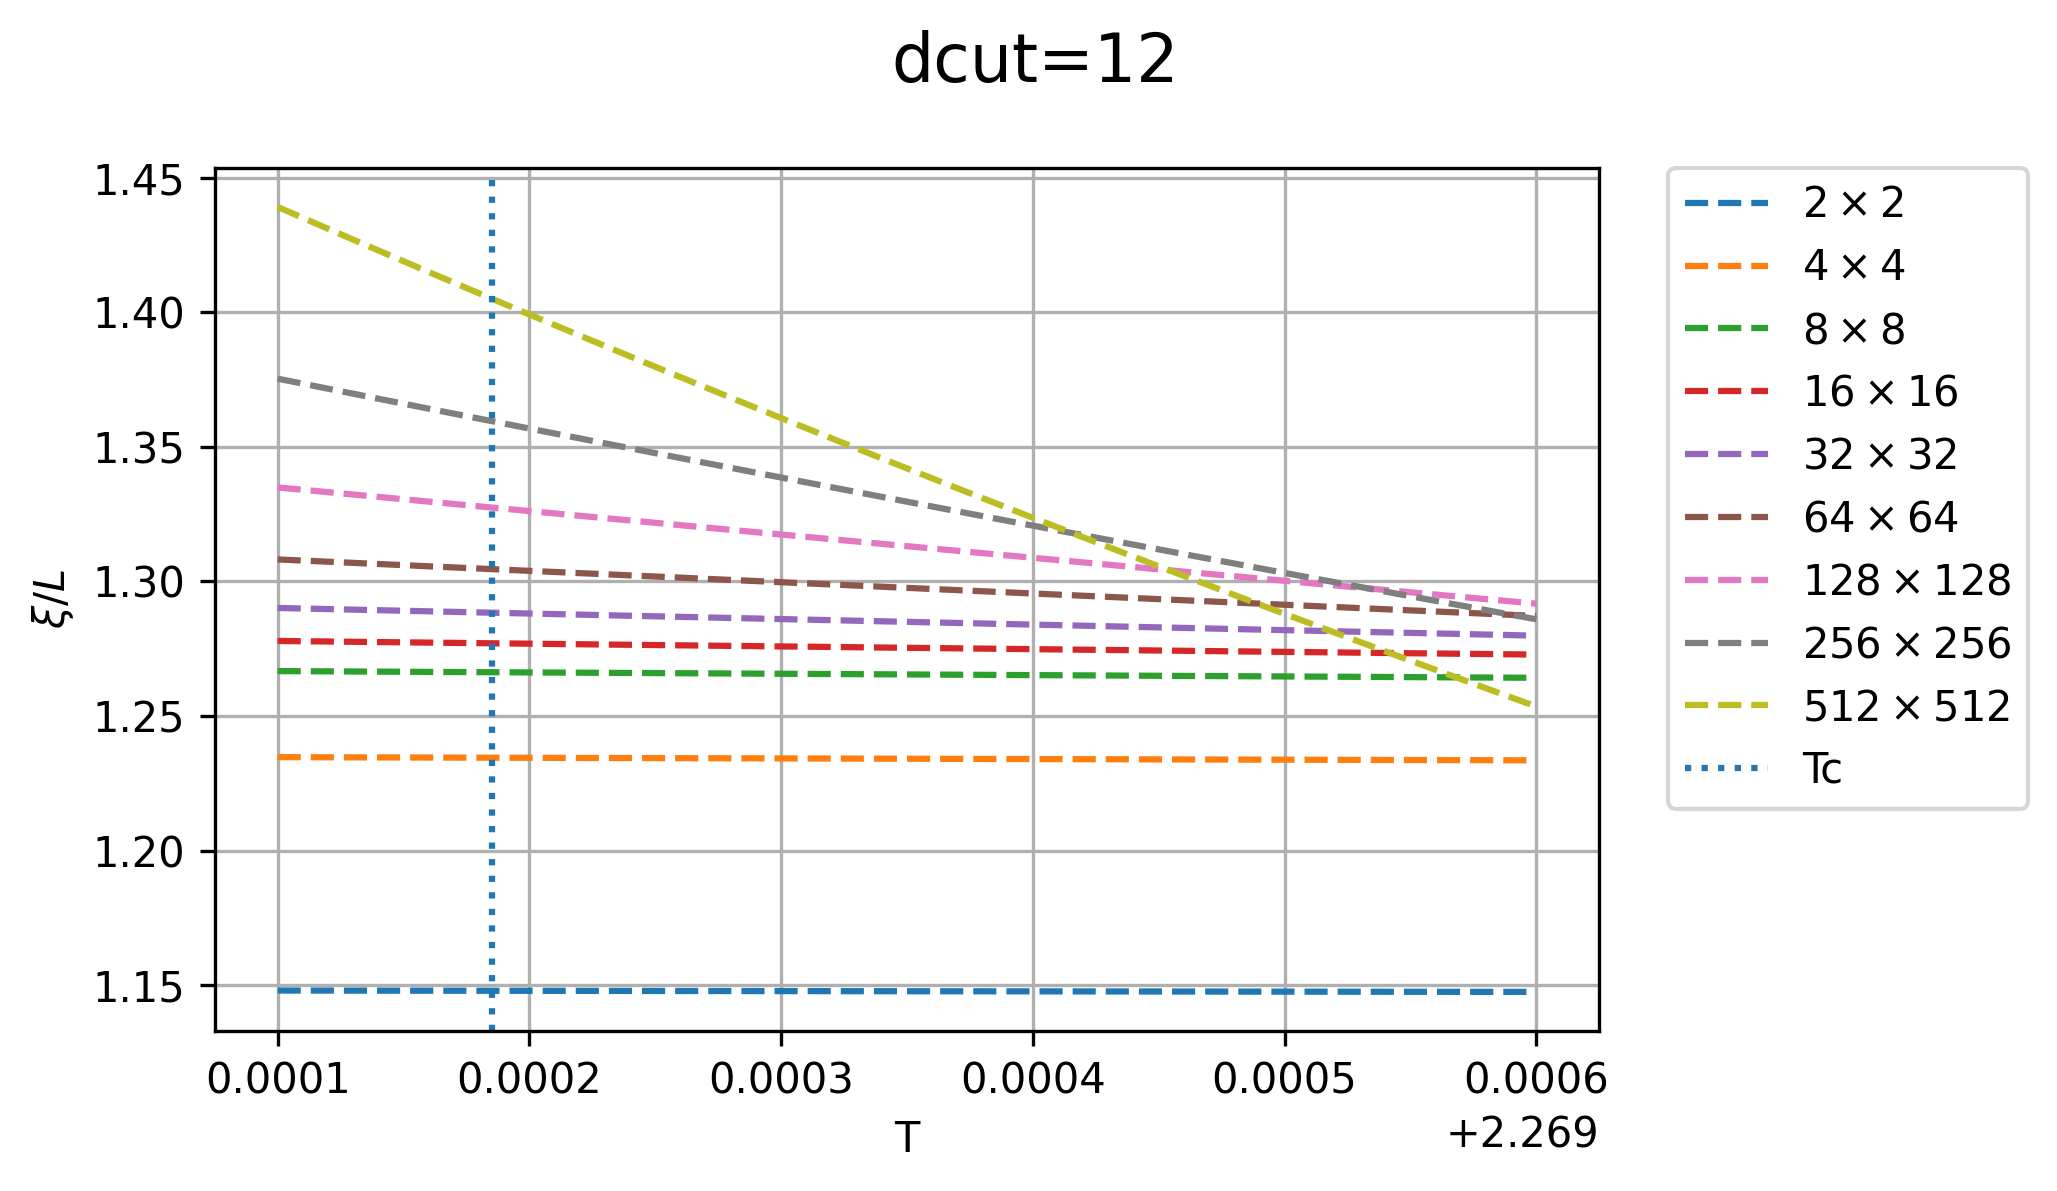

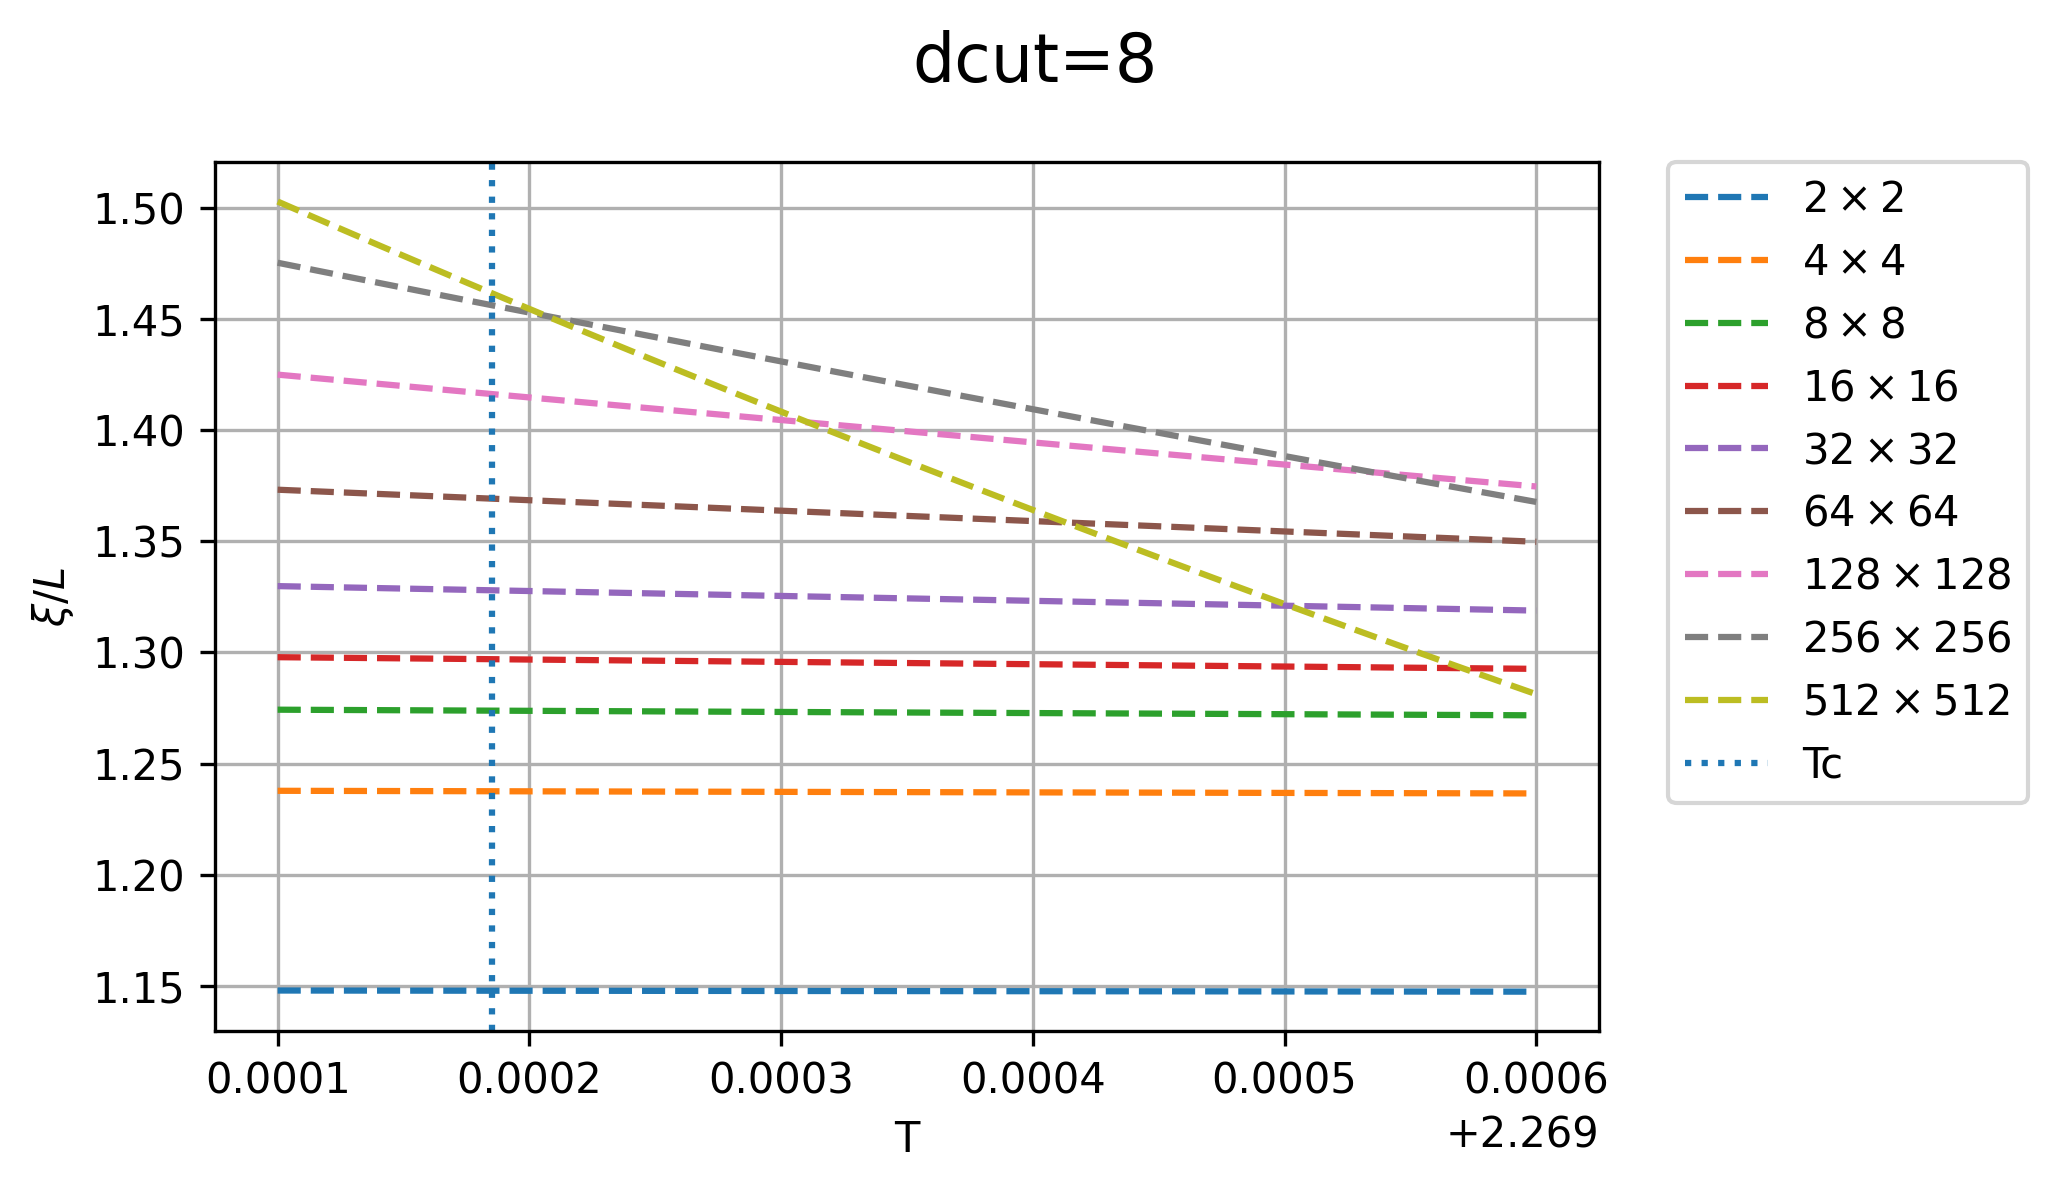

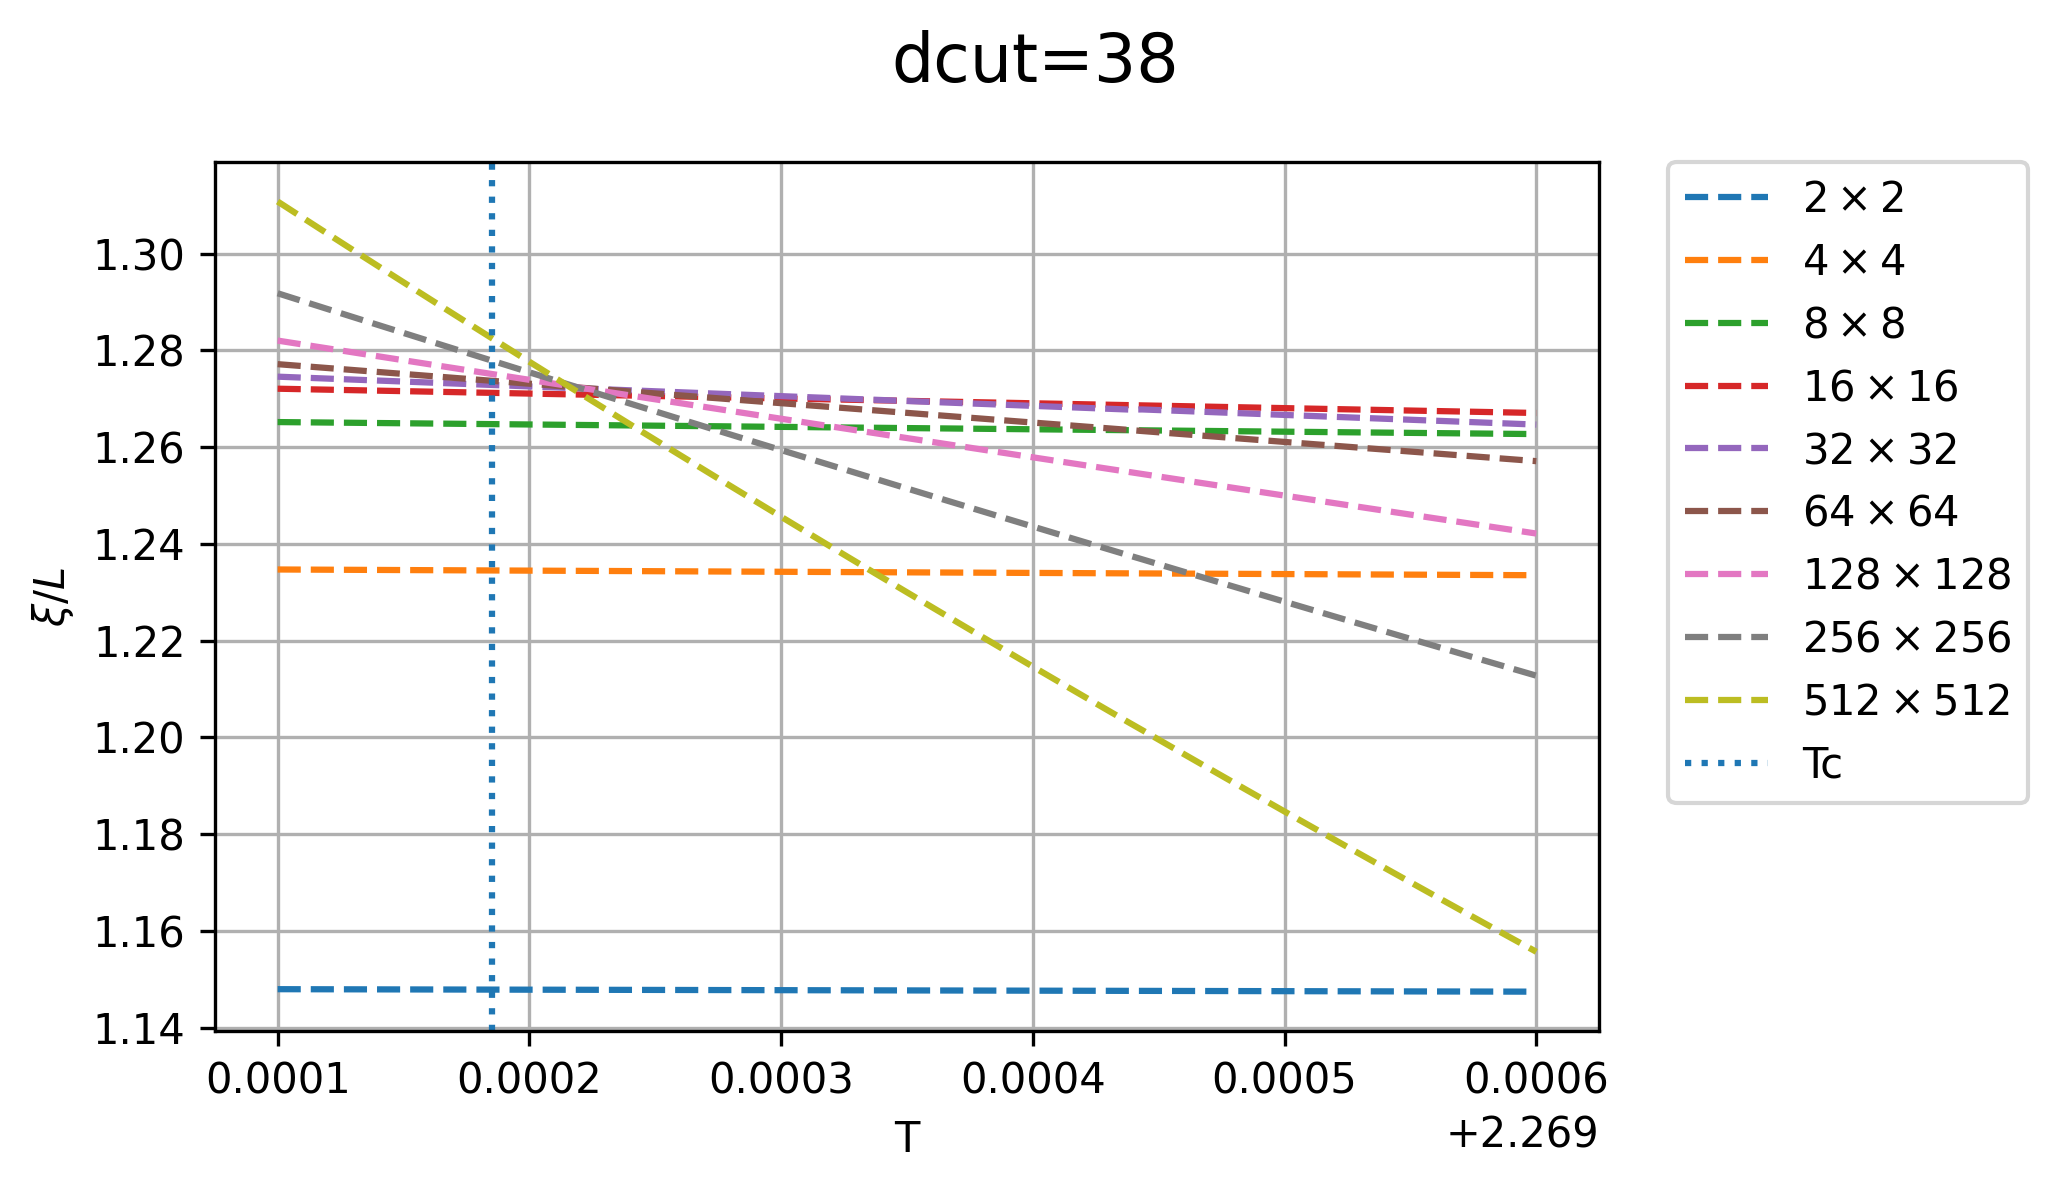

In [9]:
import os
import pickle
import glob
import matplotlib.pyplot as plt

# Pattern to find all relevant files
file_pattern = "Corr_len_results_*.pkl"

# Load all files
files = glob.glob(file_pattern)

# Iterate through files and plot data
for file in files:
    with open(file, "rb") as f:
        data = pickle.load(f)
    
    MaxL = 10
    Temp = data["Temp"]
    Corr_len = data["Corr_len"]
    Tc = data["Tc"]
    dcut = data["dcut"]
    
    # Plotting
    plt.figure(figsize=(7, 4), dpi=300)
    plt.suptitle(f'dcut={dcut}', fontsize=16)
    
    for i in range(2, MaxL + 1):
        plt.plot(Temp, Corr_len[i], '--', label=f'${2**(i-1)}\\times{2**(i-1)}$')
    
    plt.axvline(x=Tc, ls=':', label='Tc')
    plt.xlabel('T')
    plt.ylabel(r'$\xi/L$')
    plt.grid()
    plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
    plt.tight_layout()
    plt.show()


交點溫度 T_xi*: 2.2693
L_y=32 的斜率: -10.0247
L_y=64 的斜率: -20.0674
估算的臨界指數 ν: 0.9987


/tmp/ipykernel_3759939/59813510.py:20: DeprecationWarning: scipy.misc.derivative is deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. You may consider using findiff: https://github.com/maroba/findiff or numdifftools: https://github.com/pbrod/numdifftools
  slope_32 = derivative(interp_32, crossing_temp, dx=1e-5)
/tmp/ipykernel_3759939/59813510.py:21: DeprecationWarning: scipy.misc.derivative is deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. You may consider using findiff: https://github.com/maroba/findiff or numdifftools: https://github.com/pbrod/numdifftools
  slope_64 = derivative(interp_64, crossing_temp, dx=1e-5)


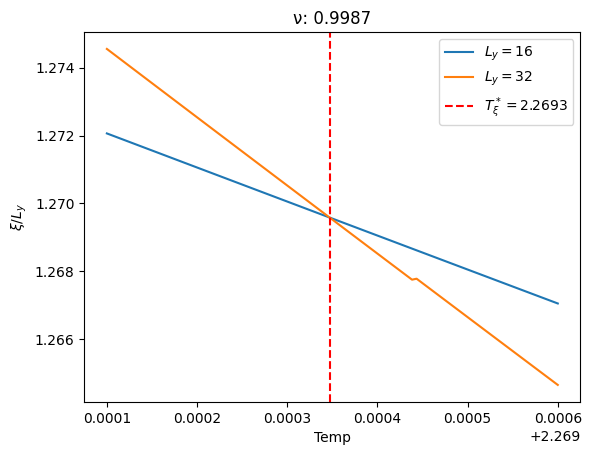

交點溫度 T_xi*: 2.2692
L_y=32 的斜率: -20.1192
L_y=64 的斜率: -40.2614
估算的臨界指數 ν: 0.9992


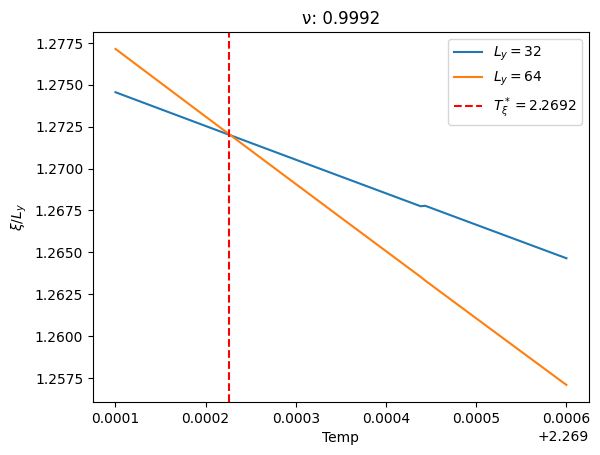

交點溫度 T_xi*: 2.2692
L_y=32 的斜率: -40.2699
L_y=64 的斜率: -80.6073
估算的臨界指數 ν: 0.9988


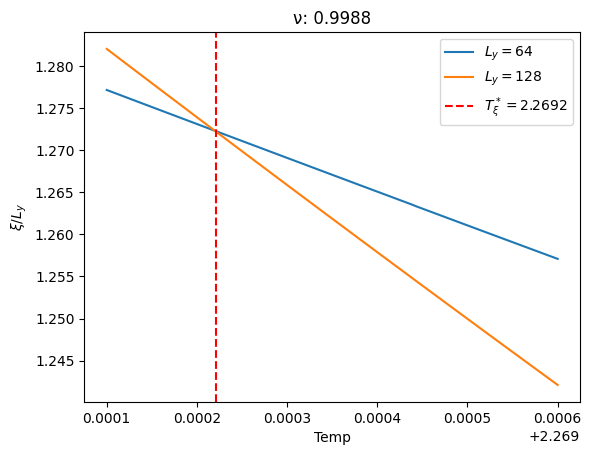

交點溫度 T_xi*: 2.2692
L_y=32 的斜率: -80.6073
L_y=64 的斜率: -161.4562
估算的臨界指數 ν: 0.9978


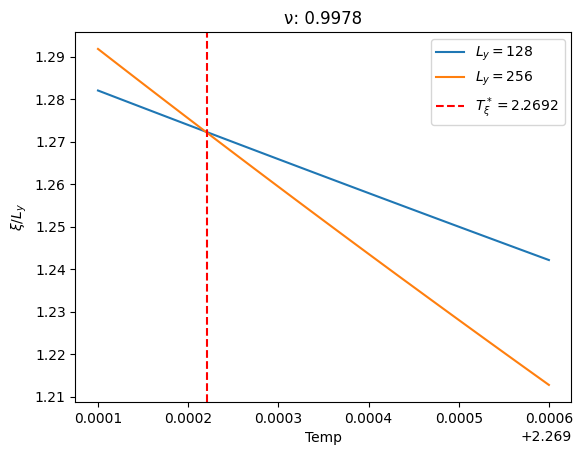

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.misc import derivative

for i in range(5, 9):
    # 範例數據：假設 T 和 ξ/L_y
    T = Temp
    xi_Ly_32 = np.array(Corr_len[i])
    xi_Ly_64 = np.array(Corr_len[i+1])

    # 1. 找交點溫度 T_xi*：
    interp_32 = interp1d(T, xi_Ly_32, kind='cubic')
    interp_64 = interp1d(T, xi_Ly_64, kind='cubic')
    crossing_temp = T[np.argmin(np.abs(xi_Ly_32 - xi_Ly_64))]

    print(f"交點溫度 T_xi*: {crossing_temp:.4f}")

    # 2. 計算斜率 s_{xi/L_y} 在 T_xi* 附近
    slope_32 = derivative(interp_32, crossing_temp, dx=1e-5)
    slope_64 = derivative(interp_64, crossing_temp, dx=1e-5)

    print(f"L_y=32 的斜率: {slope_32:.4f}")
    print(f"L_y=64 的斜率: {slope_64:.4f}")

    # 3. 使用公式計算 1/ν
    log_ratio = np.log(slope_64 / slope_32)
    log2 = np.log(2)
    nu = 1 / (log_ratio / log2)

    print(f"估算的臨界指數 ν: {nu:.4f}")

    # 4. 視覺化數據
    plt.plot(T, xi_Ly_32, label=f"$L_y={2**(i-1)}$")
    plt.plot(T, xi_Ly_64, label=f"$L_y={2**(i)}$")
    plt.axvline(crossing_temp, color='r', linestyle='--', label=f"$T_\\xi^* = {crossing_temp:.4f}$")
    plt.xlabel("Temp")
    plt.ylabel(r"$\xi / L_y$")
    plt.legend()
    plt.title(f"ν: {nu:.4f}")
    plt.show()


/tmp/ipykernel_3759939/2826846314.py:25: DeprecationWarning: scipy.misc.derivative is deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. You may consider using findiff: https://github.com/maroba/findiff or numdifftools: https://github.com/pbrod/numdifftools
  slope_32 = derivative(interp_32, crossing_temp, dx=1e-5)
/tmp/ipykernel_3759939/2826846314.py:26: DeprecationWarning: scipy.misc.derivative is deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. You may consider using findiff: https://github.com/maroba/findiff or numdifftools: https://github.com/pbrod/numdifftools
  slope_64 = derivative(interp_64, crossing_temp, dx=1e-5)


交點溫度 T_xi*: 2.2693
L_y=16 的斜率: -10.0247
L_y=32 的斜率: -20.0674
估算的臨界指數 
u: 0.9987
交點溫度 T_xi*: 2.2692
L_y=32 的斜率: -20.1192
L_y=64 的斜率: -40.2614
估算的臨界指數 
u: 0.9992
交點溫度 T_xi*: 2.2692
L_y=64 的斜率: -40.2699
L_y=128 的斜率: -80.6073
估算的臨界指數 
u: 0.9988
交點溫度 T_xi*: 2.2692
L_y=128 的斜率: -80.6073
L_y=256 的斜率: -161.4562
估算的臨界指數 
u: 0.9978


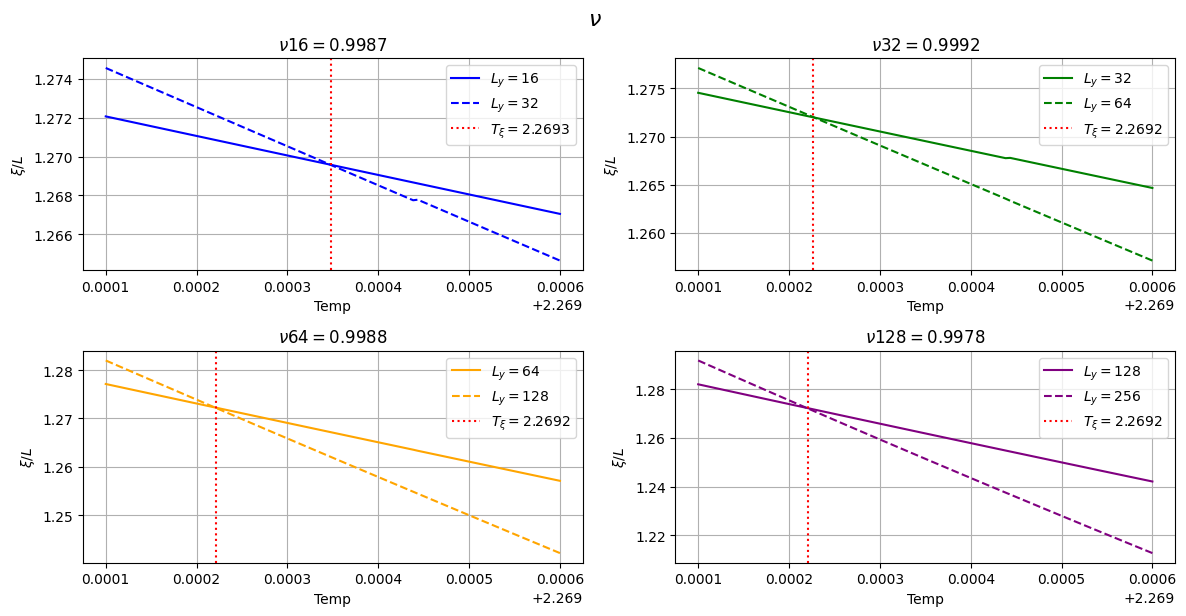

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.misc import derivative

# 初始化子圖
fig, axs = plt.subplots(2, 2, figsize=(12, 6))  # 2x2 子圖
axs = axs.flatten()

# 定義顏色用於每組數據
colors = ['b', 'g', 'orange', 'purple']

for idx, i in enumerate(range(5, 9)):
    # 範例數據：假設 T 和 \xi/L_y
    T = Temp
    xi_Ly_32 = np.array(Corr_len[i])
    xi_Ly_64 = np.array(Corr_len[i + 1])

    # 1. 找交點溫度 T_xi*：
    interp_32 = interp1d(T, xi_Ly_32, kind='cubic')
    interp_64 = interp1d(T, xi_Ly_64, kind='cubic')
    crossing_temp = T[np.argmin(np.abs(xi_Ly_32 - xi_Ly_64))]

    # 2. 計算斜率 s_{xi/L_y} 在 T_xi* 附近
    slope_32 = derivative(interp_32, crossing_temp, dx=1e-5)
    slope_64 = derivative(interp_64, crossing_temp, dx=1e-5)

    # 3. 使用公式計算 1/\nu
    log_ratio = np.log(slope_64 / slope_32)
    log2 = np.log(2)
    nu = 1 / (log_ratio / log2)

    print(f"交點溫度 T_xi*: {crossing_temp:.4f}")
    print(f"L_y={2**(i - 1)} 的斜率: {slope_32:.4f}")
    print(f"L_y={2**i} 的斜率: {slope_64:.4f}")
    print(f"估算的臨界指數 \nu: {nu:.4f}")

    # 繪製每組數據到子圖
    axs[idx].plot(T, xi_Ly_32, label=f"$L_y={2**(i - 1)}$", color=colors[idx])
    axs[idx].plot(T, xi_Ly_64, linestyle='--', label=f"$L_y={2**i}$", color=colors[idx])
    axs[idx].axvline(crossing_temp, color='r', linestyle=':', label=f"$T_\\xi = {crossing_temp:.4f}$")

    # 添加標題和圖例
    axs[idx].set_title(f"$\\nu {2**(i - 1)} = {nu:.4f}$")
    axs[idx].set_xlabel("Temp")
    axs[idx].set_ylabel(r"$\xi / L$")
    axs[idx].legend()
    axs[idx].grid()

# 調整子圖布局
plt.tight_layout()
plt.suptitle(r"$\nu$", fontsize=16, y=1.02)
plt.show()


In [38]:
import pickle

# File names
file_names = [f"Secant_results_{i}.pkl" for i in range(1, 4)]

# Load and concatenate data
combined_data = []
for file_name in file_names:
    with open(file_name, "rb") as f:
        data = pickle.load(f)
        combined_data.append(data)

# Combine all dictionaries
merged_data = {key: [] for key in combined_data[0]}  # Initialize with keys from the first file
for data in combined_data:
    for key, value in data.items():
        merged_data[key].extend(value if isinstance(value, list) else [value])

merged_data['T_stars'] = np.concatenate(merged_data['T_stars'], axis=0)

merged_data


{'MaxL': [11, 11, 11],
 'Tc': [np.float64(2.269185314213022),
  np.float64(2.269185314213022),
  np.float64(2.269185314213022)],
 'dcuts': [4, 8, 12, 16, 24, 32, 36, 38],
 'T_stars': array([[2.36      , 2.38508589, 2.28688211, 2.26141977, 2.2507999 ,
         2.24584482, 2.24360829, 2.24265865, 2.40319581, 2.38499515],
        [2.36      , 2.34624284, 2.28356774, 2.27358407, 2.27198644,
         2.27092694, 2.27009626, 2.26953509, 2.26920663, 2.26903597],
        [2.36      , 2.34401559, 2.28197138, 2.27130544, 2.27028681,
         2.26995037, 2.2697072 , 2.26953329, 2.2694157 , 2.26934118],
        [2.36      , 2.34401828, 2.28148523, 2.27077862, 2.269807  ,
         2.26967435, 2.26958397, 2.26950204, 2.26943849, 2.26941209],
        [2.36      , 2.34401828, 2.28140334, 2.27051342, 2.26947043,
         2.26935899, 2.26924874, 2.26924275, 2.26920408, 2.26918221],
        [2.36      , 2.34401828, 2.28139417, 2.27047498, 2.26937236,
         2.26926225, 2.26925302, 2.26924454, 2.2692325

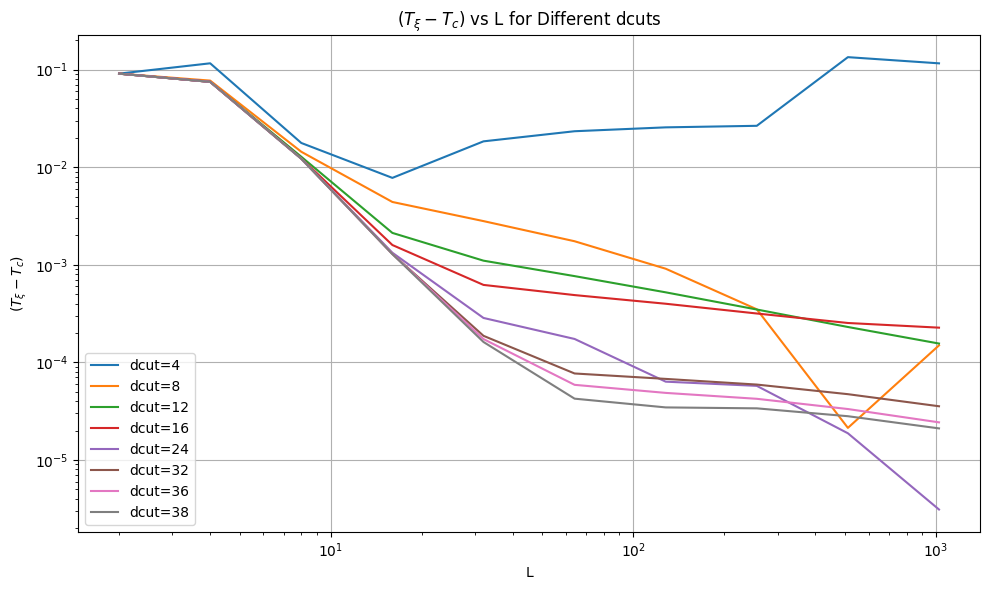

In [49]:
# Calculate T_stars - Tc and take the log
Tc = merged_data['Tc'][0]  # Assuming Tc is constant
T_star_diff = np.abs(T_stars - Tc)  # Absolute difference
log_T_star_diff = np.log(T_star_diff)

# Plot log(T_stars - Tc) vs L for different dcuts
plt.figure(figsize=(10, 6))
for i, dcut in enumerate(dcuts):
    plt.plot(2**L_values, T_star_diff[i], label=f'dcut={dcut}')

# Customize plot
plt.title(r'($T_\xi - T_c$) vs L for Different dcuts')
plt.xlabel('L')
plt.ylabel(r'($T_\xi - T_c$)')
plt.loglog()
plt.legend()
plt.grid()
plt.tight_layout()

# Show plot
plt.show()
